In [1]:
import os
import gc
import glob
import json
#import h5py
import numpy as np
import pickle
import pandas as pd
#from IPython.display import Audio, display
from collections import Counter, defaultdict
from pynwb import NWBHDF5IO
from datetime import datetime
import scipy.signal
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, silhouette_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cosine, euclidean
from scipy.signal import decimate

In [2]:
from extract_features import extractHG, stackFeatures, downsampleLabels
from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from phonetic_dictionary import PhoneticDictionary
#from feature_vizualizer import PhonemeFeatureVisualizer
from markov_phoneme_model import MarkovPhonemeModel
from extract_features import extractHG, downsampleLabels, extractMelSpecs
from pipeline import UnifiedPhonemePipeline
from config import BIDS_PATH, OUTPUT_PATH, RESULTS_PATH, DUTCH_30_PATH, DUTCH_10_PATH, get_dataset_paths

Running from clean repo, using data from: C:\mozg\code\SingleWordProductionDutch


In [3]:
from dutch_30_pipeline import Dutch30Pipeline
from dutch_30_feature_extractor import Dutch30FeatureExtractor
from phoneme_detection_diagnostic import Dutch30PhonemeDetectionDiagnostic 
from dataset_config import Dutch30Config

from transformers import Wav2Vec2Model, Wav2Vec2Processor
import torch

In [4]:
plt.ion()

In [5]:
dutch30_dir = DUTCH_30_PATH

# List all .npy files for one patient
patient_files = glob.glob(os.path.join(dutch30_dir, 'P01*.npy'))

In [6]:
# Check we're using the right paths
print(f"BIDS path: {BIDS_PATH}")
print(f"Output path: {OUTPUT_PATH}")
print(f"Results path: {RESULTS_PATH}")
# Define paths
path_bids = BIDS_PATH # './SingleWordProductionDutch-iBIDS'  # Path to the BIDS dataset
path_output = OUTPUT_PATH #'./features'  # Path to save extracted features
path_results = RESULTS_PATH #'./results'  # Path to save results
paths_30 = get_dataset_paths('dutch30')

BIDS path: C:\mozg\code\SingleWordProductionDutch\Dutch_10patients
Output path: C:\mozg\code\SingleWordProductionDutch\features
Results path: C:\mozg\code\SingleWordProductionDutch\results


In [7]:
# Check we're using the right paths
print(f"BIDS path: {BIDS_PATH}")
print(f"Output path: {OUTPUT_PATH}")
print(f"Results path: {RESULTS_PATH}")
# Define paths
path_bids = BIDS_PATH # './SingleWordProductionDutch-iBIDS'  # Path to the BIDS dataset
path_output = OUTPUT_PATH #'./features'  # Path to save extracted features
path_results = RESULTS_PATH #'./results'  # Path to save results
paths_30 = get_dataset_paths('dutch30')
#visualizer = PhonemeFeatureVisualizer(output_dir='./phoneme_visualizations')

BIDS path: C:\mozg\code\SingleWordProductionDutch\Dutch_10patients
Output path: C:\mozg\code\SingleWordProductionDutch\features
Results path: C:\mozg\code\SingleWordProductionDutch\results


In [8]:
# Create config
# config = Dutch30Config()

# # Pass config to both extractor and pipeline
# extractor = Dutch30FeatureExtractor(config=config)

# pipeline = Dutch30Pipeline(
#     dutch30_extractor=extractor,
#     config=config, 
#     debug_mode=True,
#     pca_components=100,
#     feature_extraction_method='high_gamma', 
    
# )

# # Debug a specific patient
# pipeline.debug_sentence_parsing('sub-p21', max_samples=3)
# print([attr for attr in dir(pipeline_debug) if 'detect' in attr.lower()])

In [9]:
# Load pre-trained wav2vec model
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base", use_safetensors=True)
config = Dutch30Config()
extractor = Dutch30FeatureExtractor()

C:\ProgramData\anaconda3\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz


In [10]:
# #check where method is used
# import os

# search_term = "standardize_channels"
# project_path = r"D:\Documents\UM DACS\bachelor\UM DACS\bachelor\mozg\code\SingleWordProductionDutch_step2"

# for filename in os.listdir(project_path):
#     if filename.endswith('.py'):
#         filepath = os.path.join(project_path, filename)
#         with open(filepath, 'r', encoding='utf-8') as f:
#             lines = f.readlines()
#             for line_num, line in enumerate(lines, 1):
#                 if search_term in line and 'def ' not in line and not line.strip().startswith('#'):
#                     print(f"{filename}:{line_num}: {line.strip()}")

In [11]:
# pipeline.step1_load_dutch30_data(num_patients = 10)
# #pipeline.step2_3_use_existing_split()
# pipeline.step2_split_by_instances()

# pid = 'P01'
# word_segments = pipeline.split_result['word_segments_dict'][pid]
# word = list(word_segments['words'].keys())[0]
# instance = word_segments['words'][word]['instances'][0]

# print(f"Audio available: {'audio_segment' in instance}")
# print(f"Audio shape: {instance['audio_segment'].shape if 'audio_segment' in instance else 'N/A'}")

In [12]:
# diag = Dutch30PhonemeDetectionDiagnostic(pipeline)
# diag.visualize_word_analysis('P01', word_name = 'vogelkooitje', save_path='p21_word5.png')

In [13]:
# #diag.visualize_multifeature_analysis('P01', word_index=50)
# diag.visualize_rms_boundaries('P01',  word_name = 'vogelkooitje')

In [14]:
# # Quick check first 10 words
# diag.batch_diagnostic('sub-p21', num_samples=5)

In [15]:
# def load_or_create_pipeline(
#     name,
#     config,
#     extractor,
#     feature_extraction_method,
#     patient_range=(1, 30),
#     sample_fraction=1,
#     use_wav2vec=True,
#     use_rms_boundaries=False,
#     use_multifeature=False,
#     subtract_baseline=True,
#     debug_mode=False,
#     pca_components=None
# ):
#     """
#     Load pipeline from checkpoint if available, otherwise create and run steps.
    
#     Args:
#         name: Pipeline name for logging (e.g., 'high_gamma', 'band_powers')
#         config: Dutch30Config instance
#         extractor: Dutch30FeatureExtractor instance
#         feature_extraction_method: Feature method string
#         patient_range: Tuple (start, end) for patient selection, e.g., (1, 30) or (21, 30)
#         sample_fraction: Fraction used when saving checkpoint
#         use_wav2vec: Whether to use wav2vec for boundary detection
#         use_rms_boundaries: Whether to use RMS boundaries
#         use_multifeature: Whether to use multifeature detection
#         subtract_baseline: Whether to subtract baseline
#         debug_mode: Enable debug output
#         pca_components: Number of PCA components (None for no PCA)
        
#     Returns:
#         Loaded or newly created pipeline
#     """
#     print(f"\n{'='*60}")
#     print(f"LOADING PIPELINE: {name}")
#     print(f"{'='*60}")
#     print(f"Patients: P{patient_range[0]:02d} - P{patient_range[1]:02d}")
#     print(f"Feature method: {feature_extraction_method}")
    
#     # Create pipeline instance
#     pipeline = Dutch30Pipeline(
#         dutch30_extractor=extractor,
#         config=config,
#         debug_mode=debug_mode,
#         pca_components=pca_components,
#         feature_extraction_method=feature_extraction_method,
#         use_rms_boundaries=use_rms_boundaries,
#         use_multifeature=use_multifeature,
#         use_wav2vec=use_wav2vec,
#         subtract_baseline=subtract_baseline
#     )
    
#     # Try to load checkpoint
#     print(f"Attempting to load checkpoint (sample_fraction={sample_fraction})...")
    
#     if pipeline.try_load_checkpoint(sample_fraction=sample_fraction):
#         print(f"Checkpoint loaded successfully!")
#         print(f"  Train samples: {len(pipeline.train.get('features', []))}")
#         print(f"  Test samples: {len(pipeline.test.get('features', []))}")
#         return pipeline
    
#     # No checkpoint found - run all steps
#     print(f"No checkpoint found. Running pipeline steps...")
    
#     print(f"\n  Step 1: Loading data (patients {patient_range})...")
#     pipeline.step1_load_dutch30_data(patient_range=patient_range)
    
#     print(f"  Step 2: Segmenting words...")
#     pipeline.step2_segment_words()
    
#     print(f"  Step 3: Creating split...")
#     pipeline.step3_create_split()
    
#     print(f"  Step 4: Creating detector...")
#     pipeline.step4_create_detector()
    
#     print(f"  Step 5: Accumulating data...")
#     pipeline.step5_accumulate_data_dutch30()
    
#     print(f"  Step 6: Saving checkpoint...")
#     pipeline.checkpoint_after_step6(sample_fraction=sample_fraction)
    
#     print(f"\nPipeline '{name}' created successfully!")
#     print(f"  Train samples: {len(pipeline.train.get('features', []))}")
#     print(f"  Test samples: {len(pipeline.test.get('features', []))}")
    
#     return pipeline


# # Usage
# config = Dutch30Config()
# extractor = Dutch30FeatureExtractor(config=config)

# common_params = {
#     'config': config,
#     'extractor': extractor,
#     'sample_fraction': 1,
#     'use_wav2vec': True,
#     'use_rms_boundaries': False,
#     'use_multifeature': False,
#     'subtract_baseline': True,
#     'debug_mode': False,
#     'pca_components': None
# }

# # All patients (1-30)
# high_gamma_pipeline = load_or_create_pipeline(
#     name='high_gamma',
#     feature_extraction_method='high_gamma',
#     patient_range=(1, 30),
#     **common_params
# )

# band_powers_pipeline = load_or_create_pipeline(
#     name='band_powers',
#     feature_extraction_method='band_powers',
#     patient_range=(1, 30),
#     **common_params
# )

# hjorth_pipeline = load_or_create_pipeline(
#     name='band_power_hjorth',
#     feature_extraction_method='band_power_hjorth',
#     patient_range=(1, 30),
#     **common_params
# )

In [16]:
config = Dutch30Config()
extractor = Dutch30FeatureExtractor(config=config)

band_powers_pipeline = Dutch30Pipeline(
    dutch30_extractor=extractor,
    config=config, 
    debug_mode=False,
    pca_components= None, #100,
    feature_extraction_method = 'band_powers',# 'high_gamma', #'band_powers', #'band_power_hjorth', # 'hjorth', #'band_powers',# 'hjorth', #'high_gamma', # 'band_powers', # 'band_power_hjorth'
    use_rms_boundaries=False,   
    use_multifeature=False,
    use_wav2vec=True,
    subtract_baseline=False,
    #baseline_method = 'band_powers' #'feature_matched', 'band_powers', 'raw'
)

high_gamma_pipeline = Dutch30Pipeline(
    dutch30_extractor=extractor,
    config=config, 
    debug_mode=False,
    pca_components= None, #100,
    feature_extraction_method = 'high_gamma',# 'high_gamma', #'band_powers', #'band_power_hjorth', # 'hjorth', #'band_powers',# 'hjorth', #'high_gamma', # 'band_powers', # 'band_power_hjorth'
    use_rms_boundaries=False,   
    use_multifeature=False,
    use_wav2vec=True,
    subtract_baseline=False,
    #baseline_method = 'band_powers' #'feature_matched', 'band_powers', 'raw'
)

# hjorth_pipeline = Dutch30Pipeline(
#     dutch30_extractor=extractor,
#     config=config, 
#     debug_mode=False,
#     pca_components= None, #100,
#     feature_extraction_method = 'band_power_hjorth',# 'high_gamma', #'band_powers', #'band_power_hjorth', # 'hjorth', #'band_powers',# 'hjorth', #'high_gamma', # 'band_powers', # 'band_power_hjorth'
#     use_rms_boundaries=False,   
#     use_multifeature=False,
#     use_wav2vec=True,
#     subtract_baseline=True,
#     #baseline_method = 'band_powers' #'feature_matched', 'band_powers', 'raw'
# )

Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz
CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 729 sentence-level entries
PhoneticDictionary: Mismatch (after merge): ''s morgens': 2 words vs 1 phoneme groups
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 1 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: band_powers, PCA=None, groups=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 729 sentence-level entries
PhoneticDictionary: Mismatch (after merge): ''s morgens': 2 words vs 1 phoneme groups
PhoneticDictionary: 

In [36]:
# step_0
# pipeline.analyze_dutch30_channels()
#pipeline.step1_load_dutch30_data(num_patients = 20)
#best_patients = ['P03', 'P11', 'P16', 'P17', 'P21']
#pipeline.step1_load_dutch30_data(patient_ids=best_patients)

#band_powers_pipeline.step1_load_dutch30_data(patient_range=(1,30))
high_gamma_pipeline.step1_load_dutch30_data(patient_range=(20,30))
# band_powers_pipeline.split_result = None
high_gamma_pipeline.split_result = None
# band_powers_pipeline.step2_split_by_instances();
high_gamma_pipeline.step2_split_by_instances();
#hjorth_pipeline.step1_load_dutch30_data(patient_range=(1,30))
#hjorth_pipeline.split_result = None
#hjorth_pipeline.step2_split_by_instances();

high_gamma_pipeline.step3_analyze_channel_quality()
# band_powers_pipeline.step3_analyze_channel_quality()
#high_gamma_pipeline.step3_analyze_channel_quality(visualize=True)

UnifiedPhonemePipeline: Step 1: Loading Dutch30...
UnifiedPhonemePipeline:   Using patients P20 to P30: ['P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
UnifiedPhonemePipeline: P20: 60 train, 40 test, baseline: (130,)
UnifiedPhonemePipeline: P21: 313 train, 151 test, baseline: (110,)
UnifiedPhonemePipeline: P22: 372 train, 196 test, baseline: (114,)
UnifiedPhonemePipeline: P23: 500 train, 238 test, baseline: (130,)
UnifiedPhonemePipeline: P24: 356 train, 182 test, baseline: (130,)
UnifiedPhonemePipeline: P25: 321 train, 161 test, baseline: (118,)
UnifiedPhonemePipeline: P26: 288 train, 162 test, baseline: (90,)
UnifiedPhonemePipeline: P27: 384 train, 198 test, baseline: (130,)
UnifiedPhonemePipeline: P28: 341 train, 182 test, baseline: (90,)
UnifiedPhonemePipeline: P29: 400 train, 210 test, baseline: (84,)
UnifiedPhonemePipeline: P30: 421 train, 233 test, baseline: (130,)

=== step2_split_by_instances complete ===
UnifiedPhonemePipeline: Step 3: Analyzing c

{'P20': {'exclude_indices': [59, 94],
  'keep_indices': [0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
   88,
   89,
   90,
   91,
   92,
   93,
   95,
   96,
   97,
   98,
   99,
   100,
   101,
   102,
   103,
   104,
   105,
   106,
   107,
   108,
   109,
   110,
   111,
   112,
   113,
   114,
   115,
   116,
   117,
   118,
   119,
   120,
   121,
   122,
   123,
   124,
   125,
   126,
   127,
   128,
   129],
  'n_original': 130,
  'n_kep

In [37]:
# band_powers_pipeline.step4_custom_detector()
high_gamma_pipeline.step4_custom_detector()
# hjorth_pipeline.step4_custom_detector()

UnifiedPhonemePipeline: Step 4: Initializing detector...
AcousticChangeDetector: Initialized with DEBUG_MODE=False
AcousticChangeDetector: Using feature extraction method: high_gamma
AcousticChangeDetector: Initializing wav2vec model for boundary detection...


C:\ProgramData\anaconda3\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


AcousticChangeDetector: Wav2vec model initialized successfully


In [38]:
# band_powers_pipeline.step5_accumulate_data_dutch30();
high_gamma_pipeline.step5_accumulate_data_dutch30();
# hjorth_pipeline.step5_accumulate_data_dutch30();

UnifiedPhonemePipeline: 
Step 5 starting:
UnifiedPhonemePipeline:   Train patients: ['P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
UnifiedPhonemePipeline:   Available samples: train=3756, test=1953
AcousticChangeDetector: Processing 3756 instances in 30 batches (no replacement)
AcousticChangeDetector: Processing batch 1/30
          Building batch from 128 instances...
          Batch built: 128 words
          Processing batch (phoneme detection)...
AcousticChangeDetector:   Need 2 peaks but only found 1 for word 'met' (Patient P21)
AcousticChangeDetector:   Need 2 peaks but only found 1 for word 'mijn' (Patient P21)
AcousticChangeDetector:   Need 7 peaks but only found 5 for word 'straatnaam' (Patient P21)
AcousticChangeDetector:   Need 10 peaks but only found 4 for word 'Bleumerstraat?' (Patient P21)
AcousticChangeDetector:   Need 2 peaks but only found 1 for word 'heb' (Patient P21)
          Batch processed
          Preparing training data...
      

In [39]:
# band_powers_pipeline.dutch30_step6_resolve_unknowns();
high_gamma_pipeline.dutch30_step6_resolve_unknowns();
# hjorth_pipeline.dutch30_step6_resolve_unknowns();

UnifiedPhonemePipeline: Train data keys: dict_keys(['features', 'phoneme_labels', 'phoneme_words', 'phoneme_positions', 'phoneme_participant_ids', 'phoneme_durations_samples', 'spectrograms', 'metadata'])
UnifiedPhonemePipeline: Unknown count: 5354
PhonemeValidator: Initialized with DEBUG_MODE=False
UnifiedPhonemePipeline: Step 6: Validator initialized
UnifiedPhonemePipeline: Resolving 5354 unknown phonemes in training...
UnifiedPhonemePipeline: Test unknowns: 2524
UnifiedPhonemePipeline: WARNING: Still 62 unknown in train, 19 in test
UnifiedPhonemePipeline: Step 6 complete: 14149 train, 6976 test
UnifiedPhonemePipeline:   Unknown remaining: 62 train, 19 test


In [40]:
# band_powers_pipeline.checkpoint_after_step6()
high_gamma_pipeline.checkpoint_after_step6()
# band_powers_pipeline.checkpoint_after_step6(sample_fraction=1)
# high_gamma_pipeline.checkpoint_after_step6(sample_fraction=1)
# hjorth_pipeline.checkpoint_after_step6(sample_fraction=1)

UnifiedPhonemePipeline: Saving checkpoint: pipeline_high_gamma_pcaNone_after_step6_20251224_071658.pkl
UnifiedPhonemePipeline: Checkpoint saved: pipeline_high_gamma_pcaNone_after_step6_20251224_071658.pkl


'C:\\mozg\\code\\SingleWordProductionDutch\\results\\dutch30\\pipeline_high_gamma_pcaNone_after_step6_20251224_071658.pkl'

In [22]:
# pipeline.try_load_checkpoint(sample_fraction=0.0001)

In [41]:
# band_powers_pipeline.step7_filter_unknowns(unknown_keep_ratio=0.05);
high_gamma_pipeline.step7_filter_unknowns(unknown_keep_ratio=0.05);
# hjorth_pipeline.step7_filter_unknowns(unknown_keep_ratio=0.05);

UnifiedPhonemePipeline: Filtered training: 14094 samples (from 14149)


In [42]:
# Check if pipeline has any partial results
if hasattr(high_gamma_pipeline, 'detector'):
    print("Detector exists")
    
# Check if there's any train data accumulating
if hasattr(high_gamma_pipeline, 'train') and high_gamma_pipeline.train is not None:
    print(f"Train data so far: {len(high_gamma_pipeline.train.get('phoneme_labels', []))} phonemes")

Detector exists
Train data so far: 14149 phonemes


In [25]:
def train_simple_classifiers(pipeline, save_path=None, fast_mode=True, show_best_confusion=True):
    """
    Test multiple simple classifiers per patient.
    
    Args:
        pipeline: Pipeline with train/test data
        save_path: Optional path to save heatmap
        fast_mode: If True, skip slow classifiers (SVM, MLP, deep trees)
        show_best_confusion: If True, show confusion matrix for best patient/classifier
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import os
    from collections import Counter
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
    from sklearn.naive_bayes import GaussianNB
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.svm import SVC
    from sklearn.neural_network import MLPClassifier
    from sklearn.preprocessing import StandardScaler, LabelEncoder
    from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
    
    # Get pipeline parameters for titles
    pca_components = getattr(pipeline, 'pca_components', None)
    feature_method = getattr(pipeline, 'feature_extraction_method', 'unknown')
    subtract_baseline = getattr(pipeline, 'subtract_baseline_flag', 'unknown')
    
    title_suffix = f"PCA={pca_components}, Features={feature_method}, Baseline={subtract_baseline}"
    
    if fast_mode:
        classifiers = {
            'RandomForest_Simple': RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1),
            'RandomForest_Medium': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
            'ExtraTrees': ExtraTreesClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
            'GaussianNB': GaussianNB(),
            'KNN_30': KNeighborsClassifier(n_neighbors=30, n_jobs=-1),
            'LogisticRegression': LogisticRegression(max_iter=500, random_state=42, n_jobs=-1),
            'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42),
        }
        print("Running in FAST MODE (skipping SVM, MLP, deep trees)")
    else:
        classifiers = {
            'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
            'RandomForest_Simple': RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1),
            'RandomForest_Deep': RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1),
            'RandomForest_Large': RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=2, random_state=42, n_jobs=-1),
            'ExtraTrees': ExtraTreesClassifier(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1),
            'GradientBoosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
            'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
            'SVM_RBF': SVC(kernel='rbf', C=1.0, random_state=42),
            'SVM_Linear': SVC(kernel='linear', C=1.0, random_state=42),
            'MLP_Small': MLPClassifier(hidden_layer_sizes=(64,), max_iter=500, random_state=42),
            'MLP_Medium': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42),
            'GaussianNB': GaussianNB(),
            'KNN_30': KNeighborsClassifier(n_neighbors=30, n_jobs=-1),
            'KNN_35': KNeighborsClassifier(n_neighbors=35, n_jobs=-1),
            'KNN_50': KNeighborsClassifier(n_neighbors=50, n_jobs=-1),
        }
    
    # Optional imports
    try:
        from xgboost import XGBClassifier
        classifiers['XGBoost'] = XGBClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.1,
            random_state=42, use_label_encoder=False,
            eval_metric='mlogloss', verbosity=0, n_jobs=-1
        )
    except ImportError:
        pass
    
    try:
        from lightgbm import LGBMClassifier
        classifiers['LightGBM'] = LGBMClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.1,
            random_state=42, verbose=-1, n_jobs=-1
        )
    except ImportError:
        pass
    
    results = {}
    detailed_results = {}  # Store predictions for best case
    patients = sorted(set(pipeline.train['phoneme_participant_ids']))
    
    for idx, pid in enumerate(patients):
        train_mask = [p == pid for p in pipeline.train['phoneme_participant_ids']]
        test_mask = [p == pid for p in pipeline.test['phoneme_participant_ids']]
        
        train_feat = [pipeline.train['features'][i] for i, m in enumerate(train_mask) if m]
        train_labels = [pipeline.train['phoneme_labels'][i] for i, m in enumerate(train_mask) if m]
        test_feat = [pipeline.test['features'][i] for i, m in enumerate(test_mask) if m]
        test_labels = [pipeline.test['phoneme_labels'][i] for i, m in enumerate(test_mask) if m]
        
        if len(train_feat) < 10 or len(test_feat) < 5:
            continue
        
        # Flatten features
        X_train = np.array([np.mean(f, axis=0) if f.ndim > 1 else f for f in train_feat])
        X_test = np.array([np.mean(f, axis=0) if f.ndim > 1 else f for f in test_feat])
        
        # Check for NaN/Inf
        valid_train = ~(np.isnan(X_train).any(axis=1) | np.isinf(X_train).any(axis=1))
        valid_test = ~(np.isnan(X_test).any(axis=1) | np.isinf(X_test).any(axis=1))
        
        X_train = X_train[valid_train]
        y_train = [train_labels[i] for i in range(len(train_labels)) if valid_train[i]]
        X_test = X_test[valid_test]
        y_test = [test_labels[i] for i in range(len(test_labels)) if valid_test[i]]
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Filter test labels to only those seen in training
        train_labels_set = set(y_train)
        valid_test_idx = [i for i, label in enumerate(y_test) if label in train_labels_set]
        
        if len(valid_test_idx) < len(y_test):
            X_test_scaled = X_test_scaled[valid_test_idx]
            y_test = [y_test[i] for i in valid_test_idx]
        
        if len(y_test) < 5:
            continue    
        
        label_encoder = LabelEncoder()
        y_train_encoded = label_encoder.fit_transform(y_train)
        y_test_encoded = label_encoder.transform(y_test)

        results[pid] = {}
        detailed_results[pid] = {}
        
        for name, clf in classifiers.items():
            try:
                if 'XGBoost' in name or 'LightGBM' in name:
                    clf.fit(np.asarray(X_train_scaled, dtype=np.float32), y_train_encoded)
                    preds_encoded = clf.predict(np.asarray(X_test_scaled, dtype=np.float32))
                    preds = list(label_encoder.inverse_transform(preds_encoded))
                else:
                    clf.fit(X_train_scaled, y_train)
                    preds = list(clf.predict(X_test_scaled))
                
                acc = accuracy_score(y_test, preds)
                results[pid][name] = acc
                
                # Store detailed results for later
                detailed_results[pid][name] = {
                    'y_true': y_test,
                    'y_pred': preds,
                    'accuracy': acc
                }
                
            except Exception as e:
                results[pid][name] = 0.0
    
    # Create results DataFrame
    all_patients = sorted(results.keys())
    all_classifiers = list(classifiers.keys())
    
    data = []
    for clf_name in all_classifiers:
        row = [results.get(pid, {}).get(clf_name, np.nan) for pid in all_patients]
        data.append(row)
    
    df = pd.DataFrame(data, index=all_classifiers, columns=all_patients)
    df['Mean'] = df.mean(axis=1)
    df_sorted = df.sort_values('Mean', ascending=False)
    
    print("\n" + "="*90)
    print(f"RANKED BY MEAN ACCURACY - {title_suffix}")
    print("="*90)
    print(df_sorted.to_string())
    
    # Find best patient and classifier
    best_acc = 0
    best_pid = None
    best_clf = None
    
    for pid in results:
        for clf_name, acc in results[pid].items():
            if acc > best_acc:
                best_acc = acc
                best_pid = pid
                best_clf = clf_name
    
    print("\n" + "="*90)
    print(f"BEST RESULT: {best_pid} + {best_clf} = {best_acc:.3f}")
    print("="*90)
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(12, max(6, len(all_classifiers) * 0.4)))
    df_heatmap = df.drop(columns=['Mean'])
    
    im = ax.imshow(df_heatmap.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=0.3)
    
    ax.set_xticks(range(len(all_patients)))
    ax.set_xticklabels(all_patients, fontsize=10)
    ax.set_yticks(range(len(all_classifiers)))
    ax.set_yticklabels(all_classifiers, fontsize=9)
    
    for i in range(len(all_classifiers)):
        for j in range(len(all_patients)):
            val = df_heatmap.values[i, j]
            if not np.isnan(val):
                color = 'white' if val > 0.15 else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Accuracy', fontsize=10)
    
    ax.set_xlabel('Patient', fontsize=11)
    ax.set_ylabel('Classifier', fontsize=11)
    ax.set_title(f'Classifier Accuracy by Patient\n{title_suffix}', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        os.makedirs(save_path, exist_ok=True)
        filename = f"classifiers_heatmap_pca{pca_components}_{feature_method}_baseline{subtract_baseline}.png"
        filepath = os.path.join(save_path, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"\nHeatmap saved to: {filepath}")
    
    plt.show()
    
    # Show confusion matrix for best case
    if show_best_confusion and best_pid and best_clf:
        best_data = detailed_results[best_pid][best_clf]
        y_true = best_data['y_true']
        y_pred = best_data['y_pred']
        
        # Get unique labels sorted
        unique_labels = sorted(set(y_true + y_pred))
        
        # Create confusion matrix
        cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
        
        # Plot
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f'Best Result: {best_pid} + {best_clf} (Accuracy: {best_acc:.3f})', 
                     fontsize=14, fontweight='bold')
        
        # Confusion matrix heatmap
        im = axes[0].imshow(cm, cmap='Blues')
        axes[0].set_xticks(range(len(unique_labels)))
        axes[0].set_yticks(range(len(unique_labels)))
        axes[0].set_xticklabels(unique_labels, rotation=90, fontsize=8)
        axes[0].set_yticklabels(unique_labels, fontsize=8)
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('True')
        axes[0].set_title('Confusion Matrix')
        plt.colorbar(im, ax=axes[0])
        
        # Per-phoneme accuracy
        phoneme_acc = {}
        phoneme_counts = Counter(y_true)
        
        for p in unique_labels:
            correct = sum(1 for t, pred in zip(y_true, y_pred) if t == p and pred == p)
            total = phoneme_counts.get(p, 0)
            phoneme_acc[p] = correct / total if total > 0 else 0
        
        # Sort by accuracy
        sorted_phonemes = sorted(phoneme_acc.keys(), key=lambda x: phoneme_acc[x], reverse=True)
        
        colors = ['green' if phoneme_acc[p] > best_acc else 'orange' if phoneme_acc[p] > 0 else 'red' 
                  for p in sorted_phonemes]
        
        axes[1].barh(range(len(sorted_phonemes)), [phoneme_acc[p] for p in sorted_phonemes], color=colors)
        axes[1].set_yticks(range(len(sorted_phonemes)))
        axes[1].set_yticklabels([f"{p} (n={phoneme_counts[p]})" for p in sorted_phonemes], fontsize=8)
        axes[1].set_xlabel('Accuracy')
        axes[1].set_title('Per-Phoneme Accuracy (sorted)')
        axes[1].axvline(best_acc, color='red', linestyle='--', alpha=0.5, label=f'Overall: {best_acc:.3f}')
        axes[1].legend()
        axes[1].set_xlim([0, 1])
        
        plt.tight_layout()
        
        if save_path:
            filename = f"best_confusion_{best_pid}_{best_clf}.png"
            filepath = os.path.join(save_path, filename)
            plt.savefig(filepath, dpi=300, bbox_inches='tight')
            print(f"Confusion matrix saved to: {filepath}")
        
        plt.show()
        
        # Print classification report
        print("\n" + "="*90)
        print(f"CLASSIFICATION REPORT - {best_pid} + {best_clf}")
        print("="*90)
        print(classification_report(y_true, y_pred, zero_division=0))
        
        # Print top confusions
        print("\n" + "="*90)
        print("TOP CONFUSIONS (True -> Predicted: Count)")
        print("="*90)
        
        confusion_pairs = []
        for i, true_label in enumerate(unique_labels):
            for j, pred_label in enumerate(unique_labels):
                if true_label != pred_label and cm[i, j] > 0:
                    confusion_pairs.append((true_label, pred_label, cm[i, j]))
        
        confusion_pairs.sort(key=lambda x: x[2], reverse=True)
        
        for true_l, pred_l, count in confusion_pairs[:15]:
            print(f"  {true_l} -> {pred_l}: {count}")
    
    return results, df_sorted, detailed_results

In [43]:
def diagnose_duration_filtering(pipeline):
    train = pipeline.train
    features = train['features']
    labels = train['phoneme_labels']
    pids = train['phoneme_participant_ids']
    
    # Count samples per patient
    pid_counts = Counter(pids)
    
    print(f"\nSamples per patient:")
    print("-"*40)
    for pid in sorted(pid_counts.keys()):
        count = pid_counts[pid]
        status = "OK" if count >= 20 else "LOW" if count >= 5 else "CRITICAL"
        print(f"  {pid}: {count:5} samples  [{status}]")
    
    print(f"\nTotal patients: {len(pid_counts)}")
    print(f"Patients with < 20 samples: {sum(1 for c in pid_counts.values() if c < 20)}")
    print(f"Patients with < 5 samples: {sum(1 for c in pid_counts.values() if c < 5)}")
    print(f"Total samples: {len(features)}")
    
    # Check which patients are missing compared to expected
    expected_patients = [f'P{i:02d}' for i in range(1, 31) if i != 5]  # P05 missing
    missing = [p for p in expected_patients if p not in pid_counts]
    print(f"\nMissing patients: {missing}")
    
    return pid_counts
# Run diagnosis
pid_counts = diagnose_duration_filtering(high_gamma_pipeline)

DURATION FILTERING DIAGNOSIS

Samples per patient:
----------------------------------------
  P20:   185 samples  [OK]
  P21:  1169 samples  [OK]
  P22:  1406 samples  [OK]
  P23:  2087 samples  [OK]
  P24:  1353 samples  [OK]
  P25:  1193 samples  [OK]
  P26:  1100 samples  [OK]
  P27:  1349 samples  [OK]
  P28:  1255 samples  [OK]
  P29:  1536 samples  [OK]
  P30:  1516 samples  [OK]

Total patients: 11
Patients with < 20 samples: 0
Patients with < 5 samples: 0
Total samples: 14149

Missing patients: ['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P19']


Running in FAST MODE (skipping SVM, MLP, deep trees)

RANKED BY MEAN ACCURACY - PCA=None, Features=high_gamma, Baseline=False
                          P20       P21       P22       P23       P24       P25       P26       P27       P28       P29       P30      Mean
RandomForest_Medium  0.107438  0.132411  0.119777  0.131113  0.120357  0.120721  0.107452  0.130769  0.095462  0.119636  0.118537  0.118516
ExtraTrees           0.082645  0.130435  0.125348  0.135276  0.123328  0.122523  0.105719  0.136923  0.100156  0.115735  0.119798  0.117990
RandomForest_Simple  0.074380  0.126482  0.112813  0.132154  0.123328  0.120721  0.114385  0.138462  0.103286  0.119636  0.127364  0.117547
AdaBoost             0.107438  0.122530  0.114206  0.120708  0.126300  0.111712  0.095321  0.120000  0.097027  0.109233  0.118537  0.113001
KNN_30               0.049587  0.077075  0.083565  0.084287  0.080238  0.081081  0.076256  0.104615  0.065728  0.079324  0.079445  0.078291
LogisticRegression   0.057851  0.0

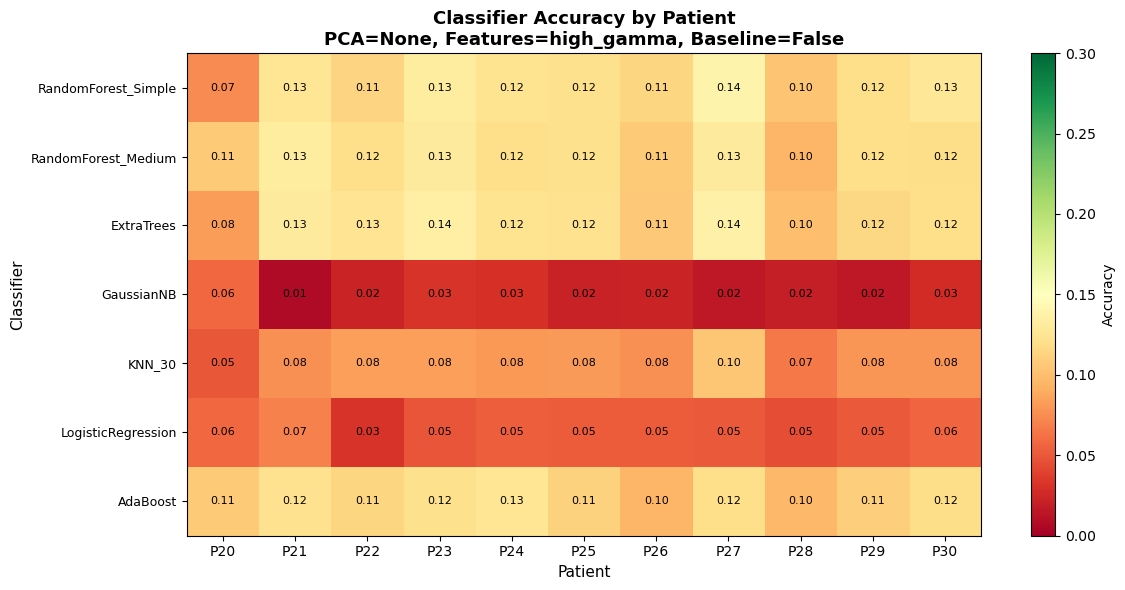

Confusion matrix saved to: results/best_confusion_P27_RandomForest_Simple.png


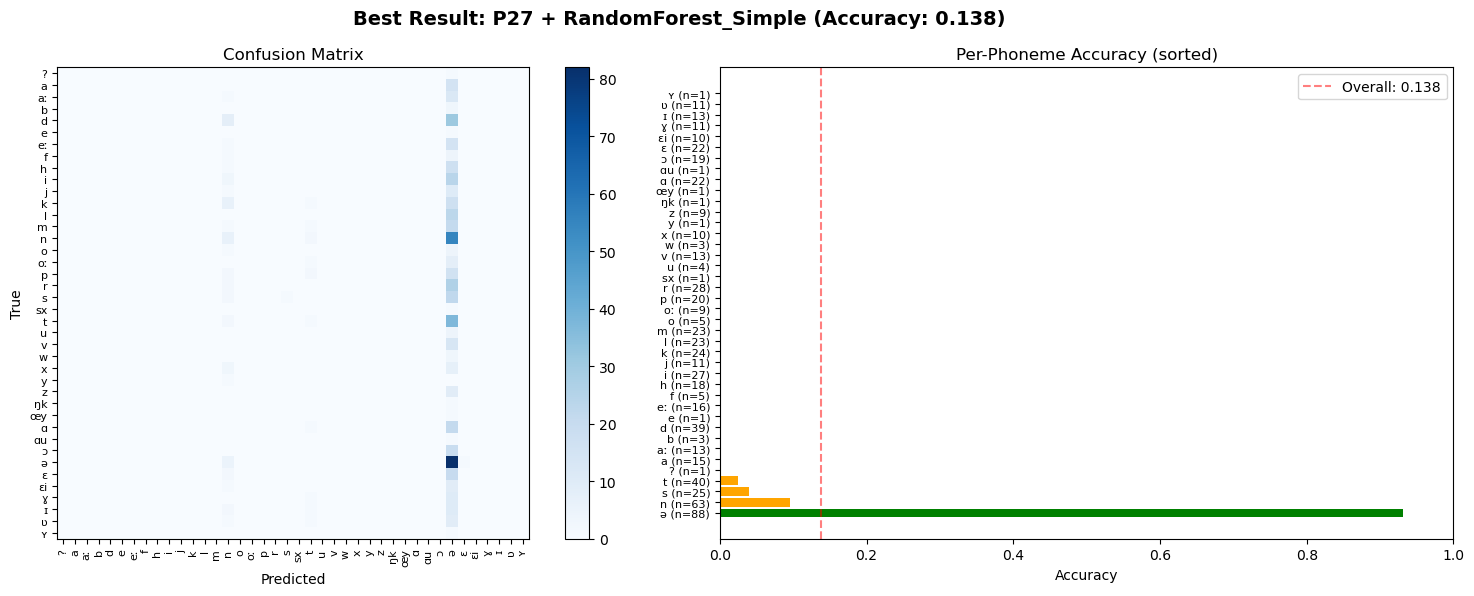


CLASSIFICATION REPORT - P27 + RandomForest_Simple
              precision    recall  f1-score   support

           ?       0.00      0.00      0.00         1
           a       0.00      0.00      0.00        15
          aː       0.00      0.00      0.00        13
           b       0.00      0.00      0.00         3
           d       0.00      0.00      0.00        39
           e       0.00      0.00      0.00         1
          eː       0.00      0.00      0.00        16
           f       0.00      0.00      0.00         5
           h       0.00      0.00      0.00        18
           i       0.00      0.00      0.00        27
           j       0.00      0.00      0.00        11
           k       0.00      0.00      0.00        24
           l       0.00      0.00      0.00        23
           m       0.00      0.00      0.00        23
           n       0.11      0.10      0.10        63
           o       0.00      0.00      0.00         5
          oː       0.00      0

In [44]:
results, df_sorted, detailed = train_simple_classifiers(
    high_gamma_pipeline, 
    save_path='results/', 
    fast_mode=True, 
    show_best_confusion=True
)

In [45]:
def test_classifiers_for_markov(pipeline, patient_id='P23'):
    """
    Test different classifiers as the emission model inside MarkovPhonemeModel.
    
    Compares:
    1. RandomForest (current)
    2. XGBoost
    3. LightGBM
    4. Linear SVM
    5. MLP
    6. Logistic Regression
    """
    import numpy as np
    from collections import Counter
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.svm import LinearSVC
    from sklearn.linear_model import LogisticRegression
    from sklearn.neural_network import MLPClassifier
    from sklearn.preprocessing import StandardScaler
    from sklearn.calibration import CalibratedClassifierCV
    
    # Optional: XGBoost and LightGBM
    try:
        from xgboost import XGBClassifier
        has_xgb = True
    except ImportError:
        has_xgb = False
        print("XGBoost not installed, skipping")
    
    try:
        from lightgbm import LGBMClassifier
        has_lgbm = True
    except ImportError:
        has_lgbm = False
        print("LightGBM not installed, skipping")
    
    print("="*70)
    print(f"CLASSIFIER COMPARISON FOR {patient_id}")
    print("="*70)
    
    # Get data for this patient
    train_mask = [p == patient_id for p in pipeline.train['phoneme_participant_ids']]
    test_mask = [p == patient_id for p in pipeline.test['phoneme_participant_ids']]
    
    train_feat = [pipeline.train['features'][i] for i, m in enumerate(train_mask) if m]
    train_labels = [pipeline.train['phoneme_labels'][i] for i, m in enumerate(train_mask) if m]
    test_feat = [pipeline.test['features'][i] for i, m in enumerate(test_mask) if m]
    test_labels = [pipeline.test['phoneme_labels'][i] for i, m in enumerate(test_mask) if m]
    
    print(f"Train: {len(train_feat)}, Test: {len(test_feat)}")
    
    # Prepare features
    X_train = np.array([f.mean(axis=0) if f.ndim > 1 else f for f in train_feat])
    X_test = np.array([f.mean(axis=0) if f.ndim > 1 else f for f in test_feat])
    
    # Filter unknown labels
    train_valid = [i for i, l in enumerate(train_labels) if l not in ('?', 'unknown')]
    test_valid = [i for i, l in enumerate(test_labels) if l not in ('?', 'unknown')]
    
    X_train = X_train[train_valid]
    y_train = np.array([train_labels[i] for i in train_valid])
    X_test = X_test[test_valid]
    y_test = np.array([test_labels[i] for i in test_valid])
    
    print(f"After filtering: Train={len(X_train)}, Test={len(X_test)}")
    print(f"Classes: {len(set(y_train))} train, {len(set(y_test))} test")
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Encode labels
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    le.fit(list(set(y_train) | set(y_test)))
    y_train_enc = le.transform(y_train)
    y_test_enc = le.transform(y_test)
    
    n_classes = len(le.classes_)
    baseline = 1 / n_classes
    
    print(f"Baseline (random): {baseline:.4f}")
    
    # Define classifiers
    classifiers = {
        'RF_balanced': RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ),
        'RF_balanced_sqrt': RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            min_samples_leaf=2,
            max_features='sqrt',
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ),
        'GradientBoosting': GradientBoostingClassifier(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42
        ),
        'LinearSVM': CalibratedClassifierCV(
            LinearSVC(
                class_weight='balanced',
                max_iter=5000,
                random_state=42
            ),
            cv=3
        ),
        'LogisticRegression': LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42,
            n_jobs=-1
        ),
        'MLP_small': MLPClassifier(
            hidden_layer_sizes=(128, 64),
            max_iter=500,
            early_stopping=True,
            random_state=42
        ),
        'MLP_large': MLPClassifier(
            hidden_layer_sizes=(256, 128, 64),
            max_iter=500,
            early_stopping=True,
            random_state=42
        ),
    }
    
    if has_xgb:
        classifiers['XGBoost'] = XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            n_jobs=-1,
            use_label_encoder=False,
            eval_metric='mlogloss'
        )
        classifiers['XGBoost_balanced'] = XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            scale_pos_weight=1,
            random_state=42,
            n_jobs=-1,
            use_label_encoder=False,
            eval_metric='mlogloss'
        )
    
    if has_lgbm:
        classifiers['LightGBM'] = LGBMClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )
    
    # Test each classifier
    results = {}
    
    for name, clf in classifiers.items():
        print(f"\nTesting {name}...")
        
        try:
            clf.fit(X_train_scaled, y_train_enc)
            
            y_pred_enc = clf.predict(X_test_scaled)
            y_pred = le.inverse_transform(y_pred_enc)
            
            # Accuracy
            accuracy = np.mean(y_pred == y_test)
            lift = accuracy / baseline
            
            # Prediction diversity
            pred_counts = Counter(y_pred)
            n_unique_preds = len(pred_counts)
            top_pred, top_count = pred_counts.most_common(1)[0]
            top_pct = 100 * top_count / len(y_pred)
            
            results[name] = {
                'accuracy': accuracy,
                'lift': lift,
                'n_unique_preds': n_unique_preds,
                'top_pred': top_pred,
                'top_pct': top_pct,
                'predictions': y_pred
            }
            
            print(f"  Accuracy: {accuracy:.4f} ({lift:.2f}x lift)")
            print(f"  Unique predictions: {n_unique_preds}/{n_classes}")
            print(f"  Top prediction: '{top_pred}' = {top_pct:.1f}%")
            
        except Exception as e:
            print(f"  FAILED: {e}")
            results[name] = {'error': str(e)}
    
    # Summary table
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    
    print(f"{'Classifier':<25} {'Accuracy':<12} {'Lift':<10} {'Unique':<10} {'Top %':<10}")
    print("-"*70)
    
    sorted_results = sorted(
        [(k, v) for k, v in results.items() if 'accuracy' in v],
        key=lambda x: x[1]['accuracy'],
        reverse=True
    )
    
    for name, r in sorted_results:
        print(f"{name:<25} {r['accuracy']:<12.4f} {r['lift']:<10.2f}x "
              f"{r['n_unique_preds']:<10} {r['top_pct']:<10.1f}%")
    
    # Best classifier
    best_name, best_result = sorted_results[0]
    print(f"\nBest: {best_name} with {best_result['accuracy']:.4f} accuracy ({best_result['lift']:.2f}x lift)")
    
    return results, scaler, le


# Run the comparison
classifier_results, scaler, label_encoder = test_classifiers_for_markov(
    high_gamma_pipeline, 
    patient_id='P23'
)

XGBoost not installed, skipping
LightGBM not installed, skipping
CLASSIFIER COMPARISON FOR P23
Train: 2087, Test: 961
After filtering: Train=2080, Test=956
Classes: 46 train, 40 test
Baseline (random): 0.0217

Testing RF_balanced...
  Accuracy: 0.0544 (2.50x lift)
  Unique predictions: 42/46
  Top prediction: 'ə' = 9.6%

Testing RF_balanced_sqrt...
  Accuracy: 0.0544 (2.50x lift)
  Unique predictions: 42/46
  Top prediction: 'ə' = 9.6%

Testing GradientBoosting...
  Accuracy: 0.0722 (3.32x lift)
  Unique predictions: 43/46
  Top prediction: 'ə' = 36.5%

Testing LinearSVM...
  FAILED: Requesting 3-fold cross-validation but provided less than 3 examples for at least one class.

Testing LogisticRegression...
  Accuracy: 0.0387 (1.78x lift)
  Unique predictions: 38/46
  Top prediction: 'z' = 5.2%

Testing MLP_small...
  Accuracy: 0.1088 (5.00x lift)
  Unique predictions: 10/46
  Top prediction: 'ə' = 52.8%

Testing MLP_large...
  Accuracy: 0.1255 (5.77x lift)
  Unique predictions: 6/46
  T

In [48]:
def compare_baseline_methods(pipeline, patient_ids=None):
    """
    Compare three baseline normalization approaches:
    1. Subtraction: activity - baseline (current)
    2. Percent change: 100 * (activity - baseline) / baseline
    3. Decibel: 10 * log10(activity / baseline)
    """
    import numpy as np
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from collections import Counter
    
    print("="*70)
    print("BASELINE NORMALIZATION COMPARISON")
    print("="*70)
    
    if patient_ids is None:
        patient_ids = ['P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
    
    train_data = pipeline.train
    baselines = pipeline.patient_baselines
    
    results = {method: [] for method in ['subtraction', 'percent_change', 'decibel', 'no_baseline']}
    
    for pid in patient_ids:
        if pid not in baselines or baselines[pid] is None:
            print(f"{pid}: No baseline available, skipping")
            continue
        
        baseline = baselines[pid]
        
        # Get features for this patient
        indices = [i for i, p in enumerate(train_data['phoneme_participant_ids']) if p == pid]
        if len(indices) < 50:
            print(f"{pid}: Too few samples ({len(indices)}), skipping")
            continue
        
        features_raw = [train_data['features'][i].copy() for i in indices]
        labels = [train_data['phoneme_labels'][i] for i in indices]
        
        # Filter valid labels
        valid_data = [(f, l) for f, l in zip(features_raw, labels) 
                      if l != '?' and l != 'unknown']
        if len(valid_data) < 50:
            continue
        
        features_raw, labels = zip(*valid_data)
        features_raw = list(features_raw)
        labels = list(labels)
        
        # Filter rare classes
        label_counts = Counter(labels)
        valid_classes = [c for c, count in label_counts.items() if count >= 3]
        mask = [l in valid_classes for l in labels]
        features_raw = [f for f, m in zip(features_raw, mask) if m]
        labels = [l for l, m in zip(labels, mask) if m]
        
        if len(valid_classes) < 2:
            continue
        
        baseline_broadcast = baseline[:features_raw[0].shape[1]] if len(baseline) > features_raw[0].shape[1] else baseline
        
        # Pad baseline if needed
        if len(baseline_broadcast) < features_raw[0].shape[1]:
            padded = np.zeros(features_raw[0].shape[1])
            padded[:len(baseline_broadcast)] = baseline_broadcast
            baseline_broadcast = padded
        
        # Prepare features with different normalizations
        methods_features = {}
        
        # 1. No baseline (raw)
        methods_features['no_baseline'] = [f.mean(axis=0) for f in features_raw]
        
        # 2. Subtraction (current method)
        methods_features['subtraction'] = [(f - baseline_broadcast).mean(axis=0) for f in features_raw]
        
        # 3. Percent change: 100 * (activity - baseline) / baseline
        eps = 1e-10
        baseline_safe = np.where(np.abs(baseline_broadcast) < eps, eps, baseline_broadcast)
        methods_features['percent_change'] = [
            (100 * (f - baseline_broadcast) / np.abs(baseline_safe)).mean(axis=0) 
            for f in features_raw
        ]
        
        # 4. Decibel: 10 * log10(activity / baseline)
        # Need positive values, so use absolute values
        methods_features['decibel'] = []
        for f in features_raw:
            # Ensure positive values
            f_pos = np.abs(f) + eps
            b_pos = np.abs(baseline_broadcast) + eps
            db = 10 * np.log10(f_pos / b_pos)
            methods_features['decibel'].append(db.mean(axis=0))
        
        # Evaluate each method
        baseline_acc = 1 / len(valid_classes)
        
        print(f"\n{pid}: {len(labels)} samples, {len(valid_classes)} classes, baseline={baseline_acc:.4f}")
        
        for method_name, feats in methods_features.items():
            X = np.array(feats)
            y = np.array(labels)
            
            # Handle inf/nan
            X = np.nan_to_num(X, nan=0, posinf=0, neginf=0)
            
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            
            cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
            rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
            
            scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
            lift = scores.mean() / baseline_acc
            
            results[method_name].append(lift)
            print(f"  {method_name:<16}: {scores.mean():.4f} ({lift:.2f}x lift)")
    
    # Summary
    print("\n" + "="*70)
    print("SUMMARY (Mean Lift Across Patients)")
    print("="*70)
    
    for method_name in ['no_baseline', 'subtraction', 'percent_change', 'decibel']:
        if results[method_name]:
            mean_lift = np.mean(results[method_name])
            std_lift = np.std(results[method_name])
            print(f"{method_name:<16}: {mean_lift:.2f}x +/- {std_lift:.2f}")
    
    return results


# Run the comparison
baseline_results = compare_baseline_methods(high_gamma_pipeline)

BASELINE NORMALIZATION COMPARISON

P20: 172 samples, 24 classes, baseline=0.0417
  no_baseline     : 0.0873 (2.10x lift)
  subtraction     : 0.0873 (2.10x lift)
  percent_change  : 0.0873 (2.10x lift)
  decibel         : 0.0583 (1.40x lift)

P21: 1160 samples, 39 classes, baseline=0.0256
  no_baseline     : 0.1233 (4.81x lift)
  subtraction     : 0.1233 (4.81x lift)
  percent_change  : 0.1233 (4.81x lift)
  decibel         : 0.1181 (4.61x lift)

P22: 1396 samples, 36 classes, baseline=0.0278
  no_baseline     : 0.1332 (4.80x lift)
  subtraction     : 0.1332 (4.80x lift)
  percent_change  : 0.1332 (4.80x lift)
  decibel         : 0.1332 (4.80x lift)

P23: 2069 samples, 38 classes, baseline=0.0263
  no_baseline     : 0.1315 (5.00x lift)
  subtraction     : 0.1315 (5.00x lift)
  percent_change  : 0.1315 (5.00x lift)
  decibel         : 0.1334 (5.07x lift)

P24: 1336 samples, 37 classes, baseline=0.0270
  no_baseline     : 0.1310 (4.85x lift)
  subtraction     : 0.1310 (4.85x lift)
  perce

In [49]:
import numpy as np
from scipy import stats
from scipy.signal import butter, filtfilt, hilbert, resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from collections import Counter, defaultdict


def get_baseline_performance(pipeline, patient_ids=None):
    """
    Get current baseline performance for comparison.
    """
    if patient_ids is None:
        patient_ids = list(set(pipeline.train['phoneme_participant_ids']))
    
    train_data = pipeline.train
    results = {}
    
    for pid in patient_ids:
        indices = [i for i, p in enumerate(train_data['phoneme_participant_ids']) if p == pid]
        
        if len(indices) < 30:
            continue
        
        features = [train_data['features'][i] for i in indices]
        labels = [train_data['phoneme_labels'][i] for i in indices]
        
        X = []
        y = []
        for feat, label in zip(features, labels):
            if label == '?' or label == 'unknown':
                continue
            if feat.ndim > 1:
                X.append(feat.mean(axis=0))
            else:
                X.append(feat)
            y.append(label)
        
        if len(X) < 30:
            continue
        
        X = np.array(X)
        y = np.array(y)
        
        label_counts = Counter(y)
        valid_classes = [c for c, count in label_counts.items() if count >= 3]
        if len(valid_classes) < 2:
            continue
        
        mask = np.isin(y, valid_classes)
        X = X[mask]
        y = y[mask]
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        baseline = 1 / len(valid_classes)
        
        rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
        gnb = GaussianNB()
        
        rf_scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
        gnb_scores = cross_val_score(gnb, X_scaled, y, cv=cv, scoring='accuracy')
        
        results[pid] = {
            'n_samples': len(X),
            'n_classes': len(valid_classes),
            'rf_lift': rf_scores.mean() / baseline,
            'gnb_lift': gnb_scores.mean() / baseline,
            'baseline': baseline
        }
    
    return results


# ==============================================================================
# TEST 1: TEMPORAL DELAYS
# ==============================================================================

def test_temporal_delays(pipeline, delays_to_test=None, patient_ids=None):
    """
    Test different temporal delays for feature extraction.
    
    Instead of using features DURING the phoneme, extract at fixed delays
    AFTER phoneme onset to capture neural response latency.
    
    Args:
        pipeline: Pipeline with train data
        delays_to_test: List of delay configurations to test
        patient_ids: Patients to test on
    """
    print("="*70)
    print("TEST 1: TEMPORAL DELAYS")
    print("="*70)
    print("Hypothesis: Neural response peaks 50-150ms AFTER acoustic event")
    print("-"*70)
    
    if delays_to_test is None:
        delays_to_test = [
            {'name': 'current (mean)', 'delays': None, 'method': 'mean'},
            {'name': 'single_50ms', 'delays': [50], 'method': 'concat'},
            {'name': 'single_100ms', 'delays': [100], 'method': 'concat'},
            {'name': 'single_150ms', 'delays': [150], 'method': 'concat'},
            {'name': 'moses_hgw', 'delays': [70, 130, 190, 250], 'method': 'concat'},
            {'name': 'early_hgw', 'delays': [50, 80, 110, 140], 'method': 'concat'},
            {'name': 'late_hgw', 'delays': [100, 150, 200, 250], 'method': 'concat'},
            {'name': 'wide_hgw', 'delays': [50, 100, 150, 200, 250, 300], 'method': 'concat'},
        ]
    
    if patient_ids is None:
        patient_ids = list(set(pipeline.train['phoneme_participant_ids']))[:5]
    
    train_data = pipeline.train
    config = pipeline.config
    eeg_sr = config.eeg_sr
    
    results = defaultdict(dict)
    
    for delay_config in delays_to_test:
        name = delay_config['name']
        delays = delay_config['delays']
        method = delay_config['method']
        
        print(f"\nTesting: {name}")
        if delays:
            print(f"  Delays: {delays} ms")
        
        for pid in patient_ids:
            indices = [i for i, p in enumerate(train_data['phoneme_participant_ids']) if p == pid]
            
            if len(indices) < 30:
                continue
            
            features_orig = [train_data['features'][i] for i in indices]
            labels = [train_data['phoneme_labels'][i] for i in indices]
            
            X = []
            y = []
            
            for feat, label in zip(features_orig, labels):
                if label == '?' or label == 'unknown':
                    continue
                
                if feat.ndim == 1:
                    n_frames = 1
                    n_channels = feat.shape[0]
                else:
                    n_frames, n_channels = feat.shape
                
                if delays is None:
                    # Current method: mean across time
                    if feat.ndim > 1:
                        feat_extracted = feat.mean(axis=0)
                    else:
                        feat_extracted = feat
                else:
                    # Extract at specific delays
                    # Convert ms delays to frame indices
                    # Assuming frameshift defines frame duration
                    frameshift_ms = config.frameshift * 1000
                    
                    extracted = []
                    for delay_ms in delays:
                        frame_idx = int(delay_ms / frameshift_ms)
                        
                        if feat.ndim > 1 and frame_idx < n_frames:
                            extracted.append(feat[frame_idx, :])
                        elif feat.ndim > 1:
                            # Use last available frame
                            extracted.append(feat[-1, :])
                        else:
                            extracted.append(feat)
                    
                    if method == 'concat':
                        feat_extracted = np.concatenate(extracted)
                    else:  # mean
                        feat_extracted = np.mean(extracted, axis=0)
                
                X.append(feat_extracted)
                y.append(label)
            
            if len(X) < 30:
                continue
            
            X = np.array(X)
            y = np.array(y)
            
            # Filter rare classes
            label_counts = Counter(y)
            valid_classes = [c for c, count in label_counts.items() if count >= 3]
            if len(valid_classes) < 2:
                continue
            
            mask = np.isin(y, valid_classes)
            X = X[mask]
            y = y[mask]
            
            # Evaluate
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            
            cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
            baseline = 1 / len(valid_classes)
            
            rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
            rf_scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
            
            results[name][pid] = {
                'rf_lift': rf_scores.mean() / baseline,
                'n_features': X.shape[1],
                'n_samples': len(X)
            }
    
    # Print results
    print("\n" + "="*70)
    print("RESULTS: TEMPORAL DELAYS")
    print("="*70)
    
    # Header
    header = f"{'Config':<20}"
    for pid in patient_ids:
        header += f"{pid:<12}"
    header += f"{'Mean':<12}"
    print(header)
    print("-"*70)
    
    for name in [d['name'] for d in delays_to_test]:
        if name not in results:
            continue
        
        row = f"{name:<20}"
        lifts = []
        
        for pid in patient_ids:
            if pid in results[name]:
                lift = results[name][pid]['rf_lift']
                lifts.append(lift)
                row += f"{lift:<12.2f}x"
            else:
                row += f"{'-':<12}"
        
        if lifts:
            row += f"{np.mean(lifts):<12.2f}x"
        
        print(row)
    
    return results


# ==============================================================================
# TEST 2: DESPIKING METHODS
# ==============================================================================

def test_despiking_methods(pipeline, patient_ids=None):
    """
    Test different de-spiking approaches to handle outliers.
    
    Methods:
    1. None (current)
    2. Tanh soft clipping (Moses et al.)
    3. Winsorization
    4. Quantile transform
    """
    print("\n" + "="*70)
    print("TEST 2: DESPIKING METHODS")
    print("="*70)
    print("Hypothesis: Outliers cause high kurtosis, hurting GaussianNB")
    print("-"*70)
    
    if patient_ids is None:
        patient_ids = list(set(pipeline.train['phoneme_participant_ids']))[:5]
    
    train_data = pipeline.train
    
    def soft_despike_tanh(X, threshold_std=10):
        """Tanh soft de-spiking like AFNI/Moses et al."""
        mean = np.mean(X, axis=0)
        std = np.std(X, axis=0) + 1e-10
        z = (X - mean) / std
        z_compressed = np.where(
            np.abs(z) > threshold_std,
            threshold_std * np.tanh(z / threshold_std),
            z
        )
        return z_compressed * std + mean
    
    def soft_despike_tanh_aggressive(X, threshold_std=3):
        """More aggressive tanh de-spiking."""
        mean = np.mean(X, axis=0)
        std = np.std(X, axis=0) + 1e-10
        z = (X - mean) / std
        z_compressed = threshold_std * np.tanh(z / threshold_std)
        return z_compressed * std + mean
    
    def winsorize(X, limits=(0.05, 0.05)):
        """Winsorization: clip extreme percentiles."""
        from scipy.stats import mstats
        return mstats.winsorize(X, limits=limits, axis=0).data
    
    def quantile_transform(X):
        """Quantile transform to Gaussian."""
        from sklearn.preprocessing import QuantileTransformer
        qt = QuantileTransformer(output_distribution='normal', random_state=42)
        return qt.fit_transform(X)
    
    def log_transform(X):
        """Log transform (shifted to handle negatives)."""
        X_shifted = X - np.min(X, axis=0) + 1
        return np.log(X_shifted)
    
    methods = [
        ('none', lambda X: X),
        ('tanh_10std', lambda X: soft_despike_tanh(X, 10)),
        ('tanh_5std', lambda X: soft_despike_tanh(X, 5)),
        ('tanh_3std', lambda X: soft_despike_tanh_aggressive(X, 3)),
        ('winsorize_5pct', lambda X: winsorize(X, (0.05, 0.05))),
        ('winsorize_10pct', lambda X: winsorize(X, (0.10, 0.10))),
        ('quantile', quantile_transform),
    ]
    
    results = defaultdict(dict)
    
    for method_name, method_func in methods:
        print(f"\nTesting: {method_name}")
        
        for pid in patient_ids:
            indices = [i for i, p in enumerate(train_data['phoneme_participant_ids']) if p == pid]
            
            if len(indices) < 30:
                continue
            
            features = [train_data['features'][i] for i in indices]
            labels = [train_data['phoneme_labels'][i] for i in indices]
            
            X = []
            y = []
            for feat, label in zip(features, labels):
                if label == '?' or label == 'unknown':
                    continue
                if feat.ndim > 1:
                    X.append(feat.mean(axis=0))
                else:
                    X.append(feat)
                y.append(label)
            
            if len(X) < 30:
                continue
            
            X = np.array(X)
            y = np.array(y)
            
            # Filter rare classes
            label_counts = Counter(y)
            valid_classes = [c for c, count in label_counts.items() if count >= 3]
            if len(valid_classes) < 2:
                continue
            
            mask = np.isin(y, valid_classes)
            X = X[mask]
            y = y[mask]
            
            # Apply de-spiking
            try:
                X_despiked = method_func(X.copy())
            except Exception as e:
                print(f"  {pid}: Error with {method_name} - {e}")
                continue
            
            # Calculate kurtosis before/after
            kurt_before = np.mean(np.abs(stats.kurtosis(X, axis=0)))
            kurt_after = np.mean(np.abs(stats.kurtosis(X_despiked, axis=0)))
            
            # Evaluate
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X_despiked)
            
            cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
            baseline = 1 / len(valid_classes)
            
            rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
            gnb = GaussianNB()
            
            rf_scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
            gnb_scores = cross_val_score(gnb, X_scaled, y, cv=cv, scoring='accuracy')
            
            results[method_name][pid] = {
                'rf_lift': rf_scores.mean() / baseline,
                'gnb_lift': gnb_scores.mean() / baseline,
                'kurt_before': kurt_before,
                'kurt_after': kurt_after,
                'kurt_reduction': (kurt_before - kurt_after) / kurt_before * 100
            }
    
    # Print RF results
    print("\n" + "="*70)
    print("RESULTS: DESPIKING - RF LIFT")
    print("="*70)
    
    header = f"{'Method':<20}"
    for pid in patient_ids:
        header += f"{pid:<12}"
    header += f"{'Mean':<12}"
    print(header)
    print("-"*70)
    
    for method_name, _ in methods:
        if method_name not in results:
            continue
        
        row = f"{method_name:<20}"
        lifts = []
        
        for pid in patient_ids:
            if pid in results[method_name]:
                lift = results[method_name][pid]['rf_lift']
                lifts.append(lift)
                row += f"{lift:<12.2f}x"
            else:
                row += f"{'-':<12}"
        
        if lifts:
            row += f"{np.mean(lifts):<12.2f}x"
        
        print(row)
    
    # Print GNB results
    print("\n" + "="*70)
    print("RESULTS: DESPIKING - GNB LIFT")
    print("="*70)
    
    header = f"{'Method':<20}"
    for pid in patient_ids:
        header += f"{pid:<12}"
    header += f"{'Mean':<12}"
    print(header)
    print("-"*70)
    
    for method_name, _ in methods:
        if method_name not in results:
            continue
        
        row = f"{method_name:<20}"
        lifts = []
        
        for pid in patient_ids:
            if pid in results[method_name]:
                lift = results[method_name][pid]['gnb_lift']
                lifts.append(lift)
                row += f"{lift:<12.2f}x"
            else:
                row += f"{'-':<12}"
        
        if lifts:
            row += f"{np.mean(lifts):<12.2f}x"
        
        print(row)
    
    # Print kurtosis reduction
    print("\n" + "="*70)
    print("KURTOSIS REDUCTION (%)")
    print("="*70)
    
    header = f"{'Method':<20}"
    for pid in patient_ids:
        header += f"{pid:<12}"
    header += f"{'Mean':<12}"
    print(header)
    print("-"*70)
    
    for method_name, _ in methods:
        if method_name not in results:
            continue
        
        row = f"{method_name:<20}"
        reductions = []
        
        for pid in patient_ids:
            if pid in results[method_name]:
                red = results[method_name][pid]['kurt_reduction']
                reductions.append(red)
                row += f"{red:<12.1f}%"
            else:
                row += f"{'-':<12}"
        
        if reductions:
            row += f"{np.mean(reductions):<12.1f}%"
        
        print(row)
    
    return results


# ==============================================================================
# TEST 3: SPEECH-RESPONSIVE CHANNEL SELECTION
# ==============================================================================

def test_speech_responsive_channels(pipeline, patient_ids=None):
    """
    Test selecting only speech-responsive channels based on t-test.
    
    Compare:
    1. All channels (current)
    2. Speech-responsive only (t > 2.54)
    3. Top N most responsive
    """
    print("\n" + "="*70)
    print("TEST 3: SPEECH-RESPONSIVE CHANNEL SELECTION")
    print("="*70)
    print("Hypothesis: Many channels don't respond to speech, adding noise")
    print("-"*70)
    
    if patient_ids is None:
        patient_ids = list(set(pipeline.train['phoneme_participant_ids']))[:5]
    
    train_data = pipeline.train
    word_segments_dict = pipeline.split_result['word_segments_dict']
    
    # First, compute speech-responsiveness for each channel per patient
    print("\nComputing channel speech-responsiveness...")
    
    channel_responsiveness = {}
    
    for pid in patient_ids:
        if pid not in word_segments_dict:
            continue
        
        words_data = word_segments_dict[pid]['words']
        
        # Collect speech samples
        speech_samples = []
        silence_samples = []
        
        for word, word_info in list(words_data.items())[:30]:
            for instance in word_info['instances'][:3]:
                eeg = instance['eeg_segment']
                if eeg is not None and eeg.shape[0] > 100:
                    # Middle 50% as speech
                    mid_start = eeg.shape[0] // 4
                    mid_end = 3 * eeg.shape[0] // 4
                    speech_samples.append(eeg[mid_start:mid_end, :])
                    
                    # First/last 10% as silence proxy
                    edge_samples = max(10, eeg.shape[0] // 10)
                    silence_samples.append(eeg[:edge_samples, :])
                    silence_samples.append(eeg[-edge_samples:, :])
        
        if not speech_samples or not silence_samples:
            continue
        
        speech_eeg = np.vstack(speech_samples)
        silence_eeg = np.vstack(silence_samples)
        n_channels = speech_eeg.shape[1]
        
        # T-test per channel
        t_values = []
        for ch in range(n_channels):
            t_stat, _ = stats.ttest_ind(speech_eeg[:, ch], silence_eeg[:, ch])
            t_values.append(abs(t_stat))
        
        t_values = np.array(t_values)
        channel_responsiveness[pid] = {
            't_values': t_values,
            'n_channels': n_channels,
            'n_responsive_254': np.sum(t_values > 2.54),
            'n_responsive_200': np.sum(t_values > 2.00),
            'n_responsive_150': np.sum(t_values > 1.50),
        }
        
        print(f"  {pid}: {channel_responsiveness[pid]['n_responsive_254']}/{n_channels} "
              f"channels with |t|>2.54")
    
    # Now test different selection strategies
    selection_strategies = [
        ('all_channels', lambda t, n: np.arange(n)),
        ('t_gt_2.54', lambda t, n: np.where(t > 2.54)[0]),
        ('t_gt_2.00', lambda t, n: np.where(t > 2.00)[0]),
        ('t_gt_1.50', lambda t, n: np.where(t > 1.50)[0]),
        ('top_50', lambda t, n: np.argsort(t)[-50:] if n >= 50 else np.arange(n)),
        ('top_30', lambda t, n: np.argsort(t)[-30:] if n >= 30 else np.arange(n)),
        ('top_20', lambda t, n: np.argsort(t)[-20:] if n >= 20 else np.arange(n)),
    ]
    
    results = defaultdict(dict)
    
    for strategy_name, strategy_func in selection_strategies:
        print(f"\nTesting: {strategy_name}")
        
        for pid in patient_ids:
            if pid not in channel_responsiveness:
                continue
            
            indices = [i for i, p in enumerate(train_data['phoneme_participant_ids']) if p == pid]
            
            if len(indices) < 30:
                continue
            
            features = [train_data['features'][i] for i in indices]
            labels = [train_data['phoneme_labels'][i] for i in indices]
            
            t_values = channel_responsiveness[pid]['t_values']
            n_channels = channel_responsiveness[pid]['n_channels']
            
            # Get channels to keep
            keep_channels = strategy_func(t_values, n_channels)
            
            if len(keep_channels) < 5:
                print(f"  {pid}: Too few channels ({len(keep_channels)}), skipping")
                continue
            
            X = []
            y = []
            for feat, label in zip(features, labels):
                if label == '?' or label == 'unknown':
                    continue
                
                if feat.ndim > 1:
                    # Check dimension compatibility
                    if feat.shape[1] == n_channels:
                        feat_selected = feat[:, keep_channels].mean(axis=0)
                    else:
                        feat_selected = feat.mean(axis=0)
                else:
                    if len(feat) == n_channels:
                        feat_selected = feat[keep_channels]
                    else:
                        feat_selected = feat
                
                X.append(feat_selected)
                y.append(label)
            
            if len(X) < 30:
                continue
            
            X = np.array(X)
            y = np.array(y)
            
            # Filter rare classes
            label_counts = Counter(y)
            valid_classes = [c for c, count in label_counts.items() if count >= 3]
            if len(valid_classes) < 2:
                continue
            
            mask = np.isin(y, valid_classes)
            X = X[mask]
            y = y[mask]
            
            # Evaluate
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            
            cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
            baseline = 1 / len(valid_classes)
            
            rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
            gnb = GaussianNB()
            
            rf_scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
            gnb_scores = cross_val_score(gnb, X_scaled, y, cv=cv, scoring='accuracy')
            
            results[strategy_name][pid] = {
                'rf_lift': rf_scores.mean() / baseline,
                'gnb_lift': gnb_scores.mean() / baseline,
                'n_channels_used': len(keep_channels),
                'n_features': X.shape[1]
            }
    
    # Print results
    print("\n" + "="*70)
    print("RESULTS: CHANNEL SELECTION - RF LIFT")
    print("="*70)
    
    header = f"{'Strategy':<20}"
    for pid in patient_ids:
        header += f"{pid:<12}"
    header += f"{'Mean':<12}"
    print(header)
    print("-"*70)
    
    for strategy_name, _ in selection_strategies:
        if strategy_name not in results:
            continue
        
        row = f"{strategy_name:<20}"
        lifts = []
        
        for pid in patient_ids:
            if pid in results[strategy_name]:
                lift = results[strategy_name][pid]['rf_lift']
                lifts.append(lift)
                row += f"{lift:<12.2f}x"
            else:
                row += f"{'-':<12}"
        
        if lifts:
            row += f"{np.mean(lifts):<12.2f}x"
        
        print(row)
    
    # Print GNB results
    print("\n" + "="*70)
    print("RESULTS: CHANNEL SELECTION - GNB LIFT")
    print("="*70)
    
    header = f"{'Strategy':<20}"
    for pid in patient_ids:
        header += f"{pid:<12}"
    header += f"{'Mean':<12}"
    print(header)
    print("-"*70)
    
    for strategy_name, _ in selection_strategies:
        if strategy_name not in results:
            continue
        
        row = f"{strategy_name:<20}"
        lifts = []
        
        for pid in patient_ids:
            if pid in results[strategy_name]:
                lift = results[strategy_name][pid]['gnb_lift']
                lifts.append(lift)
                row += f"{lift:<12.2f}x"
            else:
                row += f"{'-':<12}"
        
        if lifts:
            row += f"{np.mean(lifts):<12.2f}x"
        
        print(row)
    
    # Print channel counts
    print("\n" + "="*70)
    print("CHANNELS USED")
    print("="*70)
    
    header = f"{'Strategy':<20}"
    for pid in patient_ids:
        header += f"{pid:<12}"
    print(header)
    print("-"*70)
    
    for strategy_name, _ in selection_strategies:
        if strategy_name not in results:
            continue
        
        row = f"{strategy_name:<20}"
        
        for pid in patient_ids:
            if pid in results[strategy_name]:
                n_ch = results[strategy_name][pid]['n_channels_used']
                row += f"{n_ch:<12}"
            else:
                row += f"{'-':<12}"
        
        print(row)
    
    return results, channel_responsiveness
# ==============================================================================
# RUN ALL TESTS
# ==============================================================================

def run_all_quick_tests(pipeline, patient_ids=None):
    """Run all quick tests and summarize results."""
    
    if patient_ids is None:
        # Use a subset for speed
        patient_ids = list(set(pipeline.train['phoneme_participant_ids']))[:5]
    
    print("\n" + "="*70)
    print("RUNNING ALL QUICK TESTS")
    print(f"Patients: {patient_ids}")
    print("="*70)
    
    # Get baseline
    print("\n>>> BASELINE PERFORMANCE")
    baseline_results = get_baseline_performance(pipeline, patient_ids)
    
    print(f"\n{'Patient':<10} {'RF Lift':<12} {'GNB Lift':<12}")
    print("-"*35)
    for pid in patient_ids:
        if pid in baseline_results:
            r = baseline_results[pid]
            print(f"{pid:<10} {r['rf_lift']:<12.2f}x {r['gnb_lift']:<12.2f}x")
    
    # Test 1: Temporal delays
    print("\n>>> TEST 1: TEMPORAL DELAYS")
    delay_results = test_temporal_delays(pipeline, patient_ids=patient_ids)
    
    # Test 2: Despiking
    print("\n>>> TEST 2: DESPIKING METHODS")
    despike_results = test_despiking_methods(pipeline, patient_ids=patient_ids)
    
    # Test 3: Speech-responsive channels
    print("\n>>> TEST 3: SPEECH-RESPONSIVE CHANNELS")
    channel_results, channel_responsiveness = test_speech_responsive_channels(
        pipeline, patient_ids=patient_ids
    )
    
   
    # Summary
    print("\n" + "="*70)
    print("SUMMARY OF BEST CONFIGURATIONS")
    print("="*70)
    
    print("\n1. TEMPORAL DELAY:")
    if delay_results:
        best_delay = max(delay_results.keys(), 
                        key=lambda k: np.mean([r['rf_lift'] for r in delay_results[k].values()]))
        print(f"   Best: {best_delay}")
    
    print("\n2. DESPIKING:")
    if despike_results:
        # Best for GNB (since that's the problem)
        best_despike = max(despike_results.keys(),
                          key=lambda k: np.mean([r['gnb_lift'] for r in despike_results[k].values()]))
        print(f"   Best for GNB: {best_despike}")
    
    print("\n3. CHANNEL SELECTION:")
    if channel_results:
        best_channel = max(channel_results.keys(),
                          key=lambda k: np.mean([r['rf_lift'] for r in channel_results[k].values()]))
        print(f"   Best: {best_channel}")
    
    print("\n4. FREQUENCY BANDS:")
    if band_results:
        best_band = max(band_results.keys(),
                       key=lambda k: np.mean([r['rf_lift'] for r in band_results[k].values()]))
        print(f"   Best: {best_band}")
    
    return {
        'baseline': baseline_results,
        'delays': delay_results,
        'despiking': despike_results,
        'channels': channel_results,
        'channel_responsiveness': channel_responsiveness,
        'bands': band_results
    }


# Run all tests
all_results = run_all_quick_tests(high_gamma_pipeline, patient_ids=['P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30'])


RUNNING ALL QUICK TESTS
Patients: ['P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']

>>> BASELINE PERFORMANCE

Patient    RF Lift      GNB Lift    
-----------------------------------
P20        2.10        x 1.40        x
P21        4.81        x 0.74        x
P22        4.80        x 0.88        x
P23        5.00        x 1.16        x
P24        4.85        x 0.97        x
P25        4.57        x 1.01        x
P26        4.60        x 1.02        x
P27        4.30        x 0.62        x
P28        4.42        x 0.67        x
P29        4.61        x 0.80        x
P30        4.73        x 1.01        x

>>> TEST 1: TEMPORAL DELAYS
TEST 1: TEMPORAL DELAYS
Hypothesis: Neural response peaks 50-150ms AFTER acoustic event
----------------------------------------------------------------------

Testing: current (mean)

Testing: single_50ms
  Delays: [50] ms

Testing: single_100ms
  Delays: [100] ms

Testing: single_150ms
  Delays: [150] ms

Testing: moses_hgw
 

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (172). n_quantiles is set to n_samples.
  warnings.warn(



RESULTS: DESPIKING - RF LIFT
Method              P20         P21         P22         P23         P24         P25         P26         P27         P28         P29         P30         Mean        
----------------------------------------------------------------------
none                2.10        x4.81        x4.80        x5.00        x4.85        x4.57        x4.60        x4.30        x4.42        x4.61        x4.73        x4.43        x
tanh_10std          2.10        x4.81        x4.80        x5.00        x4.85        x4.57        x4.60        x4.30        x4.42        x4.61        x4.73        x4.43        x
tanh_5std           2.10        x4.74        x4.75        x4.94        x4.82        x4.60        x4.64        x4.30        x4.42        x4.63        x4.69        x4.42        x
tanh_3std           2.10        x4.81        x4.80        x5.00        x4.85        x4.57        x4.60        x4.28        x4.42        x4.61        x4.73        x4.43        x
winsorize_5pct      1.54  

NameError: name 'band_results' is not defined

In [54]:
def test_frequency_bands_phoneme_level(pipeline, patient_ids=None):
    """
    Test frequency bands at phoneme level using existing pipeline structure.
    More reliable than word-level due to more samples per class.
    """
    import numpy as np
    from scipy.signal import butter, filtfilt, hilbert
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from collections import Counter
    
    print("="*70)
    print("FREQUENCY BANDS - PHONEME LEVEL TEST")
    print("="*70)
    
    if patient_ids is None:
        patient_ids = ['P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
    
    word_segments_dict = pipeline.split_result['word_segments_dict']
    train_data = pipeline.train
    eeg_sr = pipeline.config.eeg_sr
    
    def extract_band_power(eeg, sr, low, high):
        """Extract band power using Hilbert envelope."""
        nyq = sr / 2
        if high >= nyq:
            high = nyq - 1
        if low >= high or low < 1:
            return np.mean(eeg, axis=0)
        
        try:
            b, a = butter(4, [low/nyq, high/nyq], btype='band')
            filtered = filtfilt(b, a, eeg, axis=0)
            envelope = np.abs(hilbert(filtered, axis=0))
            return envelope.mean(axis=0)
        except Exception:
            return np.mean(np.abs(eeg), axis=0)
    
    def extract_features_multiband(eeg, sr, bands):
        """Extract features from multiple bands."""
        features = []
        for low, high in bands:
            band_feat = extract_band_power(eeg, sr, low, high)
            features.append(band_feat)
        return np.concatenate(features)
    
    # Band configurations to test
    band_configs = {
        'hg_70_170': [(70, 170)],
        'hg_70_150': [(70, 150)],
        'low_gamma_30_70': [(30, 70)],
        'theta_4_8': [(4, 8)],
        'beta_13_30': [(13, 30)],
        'theta_hg': [(4, 8), (70, 170)],
        'low_high_gamma': [(30, 70), (70, 170)],
        'theta_low_high_gamma': [(4, 8), (30, 70), (70, 170)],
        'all_bands': [(4, 8), (8, 13), (13, 30), (30, 70), (70, 170)],
    }
    
    results = {config: {} for config in band_configs}
    
    for pid in patient_ids:
        print(f"\n{pid}:")
        
        if pid not in word_segments_dict:
            print("  No data")
            continue
        
        # Get indices for this patient
        indices = [i for i, p in enumerate(train_data['phoneme_participant_ids']) if p == pid]
        
        if len(indices) < 100:
            print(f"  Too few samples ({len(indices)})")
            continue
        
        # Get labels
        labels = [train_data['phoneme_labels'][i] for i in indices]
        words = [train_data['phoneme_words'][i] for i in indices]
        positions = [train_data['phoneme_positions'][i] for i in indices]
        
        # Filter valid labels
        valid_indices = [i for i, idx in enumerate(indices) 
                        if labels[i] not in ('?', 'unknown')]
        
        if len(valid_indices) < 100:
            print(f"  Too few valid samples ({len(valid_indices)})")
            continue
        
        labels_filtered = [labels[i] for i in valid_indices]
        words_filtered = [words[i] for i in valid_indices]
        positions_filtered = [positions[i] for i in valid_indices]
        indices_filtered = [indices[i] for i in valid_indices]
        
        # Filter rare classes (need at least 5 samples)
        label_counts = Counter(labels_filtered)
        valid_classes = [c for c, count in label_counts.items() if count >= 5]
        
        if len(valid_classes) < 5:
            print(f"  Too few valid classes ({len(valid_classes)})")
            continue
        
        class_mask = [l in valid_classes for l in labels_filtered]
        labels_final = [l for l, m in zip(labels_filtered, class_mask) if m]
        words_final = [w for w, m in zip(words_filtered, class_mask) if m]
        positions_final = [p for p, m in zip(positions_filtered, class_mask) if m]
        indices_final = [idx for idx, m in zip(indices_filtered, class_mask) if m]
        
        print(f"  Samples: {len(labels_final)}, Classes: {len(valid_classes)}")
        
        # Get raw EEG for each phoneme
        words_data = word_segments_dict[pid]['words']
        raw_eeg_list = []
        
        for word, pos in zip(words_final, positions_final):
            if word not in words_data:
                raw_eeg_list.append(None)
                continue
            
            instances = words_data[word]['instances']
            if not instances:
                raw_eeg_list.append(None)
                continue
            
            # Use first instance
            eeg = instances[0]['eeg_segment']
            if eeg is None or eeg.shape[0] < 50:
                raw_eeg_list.append(None)
                continue
            
            # Get phoneme portion (approximate by position)
            phonemes = pipeline.phonetic_dict.extract_phonemes(word)
            n_phonemes = len(phonemes) if phonemes else 1
            
            samples_per_phoneme = eeg.shape[0] // n_phonemes
            start = pos * samples_per_phoneme
            end = min((pos + 1) * samples_per_phoneme, eeg.shape[0])
            
            if end - start < 20:
                raw_eeg_list.append(None)
            else:
                raw_eeg_list.append(eeg[start:end, :])
        
        # Filter out None
        valid_eeg_mask = [e is not None for e in raw_eeg_list]
        raw_eeg_valid = [e for e in raw_eeg_list if e is not None]
        labels_valid = [l for l, m in zip(labels_final, valid_eeg_mask) if m]
        
        if len(raw_eeg_valid) < 100:
            print(f"  Too few valid EEG segments ({len(raw_eeg_valid)})")
            continue
        
        print(f"  Valid EEG segments: {len(raw_eeg_valid)}")
        
        # Test each band configuration
        baseline_acc = 1 / len(valid_classes)
        y = np.array(labels_valid)
        
        for config_name, bands in band_configs.items():
            # Extract features
            X = []
            for eeg in raw_eeg_valid:
                feat = extract_features_multiband(eeg, eeg_sr, bands)
                X.append(feat)
            
            X = np.array(X)
            X = np.nan_to_num(X, nan=0, posinf=0, neginf=0)
            
            # Scale and evaluate
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
            
            scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
            lift = scores.mean() / baseline_acc
            
            results[config_name][pid] = {
                'accuracy': scores.mean(),
                'std': scores.std(),
                'lift': lift,
                'n_features': X.shape[1],
                'n_samples': len(X),
                'n_classes': len(valid_classes),
                'baseline': baseline_acc
            }
        
        # Print results for this patient
        print(f"  {'Config':<25} {'Acc':<10} {'Lift':<10} {'Features':<10}")
        print(f"  {'-'*55}")
        for config_name in band_configs:
            if pid in results[config_name]:
                r = results[config_name][pid]
                print(f"  {config_name:<25} {r['accuracy']:.3f}     {r['lift']:.2f}x      {r['n_features']}")
    
    # Summary table
    print("\n" + "="*70)
    print("SUMMARY: MEAN LIFT ACROSS PATIENTS")
    print("="*70)
    
    summary = []
    for config_name in band_configs:
        lifts = [r['lift'] for r in results[config_name].values()]
        accs = [r['accuracy'] for r in results[config_name].values()]
        n_feats = [r['n_features'] for r in results[config_name].values()]
        
        if lifts:
            summary.append({
                'config': config_name,
                'mean_lift': np.mean(lifts),
                'std_lift': np.std(lifts),
                'mean_acc': np.mean(accs),
                'n_features': int(np.mean(n_feats))
            })
    
    # Sort by mean lift
    summary.sort(key=lambda x: x['mean_lift'], reverse=True)
    
    print(f"{'Config':<25} {'Mean Lift':<12} {'Std':<10} {'Accuracy':<12} {'Features':<10}")
    print("-"*70)
    
    for s in summary:
        print(f"{s['config']:<25} {s['mean_lift']:.2f}x        {s['std_lift']:.2f}      "
              f"{s['mean_acc']:.3f}        {s['n_features']}")
    
    # Best configuration
    best = summary[0]
    print(f"\nBest: {best['config']} ({best['mean_lift']:.2f}x lift)")
    
    return results, summary


# Run the test
band_results, band_summary = test_frequency_bands_phoneme_level(
    high_gamma_pipeline,
    patient_ids=['P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
)

FREQUENCY BANDS - PHONEME LEVEL TEST

P20:
  Samples: 146, Classes: 16
  Valid EEG segments: 146
  Config                    Acc        Lift       Features  
  -------------------------------------------------------
  hg_70_170                 0.904     14.47x      130
  hg_70_150                 0.911     14.58x      130
  low_gamma_30_70           0.911     14.58x      130
  theta_4_8                 0.897     14.36x      130
  beta_13_30                0.911     14.58x      130
  theta_hg                  0.897     14.36x      260
  low_high_gamma            0.911     14.58x      260
  theta_low_high_gamma      0.918     14.68x      390
  all_bands                 0.904     14.47x      650

P21:
  Samples: 1137, Classes: 33
  Valid EEG segments: 1137
  Config                    Acc        Lift       Features  
  -------------------------------------------------------
  hg_70_170                 0.304     10.04x      110
  hg_70_150                 0.313     10.33x      110
  low_gam

In [55]:
def apply_optimal_configuration(pipeline, patient_ids=None):
    """
    Apply the best configuration found from testing:
    1. Top 20 speech-responsive channels
    2. Winsorize 10% for RF, or Quantile for GNB
    3. Keep current mean aggregation (delays didn't help)
    """
    import numpy as np
    from scipy import stats
    from scipy.stats import mstats
    from sklearn.preprocessing import QuantileTransformer, StandardScaler
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.naive_bayes import GaussianNB
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from collections import Counter, defaultdict
    
    print("="*70)
    print("APPLYING OPTIMAL CONFIGURATION")
    print("="*70)
    
    if patient_ids is None:
        patient_ids = list(set(pipeline.train['phoneme_participant_ids']))
    
    train_data = pipeline.train
    word_segments_dict = pipeline.split_result['word_segments_dict']
    
    # Step 1: Compute channel responsiveness
    print("\n1. Computing speech-responsive channels...")
    
    channel_responsiveness = {}
    
    for pid in patient_ids:
        if pid not in word_segments_dict:
            continue
        
        words_data = word_segments_dict[pid]['words']
        
        speech_samples = []
        silence_samples = []
        
        for word, word_info in list(words_data.items())[:30]:
            for instance in word_info['instances'][:3]:
                eeg = instance['eeg_segment']
                if eeg is not None and eeg.shape[0] > 100:
                    mid_start = eeg.shape[0] // 4
                    mid_end = 3 * eeg.shape[0] // 4
                    speech_samples.append(eeg[mid_start:mid_end, :])
                    
                    edge_samples = max(10, eeg.shape[0] // 10)
                    silence_samples.append(eeg[:edge_samples, :])
                    silence_samples.append(eeg[-edge_samples:, :])
        
        if not speech_samples or not silence_samples:
            continue
        
        speech_eeg = np.vstack(speech_samples)
        silence_eeg = np.vstack(silence_samples)
        n_channels = speech_eeg.shape[1]
        
        t_values = []
        for ch in range(n_channels):
            t_stat, _ = stats.ttest_ind(speech_eeg[:, ch], silence_eeg[:, ch])
            t_values.append(abs(t_stat))
        
        t_values = np.array(t_values)
        
        # Get top 20 channels
        top_20_indices = np.argsort(t_values)[-20:]
        
        channel_responsiveness[pid] = {
            't_values': t_values,
            'top_20_indices': top_20_indices.tolist(),
            'n_channels': n_channels
        }
        
        print(f"  {pid}: Selected top 20 from {n_channels} channels")
    
    # Step 2: Extract features with channel selection
    print("\n2. Extracting features with top 20 channels...")
    
    results_by_method = {}
    
    for transform_name in ['none', 'winsorize_10pct', 'quantile']:
        print(f"\n  Testing transform: {transform_name}")
        
        all_results = {}
        
        for pid in patient_ids:
            if pid not in channel_responsiveness:
                continue
            
            indices = [i for i, p in enumerate(train_data['phoneme_participant_ids']) if p == pid]
            
            if len(indices) < 30:
                continue
            
            features = [train_data['features'][i] for i in indices]
            labels = [train_data['phoneme_labels'][i] for i in indices]
            
            top_20 = channel_responsiveness[pid]['top_20_indices']
            n_channels = channel_responsiveness[pid]['n_channels']
            
            X = []
            y = []
            
            for feat, label in zip(features, labels):
                if label == '?' or label == 'unknown':
                    continue
                
                # Aggregate across time
                if feat.ndim > 1:
                    feat_agg = feat.mean(axis=0)
                else:
                    feat_agg = feat
                
                # Select top 20 channels
                if len(feat_agg) == n_channels:
                    feat_selected = feat_agg[top_20]
                else:
                    feat_selected = feat_agg
                
                X.append(feat_selected)
                y.append(label)
            
            if len(X) < 30:
                continue
            
            X = np.array(X)
            y = np.array(y)
            
            # Filter rare classes
            label_counts = Counter(y)
            valid_classes = [c for c, count in label_counts.items() if count >= 3]
            if len(valid_classes) < 2:
                continue
            
            mask = np.isin(y, valid_classes)
            X = X[mask]
            y = y[mask]
            
            # Apply transform
            if transform_name == 'winsorize_10pct':
                X = mstats.winsorize(X, limits=(0.10, 0.10), axis=0).data
            elif transform_name == 'quantile':
                qt = QuantileTransformer(output_distribution='normal', random_state=42)
                X = qt.fit_transform(X)
            
            # Scale
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            
            # Evaluate
            cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
            baseline = 1 / len(valid_classes)
            
            rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
            gnb = GaussianNB()
            
            rf_scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
            gnb_scores = cross_val_score(gnb, X_scaled, y, cv=cv, scoring='accuracy')
            
            all_results[pid] = {
                'rf_lift': rf_scores.mean() / baseline,
                'gnb_lift': gnb_scores.mean() / baseline,
                'n_samples': len(X),
                'n_classes': len(valid_classes)
            }
        
        results_by_method[transform_name] = all_results
    
    # Print comparison
    print("\n" + "="*70)
    print("RESULTS: OPTIMAL CONFIG (Top 20 channels + transform)")
    print("="*70)
    
    print("\nRF LIFT:")
    print(f"{'Transform':<20}", end="")
    for pid in patient_ids:
        if any(pid in results_by_method[m] for m in results_by_method):
            print(f"{pid:<12}", end="")
    print(f"{'Mean':<12}")
    print("-"*100)
    
    for method in ['none', 'winsorize_10pct', 'quantile']:
        print(f"{method:<20}", end="")
        lifts = []
        for pid in patient_ids:
            if pid in results_by_method[method]:
                lift = results_by_method[method][pid]['rf_lift']
                lifts.append(lift)
                print(f"{lift:<12.2f}x", end="")
        if lifts:
            print(f"{np.mean(lifts):<12.2f}x")
        else:
            print()
    
    print("\nGNB LIFT:")
    print(f"{'Transform':<20}", end="")
    for pid in patient_ids:
        if any(pid in results_by_method[m] for m in results_by_method):
            print(f"{pid:<12}", end="")
    print(f"{'Mean':<12}")
    print("-"*100)
    
    for method in ['none', 'winsorize_10pct', 'quantile']:
        print(f"{method:<20}", end="")
        lifts = []
        for pid in patient_ids:
            if pid in results_by_method[method]:
                lift = results_by_method[method][pid]['gnb_lift']
                lifts.append(lift)
                print(f"{lift:<12.2f}x", end="")
        if lifts:
            print(f"{np.mean(lifts):<12.2f}x")
        else:
            print()
    
    # Compare to baseline
    print("\n" + "="*70)
    print("COMPARISON TO BASELINE (all channels, no transform)")
    print("="*70)
    
    baseline_results = {}
    for pid in patient_ids:
        indices = [i for i, p in enumerate(train_data['phoneme_participant_ids']) if p == pid]
        if len(indices) < 30:
            continue
        
        features = [train_data['features'][i] for i in indices]
        labels = [train_data['phoneme_labels'][i] for i in indices]
        
        X = []
        y = []
        for feat, label in zip(features, labels):
            if label == '?' or label == 'unknown':
                continue
            if feat.ndim > 1:
                X.append(feat.mean(axis=0))
            else:
                X.append(feat)
            y.append(label)
        
        if len(X) < 30:
            continue
        
        X = np.array(X)
        y = np.array(y)
        
        label_counts = Counter(y)
        valid_classes = [c for c, count in label_counts.items() if count >= 3]
        if len(valid_classes) < 2:
            continue
        
        mask = np.isin(y, valid_classes)
        X = X[mask]
        y = y[mask]
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        baseline_acc = 1 / len(valid_classes)
        
        rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
        gnb = GaussianNB()
        
        rf_scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
        gnb_scores = cross_val_score(gnb, X_scaled, y, cv=cv, scoring='accuracy')
        
        baseline_results[pid] = {
            'rf_lift': rf_scores.mean() / baseline_acc,
            'gnb_lift': gnb_scores.mean() / baseline_acc
        }
    
    # Calculate improvements
    print(f"\n{'Patient':<10} {'Baseline RF':<15} {'Optimal RF':<15} {'Improvement':<15}")
    print("-"*55)
    
    best_method = 'winsorize_10pct'  # Best for RF
    
    improvements = []
    for pid in patient_ids:
        if pid in baseline_results and pid in results_by_method[best_method]:
            base_rf = baseline_results[pid]['rf_lift']
            opt_rf = results_by_method[best_method][pid]['rf_lift']
            imp = (opt_rf - base_rf) / base_rf * 100
            improvements.append(imp)
            print(f"{pid:<10} {base_rf:<15.2f}x {opt_rf:<15.2f}x {imp:+.1f}%")
    
    if improvements:
        print(f"\nMean improvement: {np.mean(improvements):+.1f}%")
    
    return {
        'channel_responsiveness': channel_responsiveness,
        'results_by_method': results_by_method,
        'baseline_results': baseline_results
    }


# Run optimal configuration
optimal_results = apply_optimal_configuration(
    high_gamma_pipeline, 
    patient_ids=['P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
)

APPLYING OPTIMAL CONFIGURATION

1. Computing speech-responsive channels...
  P20: Selected top 20 from 130 channels
  P21: Selected top 20 from 110 channels
  P22: Selected top 20 from 114 channels
  P23: Selected top 20 from 130 channels
  P24: Selected top 20 from 130 channels
  P25: Selected top 20 from 118 channels
  P26: Selected top 20 from 90 channels
  P27: Selected top 20 from 130 channels
  P28: Selected top 20 from 90 channels
  P29: Selected top 20 from 84 channels
  P30: Selected top 20 from 130 channels

2. Extracting features with top 20 channels...

  Testing transform: none

  Testing transform: winsorize_10pct

  Testing transform: quantile


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (172). n_quantiles is set to n_samples.
  warnings.warn(



RESULTS: OPTIMAL CONFIG (Top 20 channels + transform)

RF LIFT:
Transform           P20         P21         P22         P23         P24         P25         P26         P27         P28         P29         P30         Mean        
----------------------------------------------------------------------------------------------------
none                2.51        x4.64        x4.59        x4.92        x4.90        x4.54        x4.33        x4.36        x4.39        x4.61        x4.52        x4.39        x
winsorize_10pct     1.81        x4.37        x4.33        x4.87        x4.71        x4.12        x4.43        x4.17        x4.50        x4.13        x4.01        x4.13        x
quantile            2.37        x4.64        x4.62        x4.92        x4.90        x4.54        x4.36        x4.39        x4.47        x4.61        x4.49        x4.39        x

GNB LIFT:
Transform           P20         P21         P22         P23         P24         P25         P26         P27         P28        

In [56]:
def compare_channel_selection_methods(pipeline, patient_ids=None):
    """
    Direct side-by-side comparison to understand differences.
    """
    import numpy as np
    from scipy import stats
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from collections import Counter
    
    print("="*70)
    print("DIRECT COMPARISON: TOP N CHANNEL SELECTION")
    print("="*70)
    
    if patient_ids is None:
        patient_ids = ['P21', 'P22', 'P23', 'P24', 'P25']
    
    train_data = pipeline.train
    word_segments_dict = pipeline.split_result['word_segments_dict']
    
    # Test these n_top values
    n_values = [10, 15, 20, 25, 30, 40, 50, 'all']
    
    all_results = {n: {} for n in n_values}
    
    for pid in patient_ids:
        print(f"\n{pid}:")
        
        if pid not in word_segments_dict:
            print("  No word segments")
            continue
        
        # Step 1: Compute t-values
        words_data = word_segments_dict[pid]['words']
        
        speech_samples = []
        silence_samples = []
        
        for word, word_info in list(words_data.items())[:30]:
            for instance in word_info['instances'][:3]:
                eeg = instance['eeg_segment']
                if eeg is not None and eeg.shape[0] > 100:
                    mid_start = eeg.shape[0] // 4
                    mid_end = 3 * eeg.shape[0] // 4
                    speech_samples.append(eeg[mid_start:mid_end, :])
                    
                    edge = max(10, eeg.shape[0] // 10)
                    silence_samples.append(eeg[:edge, :])
                    silence_samples.append(eeg[-edge:, :])
        
        if not speech_samples:
            print("  No speech samples")
            continue
        
        speech_eeg = np.vstack(speech_samples)
        silence_eeg = np.vstack(silence_samples)
        n_channels = speech_eeg.shape[1]
        
        t_values = []
        for ch in range(n_channels):
            t_stat, _ = stats.ttest_ind(speech_eeg[:, ch], silence_eeg[:, ch])
            t_values.append(abs(t_stat))
        t_values = np.array(t_values)
        
        print(f"  Channels: {n_channels}, Mean |t|: {np.mean(t_values):.2f}, Max |t|: {np.max(t_values):.2f}")
        
        # Step 2: Get features
        indices = [i for i, p in enumerate(train_data['phoneme_participant_ids']) if p == pid]
        
        if len(indices) < 30:
            print("  Too few samples")
            continue
        
        features = [train_data['features'][i] for i in indices]
        labels = [train_data['phoneme_labels'][i] for i in indices]
        
        X_full = []
        y = []
        
        for feat, label in zip(features, labels):
            if label == '?' or label == 'unknown':
                continue
            if feat.ndim > 1:
                X_full.append(feat.mean(axis=0))
            else:
                X_full.append(feat)
            y.append(label)
        
        X_full = np.array(X_full)
        y = np.array(y)
        
        print(f"  Features shape: {X_full.shape}")
        
        # Check dimension match
        if X_full.shape[1] != n_channels:
            print(f"  WARNING: Feature dim {X_full.shape[1]} != channel count {n_channels}")
            # Use feature dimension for channel selection
            n_channels = min(X_full.shape[1], n_channels)
            t_values = t_values[:n_channels] if len(t_values) > n_channels else t_values
        
        # Filter rare classes
        label_counts = Counter(y)
        valid_classes = [c for c, count in label_counts.items() if count >= 3]
        
        if len(valid_classes) < 2:
            print("  Too few valid classes")
            continue
        
        mask = np.isin(y, valid_classes)
        X_full = X_full[mask]
        y = y[mask]
        
        baseline = 1 / len(valid_classes)
        print(f"  Samples: {len(X_full)}, Classes: {len(valid_classes)}, Baseline: {baseline:.4f}")
        
        # Step 3: Test each n_top
        for n_top in n_values:
            if n_top == 'all':
                X = X_full.copy()
                n_used = X_full.shape[1]
            else:
                if n_top > X_full.shape[1]:
                    continue
                top_indices = np.argsort(t_values)[-n_top:]
                X = X_full[:, top_indices]
                n_used = n_top
            
            # Same preprocessing as Test 3
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            
            # Same CV setup
            cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
            rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
            
            scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
            lift = scores.mean() / baseline
            
            all_results[n_top][pid] = {
                'lift': lift,
                'accuracy': scores.mean(),
                'n_channels': n_used
            }
        
        # Print results for this patient
        print(f"  Results:")
        for n_top in n_values:
            if pid in all_results[n_top]:
                r = all_results[n_top][pid]
                print(f"    n={str(n_top):<5}: {r['lift']:.2f}x lift")
    
    # Summary table
    print("\n" + "="*70)
    print("SUMMARY TABLE: RF LIFT BY N_TOP")
    print("="*70)
    
    header = f"{'n_top':<10}"
    for pid in patient_ids:
        header += f"{pid:<12}"
    header += f"{'Mean':<12}"
    print(header)
    print("-"*90)
    
    for n_top in n_values:
        row = f"{str(n_top):<10}"
        lifts = []
        
        for pid in patient_ids:
            if pid in all_results[n_top]:
                lift = all_results[n_top][pid]['lift']
                lifts.append(lift)
                row += f"{lift:<12.2f}x"
            else:
                row += f"{'-':<12}"
        
        if lifts:
            mean_lift = np.mean(lifts)
            row += f"{mean_lift:<12.2f}x"
            
            # Mark best
            if n_top == 'all':
                row += " (baseline)"
        
        print(row)
    
    # Find best per patient
    print("\n" + "="*70)
    print("BEST N_TOP PER PATIENT")
    print("="*70)
    
    for pid in patient_ids:
        patient_lifts = {n: all_results[n][pid]['lift'] 
                        for n in n_values if pid in all_results[n]}
        
        if patient_lifts:
            best_n = max(patient_lifts.keys(), key=lambda n: patient_lifts[n])
            all_lift = patient_lifts.get('all', 0)
            best_lift = patient_lifts[best_n]
            improvement = (best_lift - all_lift) / all_lift * 100 if all_lift > 0 else 0
            
            print(f"{pid}: Best n_top={best_n} ({best_lift:.2f}x), "
                  f"vs all channels ({all_lift:.2f}x), improvement: {improvement:+.1f}%")
    
    return all_results


# Run the comparison
comparison_results = compare_channel_selection_methods(
    high_gamma_pipeline,
    patient_ids=['P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
)

DIRECT COMPARISON: TOP N CHANNEL SELECTION

P20:
  Channels: 130, Mean |t|: 29.38, Max |t|: 123.20
  Features shape: (181, 130)
  Samples: 172, Classes: 24, Baseline: 0.0417
  Results:
    n=10   : 1.95x lift
    n=15   : 2.10x lift
    n=20   : 2.51x lift
    n=25   : 1.82x lift
    n=30   : 2.64x lift
    n=40   : 1.67x lift
    n=50   : 2.23x lift
    n=all  : 2.10x lift

P21:
  Channels: 110, Mean |t|: 4.63, Max |t|: 16.25
  Features shape: (1168, 110)
  Samples: 1160, Classes: 39, Baseline: 0.0256
  Results:
    n=10   : 4.44x lift
    n=15   : 4.54x lift
    n=20   : 4.64x lift
    n=25   : 4.88x lift
    n=30   : 4.74x lift
    n=40   : 4.98x lift
    n=50   : 4.91x lift
    n=all  : 4.81x lift

P22:
  Channels: 114, Mean |t|: 7.62, Max |t|: 25.76
  Features shape: (1404, 114)
  Samples: 1396, Classes: 36, Baseline: 0.0278
  Results:
    n=10   : 4.46x lift
    n=15   : 4.44x lift
    n=20   : 4.59x lift
    n=25   : 4.59x lift
    n=30   : 4.62x lift
    n=40   : 4.54x lift
   

FEATURE QUALITY EVALUATION

--- Basic Stats ---
Total samples: 14149
Unique phonemes: 48
Unique patients: 11
Unique feature shapes: 10
Time frames: min=4, max=4, unique=1
Channels: min=30, max=126, unique=10

--- Per-Patient Classification Test ---

Patient    Samples  Classes  Accuracy  Baseline  Lift
------------------------------------------------------------
P20            146       16  0.136     0.062     2.18x
P21           1137       33  0.121     0.030     4.00x
P22           1385       33  0.133     0.030     4.38x
P23           2060       35  0.134     0.029     4.71x
P24           1327       34  0.137     0.029     4.66x
P25           1172       33  0.132     0.030     4.36x
P26           1068       32  0.126     0.031     4.04x
P27           1327       33  0.127     0.030     4.18x
P28           1224       34  0.121     0.029     4.11x
P29           1517       34  0.133     0.029     4.51x
P30           1495       35  0.130     0.029     4.54x
------------------------------

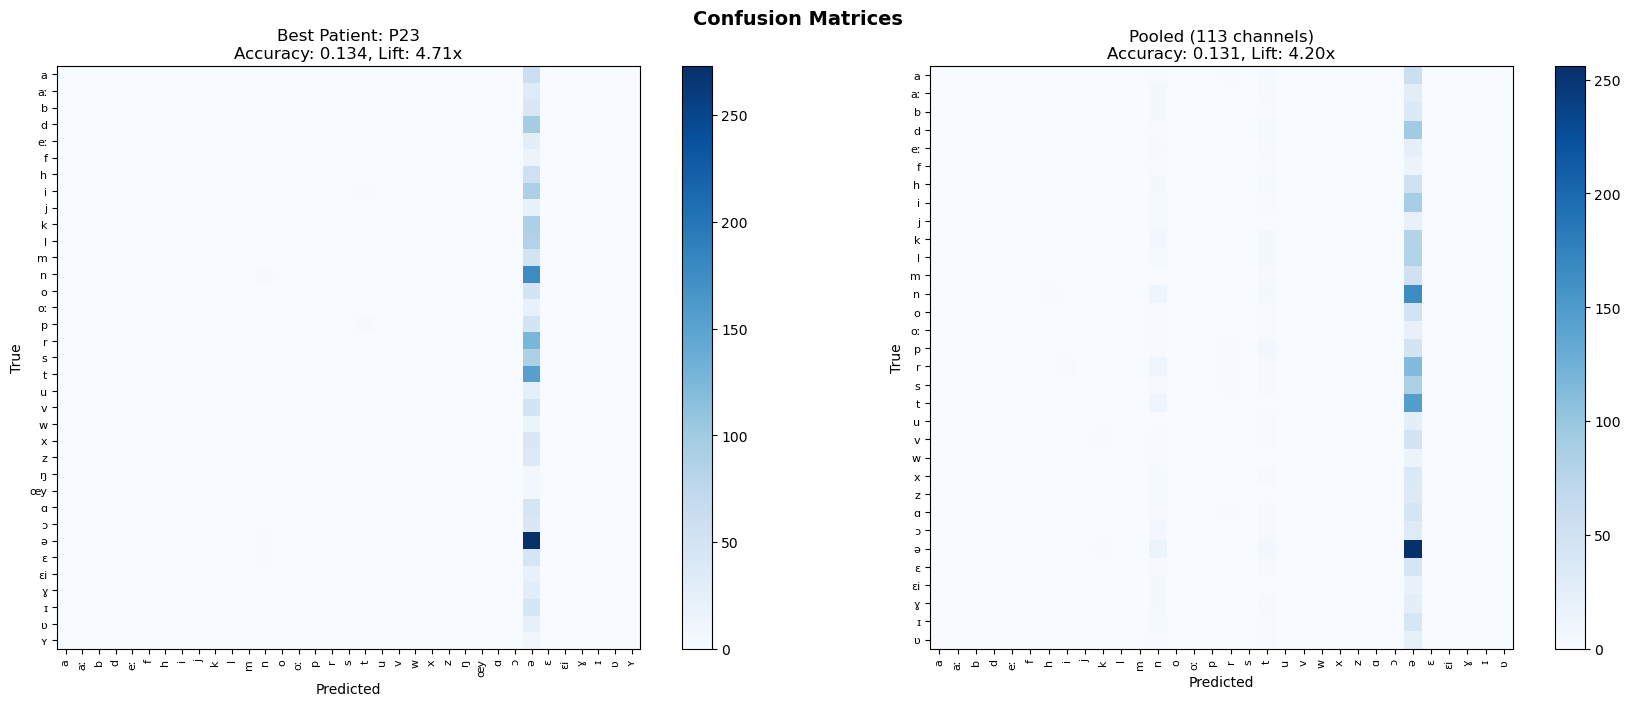

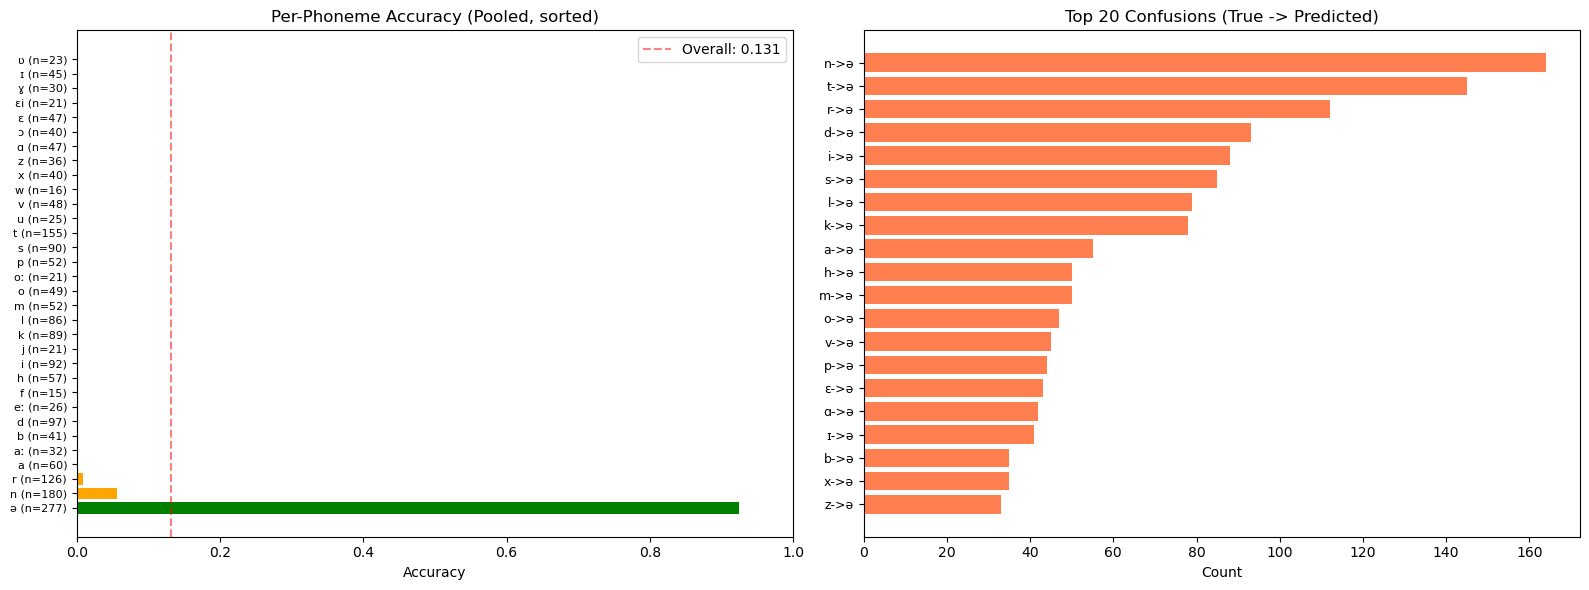


CLASSIFICATION REPORT (Pooled)
              precision    recall  f1-score   support

           a       0.00      0.00      0.00        60
          aː       0.00      0.00      0.00        32
           b       0.00      0.00      0.00        41
           d       0.00      0.00      0.00        97
          eː       0.00      0.00      0.00        26
           f       0.00      0.00      0.00        15
           h       0.00      0.00      0.00        57
           i       0.00      0.00      0.00        92
           j       0.00      0.00      0.00        21
           k       0.00      0.00      0.00        89
           l       0.00      0.00      0.00        86
           m       0.00      0.00      0.00        52
           n       0.09      0.06      0.07       180
           o       0.00      0.00      0.00        49
          oː       0.00      0.00      0.00        21
           p       0.00      0.00      0.00        52
           r       0.20      0.01      0.02      

In [58]:
def evaluate_feature_quality_v2(hg_pipeline, show_confusion=True):
    """
    Feature quality evaluation that handles variable shapes.
    
    Args:
        hg_pipeline: Pipeline with train data
        show_confusion: If True, show confusion matrix for best patient and pooled data
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import confusion_matrix, classification_report
    from collections import Counter
    
    print("="*70)
    print("FEATURE QUALITY EVALUATION")
    print("="*70)
    
    train = hg_pipeline.train
    features = train['features']
    labels = train['phoneme_labels']
    pids = train['phoneme_participant_ids']
    
    print(f"\n--- Basic Stats ---")
    print(f"Total samples: {len(features)}")
    print(f"Unique phonemes: {len(set(labels))}")
    print(f"Unique patients: {len(set(pids))}")
    
    # Check feature shapes
    shapes = [f.shape for f in features]
    unique_shapes = set(shapes)
    print(f"Unique feature shapes: {len(unique_shapes)}")
    
    # Analyze shape variation
    n_frames = [s[0] for s in shapes]
    n_channels = [s[1] for s in shapes]
    
    print(f"Time frames: min={min(n_frames)}, max={max(n_frames)}, unique={len(set(n_frames))}")
    print(f"Channels: min={min(n_channels)}, max={max(n_channels)}, unique={len(set(n_channels))}")
    
    # --- Per-Patient Analysis ---
    # print(f"\n--- Per-Patient Channel Counts ---")
    patient_channels = {}
    for pid, feat in zip(pids, features):
        if pid not in patient_channels:
            patient_channels[pid] = feat.shape[1]
    
    # for pid in sorted(patient_channels.keys())[:10]:
    #     print(f"  {pid}: {patient_channels[pid]} channels")
    # print(f"  ... ({len(patient_channels)} patients total)")
    
    # --- Evaluate per patient (same channel count) ---
    print(f"\n--- Per-Patient Classification Test ---")
    
    patient_results = {}
    patient_predictions = {}  # Store for confusion matrix
    
    for pid in sorted(set(pids)):
        # Get data for this patient
        mask = np.array([p == pid for p in pids])
        X_patient = [features[i] for i in range(len(features)) if mask[i]]
        y_patient = np.array([labels[i] for i in range(len(labels)) if mask[i]])
        
        # Average over time to get (1, n_channels) then flatten
        X_patient = np.vstack([f.mean(axis=0).reshape(1, -1) for f in X_patient])
        
        # Remove unknown labels
        valid = y_patient != '?'
        X_patient = X_patient[valid]
        y_patient = y_patient[valid]
        
        # Filter to classes with enough samples
        label_counts = Counter(y_patient)
        valid_classes = [c for c, count in label_counts.items() if count >= 5]
        
        if len(valid_classes) < 2:
            continue
        
        class_mask = np.isin(y_patient, valid_classes)
        X_filt = X_patient[class_mask]
        y_filt = y_patient[class_mask]
        
        if len(y_filt) < 20:
            continue
        
        # Scale and classify
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_filt)
        
        rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
        
        n_splits = min(5, min(Counter(y_filt).values()))
        if n_splits < 2:
            continue
            
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        
        try:
            scores = cross_val_score(rf, X_scaled, y_filt, cv=cv, scoring='accuracy')
            
            # Get predictions for confusion matrix
            y_pred = cross_val_predict(rf, X_scaled, y_filt, cv=cv)
            
            baseline = 1 / len(valid_classes)
            lift = scores.mean() / baseline
            
            patient_results[pid] = {
                'accuracy': scores.mean(),
                'baseline': baseline,
                'lift': lift,
                'n_samples': len(y_filt),
                'n_classes': len(valid_classes)
            }
            
            patient_predictions[pid] = {
                'y_true': y_filt,
                'y_pred': y_pred,
                'classes': valid_classes
            }
        except:
            continue
    
    # Print results
    print(f"\nPatient    Samples  Classes  Accuracy  Baseline  Lift")
    print("-" * 60)
    
    for pid in sorted(patient_results.keys()):
        r = patient_results[pid]
        print(f"{pid:10} {r['n_samples']:7}  {r['n_classes']:7}  {r['accuracy']:.3f}     {r['baseline']:.3f}     {r['lift']:.2f}x")
    
    # Summary
    if patient_results:
        avg_lift = np.mean([r['lift'] for r in patient_results.values()])
        avg_acc = np.mean([r['accuracy'] for r in patient_results.values()])
        print("-" * 60)
        print(f"{'Average':10} {'-':>7}  {'-':>7}  {avg_acc:.3f}     {'-':>5}     {avg_lift:.2f}x")
    
    # Find best patient
    best_pid = max(patient_results.keys(), key=lambda p: patient_results[p]['lift'])
    print(f"\nBest patient: {best_pid} (lift: {patient_results[best_pid]['lift']:.2f}x)")
    
    # --- Fixed-size feature test ---
    print(f"\n--- Testing with Summary Features (time-averaged) ---")
    
    # Group by channel count
    channel_groups = {}
    for i, (feat, label) in enumerate(zip(features, labels)):
        n_ch = feat.shape[1]
        if n_ch not in channel_groups:
            channel_groups[n_ch] = {'X': [], 'y': []}
        channel_groups[n_ch]['X'].append(feat.mean(axis=0))
        channel_groups[n_ch]['y'].append(label)
    
    print(f"\nChannel groups: {sorted(channel_groups.keys())}")
    
    # Test largest group
    largest_group = max(channel_groups.keys(), key=lambda k: len(channel_groups[k]['y']))
    X_largest = np.vstack(channel_groups[largest_group]['X'])
    y_largest = np.array(channel_groups[largest_group]['y'])
    
    # Filter
    valid = y_largest != '?'
    X_largest = X_largest[valid]
    y_largest = y_largest[valid]
    
    label_counts = Counter(y_largest)
    valid_classes = [c for c, count in label_counts.items() if count >= 10]
    class_mask = np.isin(y_largest, valid_classes)
    X_filt = X_largest[class_mask]
    y_filt = y_largest[class_mask]
    
    print(f"Largest channel group ({largest_group} channels): {len(y_filt)} samples, {len(valid_classes)} classes")
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_filt)
    
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(rf, X_scaled, y_filt, cv=cv, scoring='accuracy')
    
    # Get predictions for pooled confusion matrix
    y_pred_pooled = cross_val_predict(rf, X_scaled, y_filt, cv=cv)
    
    baseline = 1 / len(valid_classes)
    
    print(f"5-fold CV accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")
    print(f"Random baseline: {baseline:.3f}")
    print(f"Lift over baseline: {scores.mean() / baseline:.2f}x")
    
    # --- Confusion Matrices ---
    if show_confusion:
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
        
        # 1. Best patient confusion matrix
        best_data = patient_predictions[best_pid]
        y_true_best = best_data['y_true']
        y_pred_best = best_data['y_pred']
        classes_best = sorted(set(y_true_best) | set(y_pred_best))
        
        cm_best = confusion_matrix(y_true_best, y_pred_best, labels=classes_best)
        
        im1 = axes[0].imshow(cm_best, cmap='Blues')
        axes[0].set_xticks(range(len(classes_best)))
        axes[0].set_yticks(range(len(classes_best)))
        axes[0].set_xticklabels(classes_best, rotation=90, fontsize=8)
        axes[0].set_yticklabels(classes_best, fontsize=8)
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('True')
        axes[0].set_title(f'Best Patient: {best_pid}\nAccuracy: {patient_results[best_pid]["accuracy"]:.3f}, Lift: {patient_results[best_pid]["lift"]:.2f}x')
        plt.colorbar(im1, ax=axes[0])
        
        # 2. Pooled confusion matrix (largest channel group)
        classes_pooled = sorted(set(y_filt) | set(y_pred_pooled))
        cm_pooled = confusion_matrix(y_filt, y_pred_pooled, labels=classes_pooled)
        
        im2 = axes[1].imshow(cm_pooled, cmap='Blues')
        axes[1].set_xticks(range(len(classes_pooled)))
        axes[1].set_yticks(range(len(classes_pooled)))
        axes[1].set_xticklabels(classes_pooled, rotation=90, fontsize=8)
        axes[1].set_yticklabels(classes_pooled, fontsize=8)
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('True')
        axes[1].set_title(f'Pooled ({largest_group} channels)\nAccuracy: {scores.mean():.3f}, Lift: {scores.mean()/baseline:.2f}x')
        plt.colorbar(im2, ax=axes[1])
        
        plt.tight_layout()
        plt.show()
        
        # Per-phoneme accuracy for pooled data
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Calculate per-phoneme accuracy
        phoneme_acc = {}
        phoneme_counts = Counter(y_filt)
        
        for p in classes_pooled:
            correct = sum(1 for t, pred in zip(y_filt, y_pred_pooled) if t == p and pred == p)
            total = phoneme_counts.get(p, 0)
            phoneme_acc[p] = correct / total if total > 0 else 0
        
        # Sort by accuracy
        sorted_phonemes = sorted(phoneme_acc.keys(), key=lambda x: phoneme_acc[x], reverse=True)
        
        colors = ['green' if phoneme_acc[p] > scores.mean() else 'orange' if phoneme_acc[p] > 0 else 'red' 
                  for p in sorted_phonemes]
        
        axes[0].barh(range(len(sorted_phonemes)), [phoneme_acc[p] for p in sorted_phonemes], color=colors)
        axes[0].set_yticks(range(len(sorted_phonemes)))
        axes[0].set_yticklabels([f"{p} (n={phoneme_counts[p]})" for p in sorted_phonemes], fontsize=8)
        axes[0].set_xlabel('Accuracy')
        axes[0].set_title('Per-Phoneme Accuracy (Pooled, sorted)')
        axes[0].axvline(scores.mean(), color='red', linestyle='--', alpha=0.5, label=f'Overall: {scores.mean():.3f}')
        axes[0].legend()
        axes[0].set_xlim([0, 1])
        
        # Top confusions
        confusion_pairs = []
        for i, true_label in enumerate(classes_pooled):
            for j, pred_label in enumerate(classes_pooled):
                if true_label != pred_label and cm_pooled[i, j] > 0:
                    confusion_pairs.append((true_label, pred_label, cm_pooled[i, j]))
        
        confusion_pairs.sort(key=lambda x: x[2], reverse=True)
        top_confusions = confusion_pairs[:20]
        
        conf_labels = [f"{t}->{p}" for t, p, _ in top_confusions]
        conf_counts = [c for _, _, c in top_confusions]
        
        axes[1].barh(range(len(top_confusions)), conf_counts, color='coral')
        axes[1].set_yticks(range(len(top_confusions)))
        axes[1].set_yticklabels(conf_labels, fontsize=9)
        axes[1].set_xlabel('Count')
        axes[1].set_title('Top 20 Confusions (True -> Predicted)')
        axes[1].invert_yaxis()
        
        plt.tight_layout()
        plt.show()
        
        # Print classification report
        print("\n" + "="*70)
        print("CLASSIFICATION REPORT (Pooled)")
        print("="*70)
        print(classification_report(y_filt, y_pred_pooled, zero_division=0))
    
    return patient_results


# Run evaluation
results = evaluate_feature_quality_v2(high_gamma_pipeline, show_confusion=True)

In [37]:
def test_vowel_consonant(hg_pipeline):
    """Test binary vowel vs consonant classification."""
    
    vowels = {'a', 'e', 'i', 'o', 'u', 'ɑ', 'ɛ', 'ɪ', 'ɔ', 'ʏ', 'ə', 'eː', 'oː', 'aː', 'yː', 'øː', 'iː', 'uː'}
    
    train = hg_pipeline.train
    features = train['features']
    labels = train['phoneme_labels']
    pids = train['phoneme_participant_ids']
    
    # Create binary labels
    binary_labels = []
    for label in labels:
        if label == '?':
            binary_labels.append('?')
        elif label in vowels:
            binary_labels.append('vowel')
        else:
            binary_labels.append('consonant')
    
    binary_labels = np.array(binary_labels)
    
    # Group by channel count
    channel_groups = {}
    for i, (feat, label) in enumerate(zip(features, binary_labels)):
        if label == '?':
            continue
        n_ch = feat.shape[1]
        if n_ch not in channel_groups:
            channel_groups[n_ch] = {'X': [], 'y': []}
        channel_groups[n_ch]['X'].append(feat.mean(axis=0))
        channel_groups[n_ch]['y'].append(label)
    
    # Test largest group
    largest_ch = max(channel_groups.keys(), key=lambda k: len(channel_groups[k]['y']))
    X = np.vstack(channel_groups[largest_ch]['X'])
    y = np.array(channel_groups[largest_ch]['y'])
    
    print(f"Vowel vs Consonant Classification ({largest_ch} channels)")
    print(f"Samples: {len(y)} (vowels: {sum(y=='vowel')}, consonants: {sum(y=='consonant')})")
    
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from sklearn.preprocessing import StandardScaler
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
    
    print(f"5-fold CV accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")
    print(f"Random baseline: 0.500")
    print(f"Lift: {scores.mean() / 0.5:.2f}x")


test_vowel_consonant(high_gamma_pipeline)

Vowel vs Consonant Classification (130 channels)
Samples: 1415 (vowels: 546, consonants: 869)
5-fold CV accuracy: 0.611 (+/- 0.008)
Random baseline: 0.500
Lift: 1.22x


In [38]:
test_vowel_consonant(band_powers_pipeline)

Vowel vs Consonant Classification (780 channels)
Samples: 8109 (vowels: 2976, consonants: 5133)
5-fold CV accuracy: 0.632 (+/- 0.001)
Random baseline: 0.500
Lift: 1.26x


In [39]:
test_vowel_consonant(hjorth_pipeline)

Vowel vs Consonant Classification (1170 channels)
Samples: 8109 (vowels: 2976, consonants: 5133)
5-fold CV accuracy: 0.633 (+/- 0.000)
Random baseline: 0.500
Lift: 1.27x


In [59]:
def test_segmentation_approaches(pipeline, patient_id='P23', n_test_words=50):
    """
    Test different phoneme segmentation approaches on one patient.
    
    Args:
        pipeline: Pipeline with loaded data (needs split_result and word_segments_dict)
        patient_id: Which patient to test
        n_test_words: Number of words to test per approach
    """
    import numpy as np
    from collections import Counter
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from sklearn.preprocessing import StandardScaler
    
    print("="*70)
    print(f"TESTING SEGMENTATION APPROACHES - {patient_id}")
    print("="*70)
    
    # Get data for this patient
    split_result = pipeline.split_result
    word_segments_dict = split_result['word_segments_dict']
    detector = pipeline.detector
    config = pipeline.config
    
    if patient_id not in word_segments_dict:
        print(f"Patient {patient_id} not found!")
        return
    
    # Collect word instances for this patient
    instances = []
    for word, indices in split_result['train'].get(patient_id, {}).items():
        for idx in indices:
            instances.append({
                'word': word,
                'idx': idx,
                'data': word_segments_dict[patient_id]['words'][word]['instances'][idx]
            })
    
    if len(instances) < n_test_words:
        n_test_words = len(instances)
    
    print(f"Testing on {n_test_words} word instances from {patient_id}")
    print(f"Total available: {len(instances)} instances")
    
    # Define approaches to test
    approaches = {
        'raw_boundaries': {
            'description': 'Raw boundaries, no extension, no fixed window',
            'extend_short': False,
            'fixed_window': False,
            'drop_invalid': False
        },
        'extend_only': {
            'description': 'Extend short segments, no fixed window',
            'extend_short': True,
            'fixed_window': False,
            'drop_invalid': False
        },
        'fixed_window_only': {
            'description': 'No extension, fixed window (102 samples)',
            'extend_short': False,
            'fixed_window': True,
            'drop_invalid': False
        },
        'extend_and_fixed': {
            'description': 'Extend short + fixed window',
            'extend_short': True,
            'fixed_window': True,
            'drop_invalid': False
        },
        'drop_invalid': {
            'description': 'Drop segments outside [0.025, 0.4]s',
            'extend_short': False,
            'fixed_window': False,
            'drop_invalid': True
        },
        'extend_and_drop': {
            'description': 'Extend short + drop invalid words',
            'extend_short': True,
            'fixed_window': False,
            'drop_invalid': True
        }
    }
    
    results = {}
    
    for approach_name, settings in approaches.items():
        print(f"\n--- Testing: {approach_name} ---")
        print(f"    {settings['description']}")
        
        features = []
        labels = []
        dropped_words = 0
        dropped_phonemes = 0
        total_phonemes = 0
        
        for inst in instances[:n_test_words]:
            word = inst['word']
            word_data = inst['data']
            
            eeg_segment = word_data['eeg_segment']
            spec_segment = word_data['spectrogram_segment']
            audio_segment = word_data.get('audio_segment')
            
            # Get expected phonemes
            expected_phonemes = detector.phonetic_dict.extract_phonemes(word)
            if not expected_phonemes:
                continue
            
            total_phonemes += len(expected_phonemes)
            
            # Detect boundaries
            result = detector.detect_boundaries(
                spectrogram=spec_segment,
                word=word,
                participant_id=patient_id,
                word_position=0,
                use_multifeature=detector.use_multifeature,
                use_rms_boundaries=detector.use_rms_boundaries,
                audio_segment=audio_segment,
                audio_sr=config.audio_sr
            )
            
            boundary_samples = result.get('boundary_samples', [])
            segments = result.get('segments', [])
            
            # Check for segment/phoneme mismatch
            if len(segments) != len(expected_phonemes):
                dropped_words += 1
                dropped_phonemes += len(expected_phonemes)
                continue
            
            # Apply approach-specific processing
            min_samples = config.min_eeg_samples_for_features
            min_duration = config.min_phoneme_duration
            max_duration = config.max_phoneme_duration
            
            # Get segment boundaries
            if settings['extend_short']:
                seg_bounds = detector._extend_short_segments(
                    boundary_samples, 
                    eeg_segment.shape[0], 
                    min_samples
                )
            else:
                seg_bounds = [(boundary_samples[i], boundary_samples[i+1]) 
                              for i in range(len(boundary_samples)-1)]
            
            # Check durations if dropping invalid
            if settings['drop_invalid']:
                durations = [(end - start) / config.eeg_sr for start, end in seg_bounds]
                has_invalid = any(d < min_duration or d > max_duration for d in durations)
                if has_invalid:
                    dropped_words += 1
                    dropped_phonemes += len(expected_phonemes)
                    continue
            
            # Extract features for each phoneme
            word_valid = True
            word_features = []
            word_labels = []
            
            for j, (phoneme, (start, end)) in enumerate(zip(expected_phonemes, seg_bounds)):
                start = int(max(0, start))
                end = int(min(eeg_segment.shape[0], end))
                
                if start >= end:
                    word_valid = False
                    break
                
                raw_seg = eeg_segment[start:end]
                
                # Apply fixed window if requested
                if settings['fixed_window']:
                    target_samples = config.fixed_feature_samples
                    n_samples = raw_seg.shape[0]
                    
                    if n_samples > target_samples:
                        # Truncate from center
                        trim_start = (n_samples - target_samples) // 2
                        raw_seg = raw_seg[trim_start:trim_start + target_samples]
                    elif n_samples < target_samples:
                        # Pad with edge values
                        pad_total = target_samples - n_samples
                        pad_before = pad_total // 2
                        pad_after = pad_total - pad_before
                        raw_seg = np.pad(raw_seg, ((pad_before, pad_after), (0, 0)), mode='edge')
                
                # Check minimum samples for feature extraction
                if raw_seg.shape[0] < min_samples:
                    word_valid = False
                    break
                
                # Extract high gamma features
                try:
                    from extract_features import extractHG
                    feat = extractHG(raw_seg, config.eeg_sr)
                    
                    if feat.shape[0] == 0:
                        word_valid = False
                        break
                    
                    # Average over time
                    feat_avg = feat.mean(axis=0)
                    word_features.append(feat_avg)
                    word_labels.append(phoneme)
                    
                except Exception as e:
                    word_valid = False
                    break
            
            if word_valid and len(word_features) == len(expected_phonemes):
                features.extend(word_features)
                labels.extend(word_labels)
            else:
                dropped_words += 1
                dropped_phonemes += len(expected_phonemes)
        
        # Evaluate
        print(f"    Samples extracted: {len(features)}")
        print(f"    Words dropped: {dropped_words}")
        print(f"    Phonemes dropped: {dropped_phonemes}/{total_phonemes} ({100*dropped_phonemes/total_phonemes:.1f}%)")
        
        if len(features) < 20:
            print(f"    NOT ENOUGH DATA FOR CLASSIFICATION")
            results[approach_name] = {
                'accuracy': 0,
                'lift': 0,
                'n_samples': len(features),
                'drop_rate': dropped_phonemes / total_phonemes if total_phonemes > 0 else 1
            }
            continue
        
        # Prepare for classification
        X = np.array(features)
        y = np.array(labels)
        
        # Filter to classes with enough samples
        label_counts = Counter(y)
        valid_classes = [c for c, count in label_counts.items() if count >= 3]
        
        if len(valid_classes) < 2:
            print(f"    NOT ENOUGH CLASSES")
            results[approach_name] = {
                'accuracy': 0,
                'lift': 0,
                'n_samples': len(features),
                'drop_rate': dropped_phonemes / total_phonemes if total_phonemes > 0 else 1
            }
            continue
        
        mask = np.isin(y, valid_classes)
        X_filt = X[mask]
        y_filt = y[mask]
        
        # Scale and classify
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_filt)
        
        rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
        
        n_splits = min(3, min(Counter(y_filt).values()))
        if n_splits < 2:
            n_splits = 2
        
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        
        try:
            scores = cross_val_score(rf, X_scaled, y_filt, cv=cv, scoring='accuracy')
            baseline = 1 / len(valid_classes)
            lift = scores.mean() / baseline
            
            print(f"    Classes: {len(valid_classes)}")
            print(f"    Accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")
            print(f"    Baseline: {baseline:.3f}")
            print(f"    Lift: {lift:.2f}x")
            
            results[approach_name] = {
                'accuracy': scores.mean(),
                'lift': lift,
                'n_samples': len(X_filt),
                'n_classes': len(valid_classes),
                'drop_rate': dropped_phonemes / total_phonemes if total_phonemes > 0 else 1,
                'baseline': baseline
            }
        except Exception as e:
            print(f"    Classification failed: {e}")
            results[approach_name] = {
                'accuracy': 0,
                'lift': 0,
                'n_samples': len(features),
                'drop_rate': dropped_phonemes / total_phonemes if total_phonemes > 0 else 1
            }
    
    # Summary
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print(f"\n{'Approach':<20} {'Samples':<10} {'Drop%':<10} {'Classes':<10} {'Accuracy':<10} {'Lift':<10}")
    print("-"*70)
    
    for name, r in sorted(results.items(), key=lambda x: x[1].get('lift', 0), reverse=True):
        print(f"{name:<20} {r.get('n_samples', 0):<10} {r.get('drop_rate', 0)*100:<10.1f} "
              f"{r.get('n_classes', 0):<10} {r.get('accuracy', 0):<10.3f} {r.get('lift', 0):<10.2f}x")
    
    # Best approach
    best = max(results.items(), key=lambda x: x[1].get('lift', 0))
    print(f"\nBEST APPROACH: {best[0]} (lift: {best[1].get('lift', 0):.2f}x)")
    
    return results


# Run the test
results = test_segmentation_approaches(
    high_gamma_pipeline, 
    patient_id='P23',  # Best performing patient
    n_test_words=100
)

TESTING SEGMENTATION APPROACHES - P23
Testing on 100 word instances from P23
Total available: 500 instances

--- Testing: raw_boundaries ---
    Raw boundaries, no extension, no fixed window
AcousticChangeDetector:   Need 5 peaks but only found 3 for word 'huidige' (Patient P23)
AcousticChangeDetector:   Need 3 peaks but only found 2 for word 'staat' (Patient P23)
AcousticChangeDetector:   Need 4 peaks but only found 3 for word 'Zalig' (Patient P23)
    Samples extracted: 44
    Words dropped: 79
    Phonemes dropped: 235/279 (84.2%)
    Classes: 5
    Accuracy: 0.481 (+/- 0.026)
    Baseline: 0.200
    Lift: 2.41x

--- Testing: extend_only ---
    Extend short segments, no fixed window
AcousticChangeDetector:   Need 5 peaks but only found 3 for word 'huidige' (Patient P23)
AcousticChangeDetector:   Need 3 peaks but only found 2 for word 'staat' (Patient P23)
AcousticChangeDetector:   Need 4 peaks but only found 3 for word 'Zalig' (Patient P23)
    Samples extracted: 44
    Words dropp

In [24]:
def visualize_pipeline_features(pipeline, patient_id=None, save_path=None):
    """
    Visualize features already extracted by the pipeline.
    
    Includes:
    - Basic feature distributions
    - Transient/kurtosis features (computed from pipeline features)
    - Feature separability analysis
    - Phoneme heatmaps
    - Learning curves (overall and feature-specific)
    - Dendrograms
    
    Args:
        pipeline: Dutch30Pipeline with train/test data already extracted
        patient_id: Optional - filter to specific patient, or None for all
        save_path: Directory to save figures
    
    Returns:
        dict: Analysis results
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import mannwhitneyu, kurtosis, skew
    from scipy.signal import hilbert
    from sklearn.model_selection import learning_curve, StratifiedKFold
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
    from scipy.spatial.distance import pdist
    from collections import defaultdict
    import os
    
    if save_path:
        os.makedirs(save_path, exist_ok=True)
    
    # Check pipeline has data
    if not hasattr(pipeline, 'train') or pipeline.train is None:
        raise ValueError("Pipeline has no training data. Run steps 1-6 first.")
    
    train_data = pipeline.train
    
    # Get data from pipeline
    features_list = train_data['features']
    labels = train_data['phoneme_labels']
    words = train_data['phoneme_words']
    participant_ids = train_data['phoneme_participant_ids']
    
    # Filter by patient if specified
    if patient_id is not None:
        indices = [i for i, pid in enumerate(participant_ids) if pid == patient_id]
        if not indices:
            print(f"No data found for patient {patient_id}")
            return None
        features_list = [features_list[i] for i in indices]
        labels = [labels[i] for i in indices]
        words = [words[i] for i in indices]
        participant_ids = [participant_ids[i] for i in indices]
        print(f"Filtered to {len(indices)} samples for {patient_id}")
    
    print(f"Total samples: {len(features_list)}")
    print(f"Unique phonemes: {len(set(labels))}")
    print(f"Unique patients: {len(set(participant_ids))}")
    
    # Define vowels
    vowels = getattr(pipeline.config, 'vowels', None)
    if vowels is None:
        vowels = {
            # Short monophthongs
            'a', 'ɑ', 'ɛ', 'ɪ', 'i', 'ɔ', 'o', 'u', 'ʏ', 'y', 'ə', 'e', 'ø',
            
            # Long vowels (IPA length marker)
            'aː', 'eː', 'iː', 'oː', 'uː', 'yː', 'øː', 'ɑː', 'ɔː', 'ɛː', 'ɵː',
            
            # Long vowels (colon notation - in case your data uses this)
            'a:', 'e:', 'i:', 'o:', 'u:', 'y:', 'ø:', 'ɑ:', 'ɔ:', 'ɛ:', 'ɵ:',
            
            # Diphthongs
            'ɛi', 'œy', 'ɑu', 'ʌu',
        }
    
    # ========================================================================
    # FEATURE EXTRACTION FROM PIPELINE DATA
    # ========================================================================
    
    def extract_summary_features(feat):
        """
        Extract summary statistics from pipeline feature matrix.
        
        Args:
            feat: numpy array - can be (n_frames, n_channels) or (1, n_features)
        
        Returns:
            dict: Summary features including transient-like measures
        """
        if feat is None or feat.size == 0:
            return None
        
        # Handle different input shapes
        if feat.ndim == 1:
            feat = feat.reshape(1, -1)
        
        n_frames, n_features = feat.shape
        
        summary = {}
        
        # If single frame (1, n_features), treat n_features as the signal
        if n_frames == 1:
            signal = feat.flatten()
            
            # Basic statistics
            summary['mean'] = np.mean(signal)
            summary['std'] = np.std(signal)
            summary['max'] = np.max(signal)
            summary['min'] = np.min(signal)
            summary['range'] = summary['max'] - summary['min']
            
            # Energy features
            summary['total_energy'] = np.sum(signal ** 2)
            summary['mean_energy'] = np.mean(signal ** 2)
            
            # Distribution across features/channels
            summary['channel_variance'] = np.var(signal)
            summary['channel_range'] = summary['range']
            
            # Temporal features (not applicable for single frame)
            summary['temporal_mean'] = summary['mean']
            summary['temporal_std'] = 0
            summary['temporal_range'] = 0
            summary['temporal_variance'] = 0
            
            # Duration
            summary['n_frames'] = n_frames
            summary['n_channels'] = n_features
            
            # Transient features from the feature vector
            if len(signal) > 3:
                kurt_val = kurtosis(signal, nan_policy='omit')
                summary['kurtosis'] = kurt_val if np.isfinite(kurt_val) else 0
                
                skew_val = skew(signal, nan_policy='omit')
                summary['skewness'] = skew_val if np.isfinite(skew_val) else 0
            else:
                summary['kurtosis'] = 0
                summary['skewness'] = 0
            
            # Spatial kurtosis (across channels/features)
            summary['channel_kurtosis'] = summary['kurtosis']
            summary['temporal_kurtosis'] = 0
            
            # Peak-to-RMS
            rms = np.sqrt(np.mean(signal ** 2))
            summary['peak_to_rms'] = np.max(np.abs(signal)) / (rms + 1e-10)
            summary['crest_factor'] = np.max(np.abs(signal)) / (np.std(signal) + 1e-10)
            
            # Envelope features (use signal directly)
            summary['envelope_kurtosis'] = summary['kurtosis']
            summary['envelope_skewness'] = summary['skewness']
            summary['envelope_std'] = summary['std']
            
            # Windowed kurtosis (split signal into windows)
            if len(signal) >= 20:
                n_windows = 5
                window_size = len(signal) // n_windows
                window_kurtosis = []
                
                for i in range(n_windows):
                    window = signal[i * window_size:(i + 1) * window_size]
                    if len(window) > 3:
                        wk = kurtosis(window, nan_policy='omit')
                        if np.isfinite(wk):
                            window_kurtosis.append(wk)
                
                if window_kurtosis:
                    summary['kurtosis_windowed_mean'] = np.mean(window_kurtosis)
                    summary['kurtosis_windowed_max'] = np.max(window_kurtosis)
                    summary['kurtosis_windowed_std'] = np.std(window_kurtosis) if len(window_kurtosis) > 1 else 0
                else:
                    summary['kurtosis_windowed_mean'] = 0
                    summary['kurtosis_windowed_max'] = 0
                    summary['kurtosis_windowed_std'] = 0
            else:
                summary['kurtosis_windowed_mean'] = 0
                summary['kurtosis_windowed_max'] = 0
                summary['kurtosis_windowed_std'] = 0
            
            # Line length and zero crossing (across feature vector)
            summary['line_length'] = np.sum(np.abs(np.diff(signal))) / (len(signal) + 1e-10)
            centered = signal - np.mean(signal)
            summary['zero_crossing'] = np.sum(np.abs(np.diff(np.sign(centered))) > 0) / (len(centered) + 1e-10)
            
        else:
            # Original logic for (n_frames, n_channels) data
            flat = feat.flatten()
            
            # Basic statistics
            summary['mean'] = np.mean(feat)
            summary['std'] = np.std(feat)
            summary['max'] = np.max(feat)
            summary['min'] = np.min(feat)
            summary['range'] = summary['max'] - summary['min']
            
            # Temporal features (across frames)
            frame_means = np.mean(feat, axis=1)
            summary['temporal_mean'] = np.mean(frame_means)
            summary['temporal_std'] = np.std(frame_means)
            summary['temporal_range'] = np.max(frame_means) - np.min(frame_means)
            
            # Channel features (across channels)
            channel_means = np.mean(feat, axis=0)
            summary['channel_variance'] = np.var(channel_means)
            summary['channel_range'] = np.max(channel_means) - np.min(channel_means)
            
            # Energy features
            summary['total_energy'] = np.sum(feat ** 2)
            summary['mean_energy'] = np.mean(feat ** 2)
            
            # Temporal variance
            summary['temporal_variance'] = np.mean(np.var(feat, axis=0))
            
            # Duration
            summary['n_frames'] = n_frames
            summary['n_channels'] = n_features
            
            # Kurtosis features
            if len(flat) > 3:
                kurt_val = kurtosis(flat, nan_policy='omit')
                summary['kurtosis'] = kurt_val if np.isfinite(kurt_val) else 0
                
                skew_val = skew(flat, nan_policy='omit')
                summary['skewness'] = skew_val if np.isfinite(skew_val) else 0
            else:
                summary['kurtosis'] = 0
                summary['skewness'] = 0
            
            # Temporal kurtosis
            if len(frame_means) > 3:
                temp_kurt = kurtosis(frame_means, nan_policy='omit')
                summary['temporal_kurtosis'] = temp_kurt if np.isfinite(temp_kurt) else 0
            else:
                summary['temporal_kurtosis'] = 0
            
            # Channel kurtosis
            if len(channel_means) > 3:
                chan_kurt = kurtosis(channel_means, nan_policy='omit')
                summary['channel_kurtosis'] = chan_kurt if np.isfinite(chan_kurt) else 0
            else:
                summary['channel_kurtosis'] = 0
            
            # Peak-to-RMS
            rms = np.sqrt(np.mean(feat ** 2))
            summary['peak_to_rms'] = np.max(np.abs(feat)) / (rms + 1e-10)
            summary['crest_factor'] = np.max(np.abs(feat)) / (np.std(feat) + 1e-10)
            
            # Envelope features
            if len(frame_means) > 3:
                env_kurt = kurtosis(frame_means, nan_policy='omit')
                summary['envelope_kurtosis'] = env_kurt if np.isfinite(env_kurt) else 0
                
                env_skew = skew(frame_means, nan_policy='omit')
                summary['envelope_skewness'] = env_skew if np.isfinite(env_skew) else 0
            else:
                summary['envelope_kurtosis'] = 0
                summary['envelope_skewness'] = 0
            
            summary['envelope_std'] = np.std(frame_means)
            
            # Windowed kurtosis
            if n_frames >= 6:
                n_windows = min(5, n_frames // 2)
                window_size = n_frames // n_windows
                window_kurtosis = []
                
                for i in range(n_windows):
                    window = feat[i * window_size:(i + 1) * window_size, :].flatten()
                    if len(window) > 3:
                        wk = kurtosis(window, nan_policy='omit')
                        if np.isfinite(wk):
                            window_kurtosis.append(wk)
                
                if window_kurtosis:
                    summary['kurtosis_windowed_mean'] = np.mean(window_kurtosis)
                    summary['kurtosis_windowed_max'] = np.max(window_kurtosis)
                    summary['kurtosis_windowed_std'] = np.std(window_kurtosis) if len(window_kurtosis) > 1 else 0
                else:
                    summary['kurtosis_windowed_mean'] = 0
                    summary['kurtosis_windowed_max'] = 0
                    summary['kurtosis_windowed_std'] = 0
            else:
                summary['kurtosis_windowed_mean'] = 0
                summary['kurtosis_windowed_max'] = 0
                summary['kurtosis_windowed_std'] = 0
            
            # Line length and zero crossing
            summary['line_length'] = np.sum(np.abs(np.diff(frame_means))) / (len(frame_means) + 1e-10)
            centered = frame_means - np.mean(frame_means)
            summary['zero_crossing'] = np.sum(np.abs(np.diff(np.sign(centered))) > 0) / (len(centered) + 1e-10)
        
        return summary
        # ========================================================================
        # EXTRACT FEATURES FROM ALL SAMPLES
        # ========================================================================
        
    print("Extracting summary features from pipeline data...")
    summaries = []
    valid_indices = []
        
    for i, feat in enumerate(features_list):
        s = extract_summary_features(feat)
        if s is not None:
            summaries.append(s)
            valid_indices.append(i)
        
    # Filter labels to valid indices
    labels = [labels[i] for i in valid_indices]
    words = [words[i] for i in valid_indices]
    participant_ids = [participant_ids[i] for i in valid_indices]
        
    print(f"Valid samples after filtering: {len(summaries)}")
        
    if len(summaries) == 0:
        print("No valid samples found!")
        return None
        
    # Get feature names from first summary
    feature_names = list(summaries[0].keys())
    print(f"Extracted {len(feature_names)} features: {feature_names[:5]}...")
        
    # Create feature matrix
    X = np.array([[s[fn] for fn in feature_names] for s in summaries])
        
    # Create binary labels (vowel vs consonant)
    is_vowel = [1 if label in vowels else 0 for label in labels]
    y = np.array(is_vowel)
        
    # Handle NaN/Inf
    X = np.nan_to_num(X, nan=0, posinf=0, neginf=0)
        
    n_vowels = sum(y)
    n_consonants = len(y) - n_vowels
    print(f"Vowels: {n_vowels}, Consonants: {n_consonants}")
        
    baseline = max(n_vowels, n_consonants) / len(y)
    print(f"Baseline accuracy: {baseline:.2f}")
        
    # ========================================================================
    # HELPER FUNCTIONS
    # ========================================================================
    
    def cohens_d(g1, g2):
        n1, n2 = len(g1), len(g2)
        if n1 < 2 or n2 < 2:
            return 0
        var1, var2 = np.var(g1, ddof=1), np.var(g2, ddof=1)
        pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
        return abs(np.mean(g1) - np.mean(g2)) / (pooled_std + 1e-10)
    
    def sig_str(p):
        if p < 0.001: return "***"
        if p < 0.01: return "**"
        if p < 0.05: return "*"
        return "ns"
    
        
    # Compute statistics for each feature
    comparison_results = {}
    for i, feat_name in enumerate(feature_names):
        vowel_vals = X[y == 1, i]
        cons_vals = X[y == 0, i]
        
        if len(vowel_vals) > 1 and len(cons_vals) > 1:
            try:
                _, pval = mannwhitneyu(vowel_vals, cons_vals, alternative='two-sided')
            except:
                pval = 1.0
            d = cohens_d(vowel_vals, cons_vals)
            comparison_results[feat_name] = {
                'pval': pval,
                'd': d,
                'vowel_mean': np.mean(vowel_vals),
                'cons_mean': np.mean(cons_vals),
                'vowel_vals': vowel_vals,
                'cons_vals': cons_vals
            }
    
    # Title suffix for patient
    title_patient = f" - {patient_id}" if patient_id else " - All Patients"
    
    # Define feature groups
    standard_features = ['mean', 'std', 'total_energy', 'mean_energy', 
                         'temporal_variance', 'channel_variance', 'n_frames', 'range']
    standard_features = [f for f in standard_features if f in feature_names]
    
    transient_features = ['kurtosis', 'temporal_kurtosis', 'channel_kurtosis',
                          'envelope_kurtosis', 'kurtosis_windowed_max', 'kurtosis_windowed_mean',
                          'peak_to_rms', 'crest_factor', 'skewness', 'envelope_skewness',
                          'line_length', 'zero_crossing']
    transient_features = [f for f in transient_features if f in feature_names]
    
    # ========================================================================
    # FIGURE 1: Standard Feature Distributions
    # ========================================================================
    
    n_std = len(standard_features)
    n_cols = 4
    n_rows = max(1, (n_std + n_cols - 1) // n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle(f'Standard Features: Vowel vs Consonant{title_patient}\n'
                 f'Method: {pipeline.feature_extraction_method} | '
                 f'Green = d>0.5 (good), Red = d<0.2 (poor)',
                 fontsize=12, fontweight='bold')
    
    for idx, feat_name in enumerate(standard_features):
        ax = axes[idx // n_cols, idx % n_cols]
        
        if feat_name not in comparison_results:
            ax.text(0.5, 0.5, f'{feat_name}\nNo data', ha='center', va='center', 
                    transform=ax.transAxes)
            continue
        
        res = comparison_results[feat_name]
        vowel_vals = res['vowel_vals']
        cons_vals = res['cons_vals']
        d = res['d']
        pval = res['pval']
        
        all_vals = np.concatenate([vowel_vals, cons_vals])
        bins = np.linspace(np.percentile(all_vals, 2), np.percentile(all_vals, 98), 30)
        
        ax.hist(vowel_vals, bins=bins, alpha=0.5, color='coral', density=True, 
                label='Vowels', edgecolor='darkred')
        ax.hist(cons_vals, bins=bins, alpha=0.5, color='steelblue', density=True, 
                label='Consonants', edgecolor='darkblue')
        
        ax.axvline(np.mean(vowel_vals), color='darkred', linestyle='--', linewidth=2)
        ax.axvline(np.mean(cons_vals), color='darkblue', linestyle='--', linewidth=2)
        
        if d > 0.5:
            ax.set_facecolor('#e8f5e9')
        elif d < 0.2:
            ax.set_facecolor('#ffebee')
        
        ax.set_title(f"{feat_name}\nd={d:.2f} ({sig_str(pval)})", fontsize=10)
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        
        if idx == 0:
            ax.legend(fontsize=8)
    
    for idx in range(len(standard_features), n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, f"1_standard_distributions.png"), 
                    dpi=150, bbox_inches='tight')
        print(f"Saved: 1_standard_distributions.png")
    
    plt.show()
    
    # ========================================================================
    # FIGURE 2: Transient/Kurtosis Feature Distributions
    # ========================================================================
    
    n_trans = len(transient_features)
    n_cols = 4
    n_rows = max(1, (n_trans + n_cols - 1) // n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle(f'Transient/Kurtosis Features: Vowel vs Consonant{title_patient}\n'
                 f'These features capture burst/transient activity patterns',
                 fontsize=12, fontweight='bold')
    
    for idx, feat_name in enumerate(transient_features):
        ax = axes[idx // n_cols, idx % n_cols]
        
        if feat_name not in comparison_results:
            ax.text(0.5, 0.5, f'{feat_name}\nNo data', ha='center', va='center', 
                    transform=ax.transAxes)
            continue
        
        res = comparison_results[feat_name]
        vowel_vals = res['vowel_vals']
        cons_vals = res['cons_vals']
        d = res['d']
        pval = res['pval']
        
        all_vals = np.concatenate([vowel_vals, cons_vals])
        bins = np.linspace(np.percentile(all_vals, 2), np.percentile(all_vals, 98), 30)
        
        ax.hist(vowel_vals, bins=bins, alpha=0.5, color='coral', density=True, 
                label='Vowels', edgecolor='darkred')
        ax.hist(cons_vals, bins=bins, alpha=0.5, color='steelblue', density=True, 
                label='Consonants', edgecolor='darkblue')
        
        ax.axvline(np.mean(vowel_vals), color='darkred', linestyle='--', linewidth=2)
        ax.axvline(np.mean(cons_vals), color='darkblue', linestyle='--', linewidth=2)
        
        if d > 0.5:
            ax.set_facecolor('#e8f5e9')
        elif d < 0.2:
            ax.set_facecolor('#ffebee')
        
        ax.set_title(f"{feat_name}\nd={d:.2f} ({sig_str(pval)})", fontsize=10)
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        
        if idx == 0:
            ax.legend(fontsize=8)
    
    for idx in range(len(transient_features), n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, f"2_transient_distributions.png"), 
                    dpi=150, bbox_inches='tight')
        print(f"Saved: 2_transient_distributions.png")
    
    plt.show()
    
    # ========================================================================
    # FIGURE 3: Feature Separability Ranking
    # ========================================================================
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"Feature Separability Analysis{title_patient}\n"
                 f"Cohen's d: <0.2 negligible, 0.2-0.5 small, 0.5-0.8 medium, >0.8 large",
                 fontsize=13, fontweight='bold')
    
    sorted_features = sorted(comparison_results.keys(), 
                             key=lambda f: comparison_results[f]['d'], 
                             reverse=True)
    
    # Top left: All features ranked
    ax = axes[0, 0]
    top_n = min(20, len(sorted_features))
    x = np.arange(top_n)
    d_vals = [comparison_results[f]['d'] for f in sorted_features[:top_n]]
    colors = ['green' if d > 0.5 else 'orange' if d > 0.2 else 'red' for d in d_vals]
    
    ax.barh(x, d_vals, color=colors, alpha=0.7)
    ax.set_yticks(x)
    ax.set_yticklabels(sorted_features[:top_n], fontsize=9)
    ax.set_xlabel("Cohen's d")
    ax.set_title(f"Top {top_n} Features by Effect Size")
    ax.axvline(0.2, color='gray', linestyle=':', label='Small (0.2)')
    ax.axvline(0.5, color='gray', linestyle='--', label='Medium (0.5)')
    ax.axvline(0.8, color='gray', linestyle='-', label='Large (0.8)')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Top right: Transient features only
    ax = axes[0, 1]
    transient_in_results = [f for f in transient_features if f in comparison_results]
    
    if transient_in_results:
        x_trans = np.arange(len(transient_in_results))
        d_trans = [comparison_results[f]['d'] for f in transient_in_results]
        colors_trans = ['green' if d > 0.5 else 'orange' if d > 0.2 else 'red' for d in d_trans]
        
        ax.barh(x_trans, d_trans, color=colors_trans, alpha=0.7)
        ax.set_yticks(x_trans)
        ax.set_yticklabels(transient_in_results, fontsize=9)
        ax.set_xlabel("Cohen's d")
        ax.set_title("Transient/Kurtosis Features Only")
        ax.axvline(0.2, color='gray', linestyle=':')
        ax.axvline(0.5, color='gray', linestyle='--')
        ax.grid(True, alpha=0.3, axis='x')
    else:
        ax.text(0.5, 0.5, 'No transient features', ha='center', va='center', 
                transform=ax.transAxes)
    
    # Bottom left: Standard vs Transient comparison
    ax = axes[1, 0]
    
    std_d = [comparison_results[f]['d'] for f in standard_features if f in comparison_results]
    trans_d = [comparison_results[f]['d'] for f in transient_features if f in comparison_results]
    
    bp = ax.boxplot([std_d, trans_d], labels=['Standard', 'Transient'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('coral')
    
    ax.axhline(0.2, color='gray', linestyle=':', alpha=0.7)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.7)
    ax.set_ylabel("Cohen's d")
    ax.set_title("Standard vs Transient Features")
    ax.grid(True, alpha=0.3, axis='y')
    
    # Bottom right: Summary text
    ax = axes[1, 1]
    
    summary_text = f"SUMMARY\n{'='*40}\n\n"
    summary_text += f"Samples: {len(y)} ({n_vowels} V, {n_consonants} C)\n"
    summary_text += f"Baseline: {baseline:.2f}\n\n"
    
    summary_text += "TOP 5 OVERALL:\n"
    for i, f in enumerate(sorted_features[:5]):
        d = comparison_results[f]['d']
        summary_text += f"  {i+1}. {f}: d={d:.3f}\n"
    
    summary_text += "\nTOP 5 TRANSIENT:\n"
    trans_sorted = sorted(transient_in_results, key=lambda f: comparison_results[f]['d'], reverse=True)
    for i, f in enumerate(trans_sorted[:5]):
        d = comparison_results[f]['d']
        summary_text += f"  {i+1}. {f}: d={d:.3f}\n"
    
    ax.text(0.1, 0.95, summary_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, f"3_separability.png"), 
                    dpi=150, bbox_inches='tight')
        print(f"Saved: 3_separability.png")
    
    plt.show()
    
    # ========================================================================
    # FIGURE 4: Phoneme Heatmap
    # ========================================================================
    
    all_phonemes = sorted(set(labels), key=lambda p: (p not in vowels, p))
    n_phonemes = len(all_phonemes)
    
    # Select features for heatmap (mix of standard and transient)
    heatmap_features = ['mean_energy', 'temporal_variance', 'kurtosis', 
                        'temporal_kurtosis', 'peak_to_rms', 'zero_crossing',
                        'envelope_kurtosis', 'n_frames']
    heatmap_features = [f for f in heatmap_features if f in feature_names]
    
    if not heatmap_features:
        heatmap_features = feature_names[:8]
    
    # Build phoneme feature matrix
    phoneme_features = defaultdict(lambda: defaultdict(list))
    for i, label in enumerate(labels):
        for j, feat_name in enumerate(feature_names):
            phoneme_features[label][feat_name].append(X[i, j])
    
    matrix = np.zeros((n_phonemes, len(heatmap_features)))
    for i, phoneme in enumerate(all_phonemes):
        for j, feat_name in enumerate(heatmap_features):
            vals = phoneme_features[phoneme][feat_name]
            matrix[i, j] = np.mean(vals) if vals else 0
    
    # Z-score normalize columns
    for j in range(matrix.shape[1]):
        if np.std(matrix[:, j]) > 0:
            matrix[:, j] = (matrix[:, j] - np.mean(matrix[:, j])) / np.std(matrix[:, j])
    
    fig_height = max(8, n_phonemes * 0.35)
    fig, ax = plt.subplots(figsize=(12, fig_height))
    
    fig.suptitle(f"Phoneme Feature Heatmap ({n_phonemes} phonemes){title_patient}\n"
                 f"V = vowel | Red = high, Blue = low (z-scored)",
                 fontsize=12, fontweight='bold')
    
    im = ax.imshow(matrix, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
    
    ax.set_xticks(range(len(heatmap_features)))
    ax.set_xticklabels(heatmap_features, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(n_phonemes))
    
    fontsize = 10 if n_phonemes <= 20 else 8 if n_phonemes <= 40 else 6
    ax.set_yticklabels(all_phonemes, fontsize=fontsize)
    
    for i, p in enumerate(all_phonemes):
        if p in vowels:
            ax.text(-0.7, i, 'V', ha='center', va='center', fontsize=fontsize, 
                    color='coral', fontweight='bold')
    
    plt.colorbar(im, label='Z-score', shrink=0.8)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(os.path.join(save_path, f"4_phoneme_heatmap.png"), 
                    dpi=150, bbox_inches='tight')
        print(f"Saved: 4_phoneme_heatmap.png")
    
    plt.show()
    
    # ========================================================================
    # FIGURE 5: Learning Curves - All Features
    # ========================================================================
    
    if len(y) >= 30:
        print("\nComputing learning curves...")
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        n_samples = len(y)
        min_train = max(10, int(n_samples * 0.1))
        max_train = int(n_samples * 0.8)
        train_sizes = np.linspace(min_train, max_train, 8).astype(int)
        
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
        
        train_sizes_out, train_scores, test_scores = learning_curve(
            clf, X_scaled, y, train_sizes=train_sizes, cv=cv,
            scoring='accuracy', n_jobs=-1, shuffle=True, random_state=42
        )
        
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)
        train_mean = np.mean(train_scores, axis=1)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"Learning Curves - All {len(feature_names)} Features{title_patient}", 
                     fontsize=13, fontweight='bold')
        
        ax = axes[0]
        ax.fill_between(train_sizes_out, test_mean - test_std, test_mean + test_std, 
                        alpha=0.2, color='steelblue')
        ax.plot(train_sizes_out, test_mean, 'o-', color='steelblue', linewidth=2, 
                label='Test accuracy')
        ax.axhline(baseline, color='red', linestyle='--', linewidth=1.5, 
                   label=f'Baseline ({baseline:.2f})')
        ax.set_xlabel('Training Samples')
        ax.set_ylabel('Accuracy')
        ax.set_title('Test Accuracy vs Training Size')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.4, 1.0)
        
        ax = axes[1]
        ax.plot(train_sizes_out, train_mean, 'o--', color='coral', 
                linewidth=1.5, label='Train')
        ax.plot(train_sizes_out, test_mean, 'o-', color='steelblue', 
                linewidth=2, label='Test')
        ax.axhline(baseline, color='red', linestyle='--', linewidth=1.5)
        ax.set_xlabel('Training Samples')
        ax.set_ylabel('Accuracy')
        ax.set_title('Train vs Test (gap = overfitting)')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.4, 1.0)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(os.path.join(save_path, f"5_learning_curves_all.png"), 
                        dpi=150, bbox_inches='tight')
            print(f"Saved: 5_learning_curves_all.png")
        
        plt.show()
        
        # ====================================================================
        # FIGURE 6: Feature-Specific Learning Curves (Kurtosis/Transient Focus)
        # ====================================================================
        
        print("\nComputing feature-specific learning curves...")
        
        # Select key features for individual analysis
        key_features = ['kurtosis', 'temporal_kurtosis', 'envelope_kurtosis',
                        'peak_to_rms', 'mean_energy', 'zero_crossing']
        key_features = [f for f in key_features if f in feature_names][:6]
        
        if key_features:
            n_key = len(key_features)
            n_cols = 3
            n_rows = (n_key + n_cols - 1) // n_cols
            
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
            axes = axes.flatten() if n_rows > 1 else axes
            if n_rows == 1 and n_cols > 1:
                axes = list(axes)
            
            fig.suptitle(f'Feature-Specific Learning Curves{title_patient}\n'
                         f'Focus on transient/kurtosis features',
                         fontsize=13, fontweight='bold')
            
            for idx, feat_name in enumerate(key_features):
                ax = axes[idx] if isinstance(axes, (list, np.ndarray)) else axes
                
                feat_idx = feature_names.index(feat_name)
                X_single = X_scaled[:, feat_idx:feat_idx+1]
                
                try:
                    _, _, test_single = learning_curve(
                        LogisticRegression(max_iter=500, random_state=42),
                        X_single, y, train_sizes=train_sizes, cv=cv,
                        scoring='accuracy', n_jobs=-1
                    )
                    
                    test_mean_single = np.mean(test_single, axis=1)
                    test_std_single = np.std(test_single, axis=1)
                    
                    ax.fill_between(train_sizes_out, 
                                    test_mean_single - test_std_single,
                                    test_mean_single + test_std_single, 
                                    alpha=0.2, color='steelblue')
                    ax.plot(train_sizes_out, test_mean_single, 'o-', color='steelblue',
                            linewidth=2, markersize=5)
                    ax.axhline(baseline, color='red', linestyle='--', linewidth=1.5)
                    
                    d = comparison_results[feat_name]['d'] if feat_name in comparison_results else 0
                    final_acc = test_mean_single[-1]
                    
                    ax.set_title(f'{feat_name}\nd={d:.2f} | Final acc={final_acc:.2f}', fontsize=10)
                    ax.set_xlabel('Training Samples')
                    ax.set_ylabel('Test Accuracy')
                    ax.grid(True, alpha=0.3)
                    ax.set_ylim(0.4, 0.8)
                    
                except Exception as e:
                    ax.text(0.5, 0.5, f'{feat_name}\nError: {str(e)[:20]}', 
                            ha='center', va='center', transform=ax.transAxes)
            
            # Hide unused
            if isinstance(axes, (list, np.ndarray)):
                for idx in range(len(key_features), len(axes)):
                    axes[idx].axis('off')
            
            plt.tight_layout()
            
            if save_path:
                plt.savefig(os.path.join(save_path, f"6_learning_curves_features.png"), 
                            dpi=150, bbox_inches='tight')
                print(f"Saved: 6_learning_curves_features.png")
            
            plt.show()
        
        # ====================================================================
        # FIGURE 7: Feature Group Learning Curves
        # ====================================================================
        
        print("\nComputing feature group learning curves...")
        
        feature_groups = {
            'Transient/Kurtosis': [f for f in transient_features if f in feature_names],
            'Standard': [f for f in standard_features if f in feature_names],
            'All Features': feature_names
        }
        
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(f'Learning Curves by Feature Group{title_patient}', 
                     fontsize=13, fontweight='bold')
        
        for idx, (group_name, group_features) in enumerate(feature_groups.items()):
            ax = axes[idx]
            
            if not group_features:
                ax.text(0.5, 0.5, f'{group_name}\nNo features', 
                        ha='center', va='center', transform=ax.transAxes)
                continue
            
            group_indices = [feature_names.index(f) for f in group_features]
            X_group = X_scaled[:, group_indices]
            
            try:
                _, _, test_group = learning_curve(
                    RandomForestClassifier(n_estimators=30, max_depth=4, random_state=42, n_jobs=-1),
                    X_group, y, train_sizes=train_sizes, cv=cv,
                    scoring='accuracy', n_jobs=-1
                )
                
                test_mean_group = np.mean(test_group, axis=1)
                test_std_group = np.std(test_group, axis=1)
                
                ax.fill_between(train_sizes_out, 
                                test_mean_group - test_std_group,
                                test_mean_group + test_std_group, 
                                alpha=0.2, color='steelblue')
                ax.plot(train_sizes_out, test_mean_group, 'o-', color='steelblue',
                        linewidth=2, markersize=5)
                ax.axhline(baseline, color='red', linestyle='--', linewidth=1.5)
                
                ax.set_title(f'{group_name}\n({len(group_features)} features)\n'
                             f'Final acc={test_mean_group[-1]:.2f}', fontsize=10)
                ax.set_xlabel('Training Samples')
                ax.set_ylabel('Test Accuracy')
                ax.grid(True, alpha=0.3)
                ax.set_ylim(0.4, 0.9)
                
            except Exception as e:
                ax.text(0.5, 0.5, f'{group_name}\nError', 
                        ha='center', va='center', transform=ax.transAxes)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(os.path.join(save_path, f"7_learning_curves_groups.png"), 
                        dpi=150, bbox_inches='tight')
            print(f"Saved: 7_learning_curves_groups.png")
        
        plt.show()
        
    else:
        print(f"Not enough samples ({len(y)}) for learning curve analysis")
        train_sizes_out = None
    
    # ========================================================================
    # FIGURE 8: Phoneme Dendrogram (Overall)
    # ========================================================================
    
    print("\nComputing dendrograms...")
    
    if n_phonemes >= 3:
        # Build phoneme-level feature matrix
        phoneme_matrix = np.zeros((n_phonemes, len(feature_names)))
        phoneme_counts = []
        
        for i, phoneme in enumerate(all_phonemes):
            indices = [j for j, lab in enumerate(labels) if lab == phoneme]
            phoneme_counts.append(len(indices))
            for k in range(len(feature_names)):
                phoneme_matrix[i, k] = np.mean(X[indices, k])
        
        # Normalize
        phoneme_matrix_norm = (phoneme_matrix - np.mean(phoneme_matrix, axis=0)) / (np.std(phoneme_matrix, axis=0) + 1e-10)
        
        # Linkage
        linkage_matrix = linkage(phoneme_matrix_norm, method='ward')
        
        # Create dendrogram
        fig, ax = plt.subplots(figsize=(14, max(8, n_phonemes * 0.3)))
        
        def leaf_label(id):
            phoneme = all_phonemes[id]
            count = phoneme_counts[id]
            v_marker = "[V]" if phoneme in vowels else "[C]"
            return f"{phoneme} {v_marker} (n={count})"
        
        dendro = dendrogram(
            linkage_matrix,
            labels=[leaf_label(i) for i in range(n_phonemes)],
            orientation='right',
            leaf_font_size=10 if n_phonemes <= 30 else 8,
            ax=ax
        )
        
        # Color labels
        ylbls = ax.get_ymajorticklabels()
        for lbl in ylbls:
            text = lbl.get_text()
            if '[V]' in text:
                lbl.set_color('coral')
            else:
                lbl.set_color('steelblue')
        
        ax.set_xlabel('Distance (Ward)')
        ax.set_title(f'Phoneme Clustering - All Features{title_patient}\n'
                     f'Coral = Vowel [V], Blue = Consonant [C]',
                     fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(os.path.join(save_path, f"8_dendrogram_overall.png"), 
                        dpi=150, bbox_inches='tight')
            print(f"Saved: 8_dendrogram_overall.png")
        
        plt.show()
        
        # ====================================================================
        # FIGURE 9: Feature-Specific Dendrograms
        # ====================================================================
        
        dendro_features = ['kurtosis', 'temporal_kurtosis', 'mean_energy', 
                           'peak_to_rms', 'temporal_variance', 'zero_crossing']
        dendro_features = [f for f in dendro_features if f in feature_names][:6]
        
        if dendro_features:
            n_dendro = len(dendro_features)
            n_cols = 3
            n_rows = (n_dendro + n_cols - 1) // n_cols
            
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
            axes = axes.flatten()
            
            fig.suptitle(f'Feature-Specific Dendrograms{title_patient}\n'
                         f'How phonemes cluster for each feature',
                         fontsize=13, fontweight='bold')
            
            for idx, feat_name in enumerate(dendro_features):
                ax = axes[idx]
                
                feat_idx = feature_names.index(feat_name)
                single_feat_matrix = phoneme_matrix_norm[:, feat_idx:feat_idx+1]
                
                distances = pdist(single_feat_matrix, metric='euclidean')
                
                if np.all(distances == 0):
                    ax.text(0.5, 0.5, f'{feat_name}\nNo variance', 
                            ha='center', va='center', transform=ax.transAxes)
                    continue
                
                linkage_single = linkage(single_feat_matrix, method='ward')
                
                dendro = dendrogram(
                    linkage_single,
                    labels=all_phonemes,
                    orientation='right',
                    leaf_font_size=8 if n_phonemes <= 30 else 6,
                    ax=ax
                )
                
                ylbls = ax.get_ymajorticklabels()
                for lbl in ylbls:
                    phoneme = lbl.get_text()
                    if phoneme in vowels:
                        lbl.set_color('coral')
                    else:
                        lbl.set_color('steelblue')
                
                d = comparison_results[feat_name]['d'] if feat_name in comparison_results else 0
                ax.set_title(f'{feat_name} (d={d:.2f})', fontsize=10)
                ax.set_xlabel('Distance')
                ax.grid(True, alpha=0.3, axis='x')
            
            for idx in range(len(dendro_features), len(axes)):
                axes[idx].axis('off')
            
            plt.tight_layout()
            
            if save_path:
                plt.savefig(os.path.join(save_path, f"9_dendrograms_features.png"), 
                            dpi=150, bbox_inches='tight')
                print(f"Saved: 9_dendrograms_features.png")
            
            plt.show()
        
        # ====================================================================
        # FIGURE 10: Cluster Quality Analysis
        # ====================================================================
        
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(f'Cluster Quality Analysis{title_patient}', 
                     fontsize=13, fontweight='bold')
        
        # Purity at different k
        ax = axes[0]
        cluster_range = range(2, min(30, n_phonemes))
        purities = []
        
        for n_clusters in cluster_range:
            cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
            
            total_purity = 0
            for c in range(1, n_clusters + 1):
                cluster_phonemes = [all_phonemes[i] for i in range(n_phonemes) 
                                    if cluster_labels[i] == c]
                if cluster_phonemes:
                    n_vowels_in_cluster = sum(1 for p in cluster_phonemes if p in vowels)
                    n_cons_in_cluster = len(cluster_phonemes) - n_vowels_in_cluster
                    purity = max(n_vowels_in_cluster, n_cons_in_cluster) / len(cluster_phonemes)
                    total_purity += purity * len(cluster_phonemes)
            
            purities.append(total_purity / n_phonemes)
        
        ax.plot(list(cluster_range), purities, 'o-', color='steelblue', linewidth=2)
        ax.axhline(0.5, color='red', linestyle='--', label='Random')
        ax.set_xlabel('Number of Clusters')
        ax.set_ylabel('Cluster Purity')
        ax.set_title('V/C Separation Quality')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.4, 1.0)
        
        # Cluster composition at k=2
        ax = axes[1]
        cluster_labels_2 = fcluster(linkage_matrix, 2, criterion='maxclust')
        
        c1 = [all_phonemes[i] for i in range(n_phonemes) if cluster_labels_2[i] == 1]
        c2 = [all_phonemes[i] for i in range(n_phonemes) if cluster_labels_2[i] == 2]
        
        c1_v = sum(1 for p in c1 if p in vowels)
        c1_c = len(c1) - c1_v
        c2_v = sum(1 for p in c2 if p in vowels)
        c2_c = len(c2) - c2_v
        
        x = np.arange(2)
        width = 0.35
        ax.bar(x - width/2, [c1_v, c2_v], width, label='Vowels', color='coral')
        ax.bar(x + width/2, [c1_c, c2_c], width, label='Consonants', color='steelblue')
        ax.set_xticks(x)
        ax.set_xticklabels(['Cluster 1', 'Cluster 2'])
        ax.set_ylabel('Count')
        ax.set_title('Cluster Composition (k=2)')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        # Feature importance for V/C separation
        ax = axes[2]
        feature_importance = []
        for k, feat_name in enumerate(feature_names):
            if feat_name in comparison_results:
                feature_importance.append((feat_name, comparison_results[feat_name]['d']))
        
        feature_importance.sort(key=lambda x: x[1], reverse=True)
        top_10 = feature_importance[:10]
        
        names = [f[0] for f in top_10]
        scores = [f[1] for f in top_10]
        colors = ['green' if s > 0.5 else 'orange' if s > 0.2 else 'red' for s in scores]
        
        ax.barh(range(len(names)), scores, color=colors, alpha=0.7)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names, fontsize=9)
        ax.set_xlabel("Cohen's d")
        ax.set_title('Top 10 Features for V/C')
        ax.axvline(0.2, color='gray', linestyle=':')
        ax.axvline(0.5, color='gray', linestyle='--')
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(os.path.join(save_path, f"10_cluster_quality.png"), 
                        dpi=150, bbox_inches='tight')
            print(f"Saved: 10_cluster_quality.png")
        
        plt.show()
    
    else:
        print(f"Not enough phonemes ({n_phonemes}) for dendrogram analysis")
    
    # ========================================================================
    # SUMMARY
    # ========================================================================
    
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"Feature extraction: {pipeline.feature_extraction_method}")
    print(f"Patient: {patient_id if patient_id else 'All'}")
    print(f"Samples: {len(y)} ({n_vowels} vowels, {n_consonants} consonants)")
    print(f"Phonemes: {n_phonemes}")
    print(f"Baseline: {baseline:.2f}")
    
    print(f"\nTop 5 features overall:")
    for i, f in enumerate(sorted_features[:5]):
        d = comparison_results[f]['d']
        print(f"  {i+1}. {f}: d={d:.3f}")
    
    print(f"\nTop 5 transient features:")
    trans_sorted = sorted([f for f in transient_features if f in comparison_results], 
                          key=lambda f: comparison_results[f]['d'], reverse=True)
    for i, f in enumerate(trans_sorted[:5]):
        d = comparison_results[f]['d']
        print(f"  {i+1}. {f}: d={d:.3f}")
    
    return {
        'comparison_results': comparison_results,
        'feature_names': feature_names,
        'X': X,
        'y': y,
        'labels': labels,
        'all_phonemes': all_phonemes,
        'baseline': baseline,
        'standard_features': standard_features,
        'transient_features': transient_features
    }

Filtered to 1593 samples for P30
Total samples: 1593
Unique phonemes: 43
Unique patients: 1
Extracting summary features from pipeline data...
Valid samples after filtering: 1593
Extracted 29 features: ['mean', 'std', 'max', 'min', 'range']...
Vowels: 621, Consonants: 972
Baseline accuracy: 0.61


C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_histograms_impl.py:902: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_histograms_impl.py:902: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


Saved: 1_standard_distributions.png


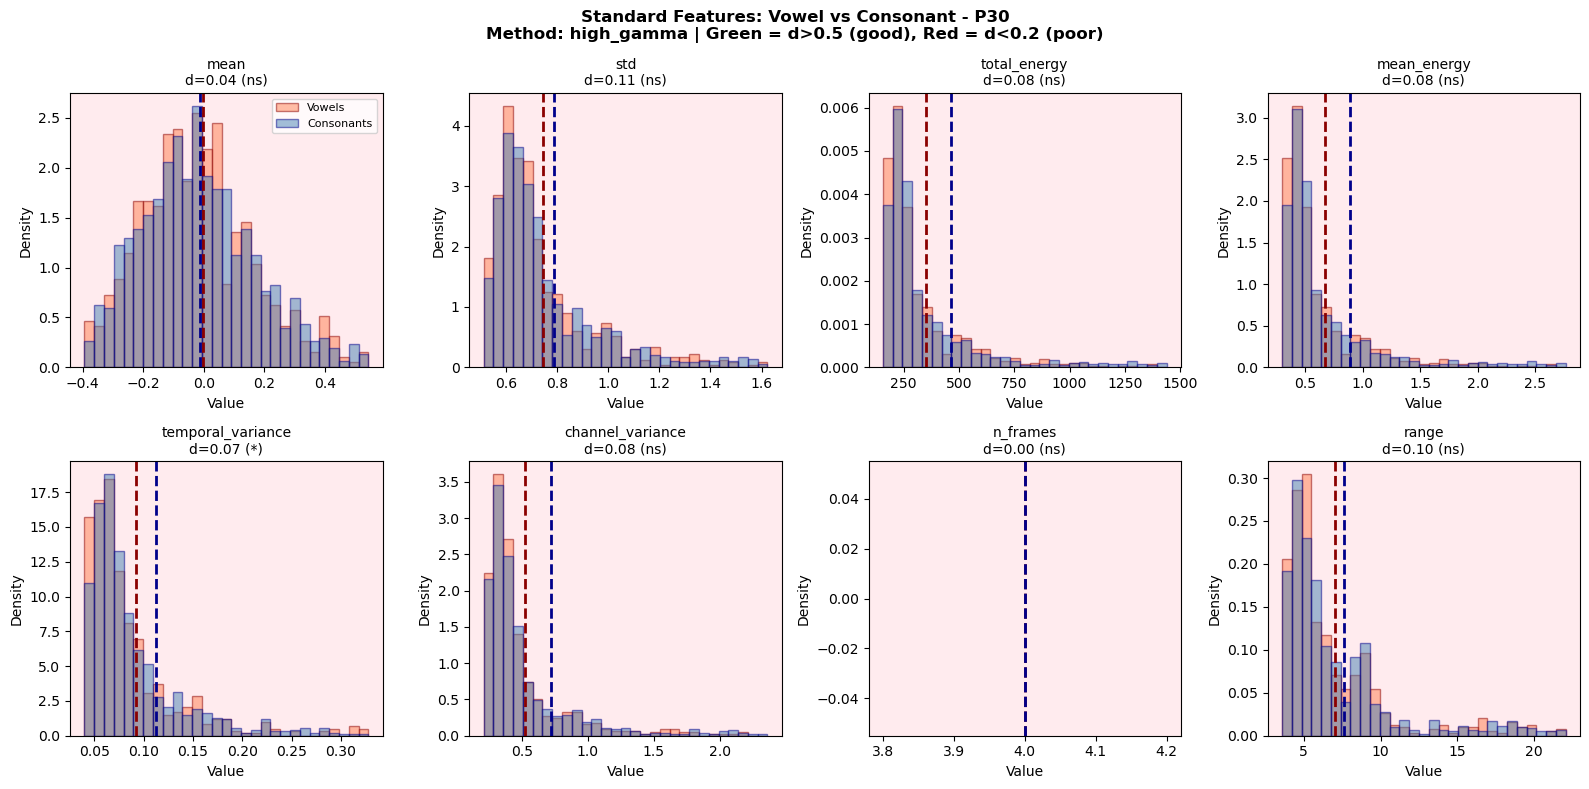

Saved: 2_transient_distributions.png


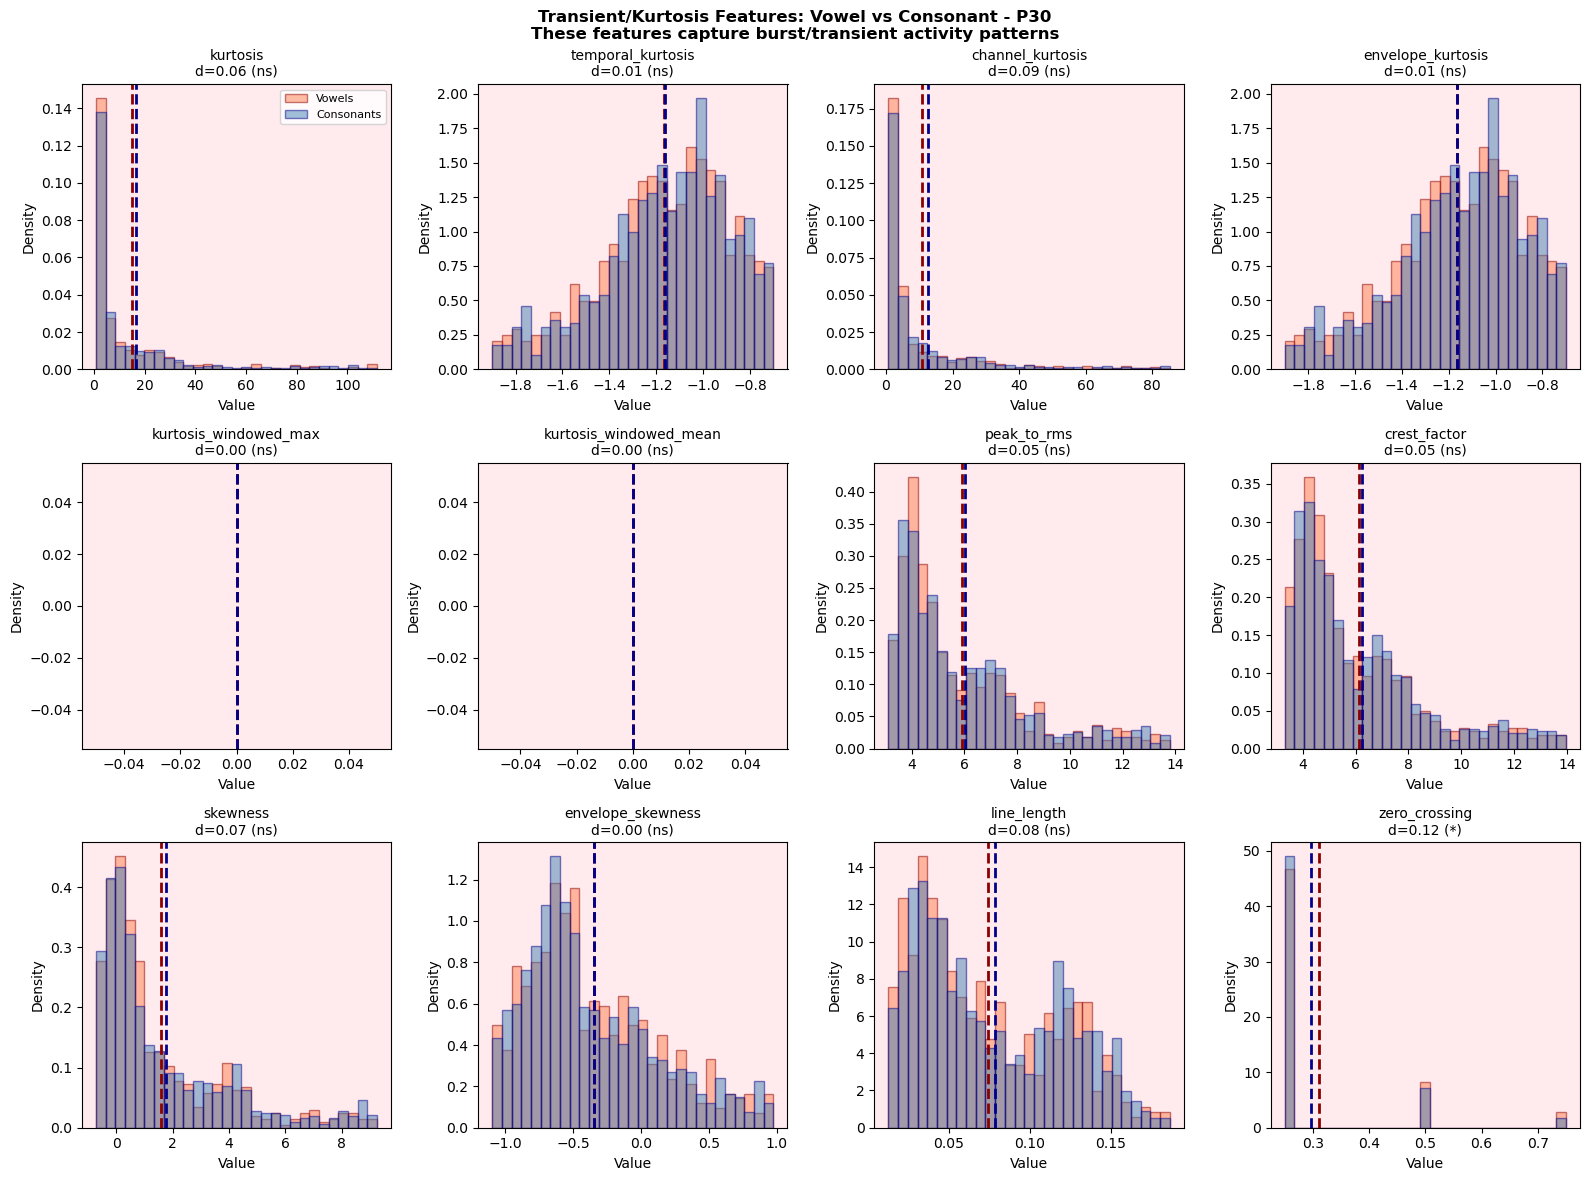

C:\Temp\ipykernel_16624\2390366310.py:589: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([std_d, trans_d], labels=['Standard', 'Transient'], patch_artist=True)


Saved: 3_separability.png


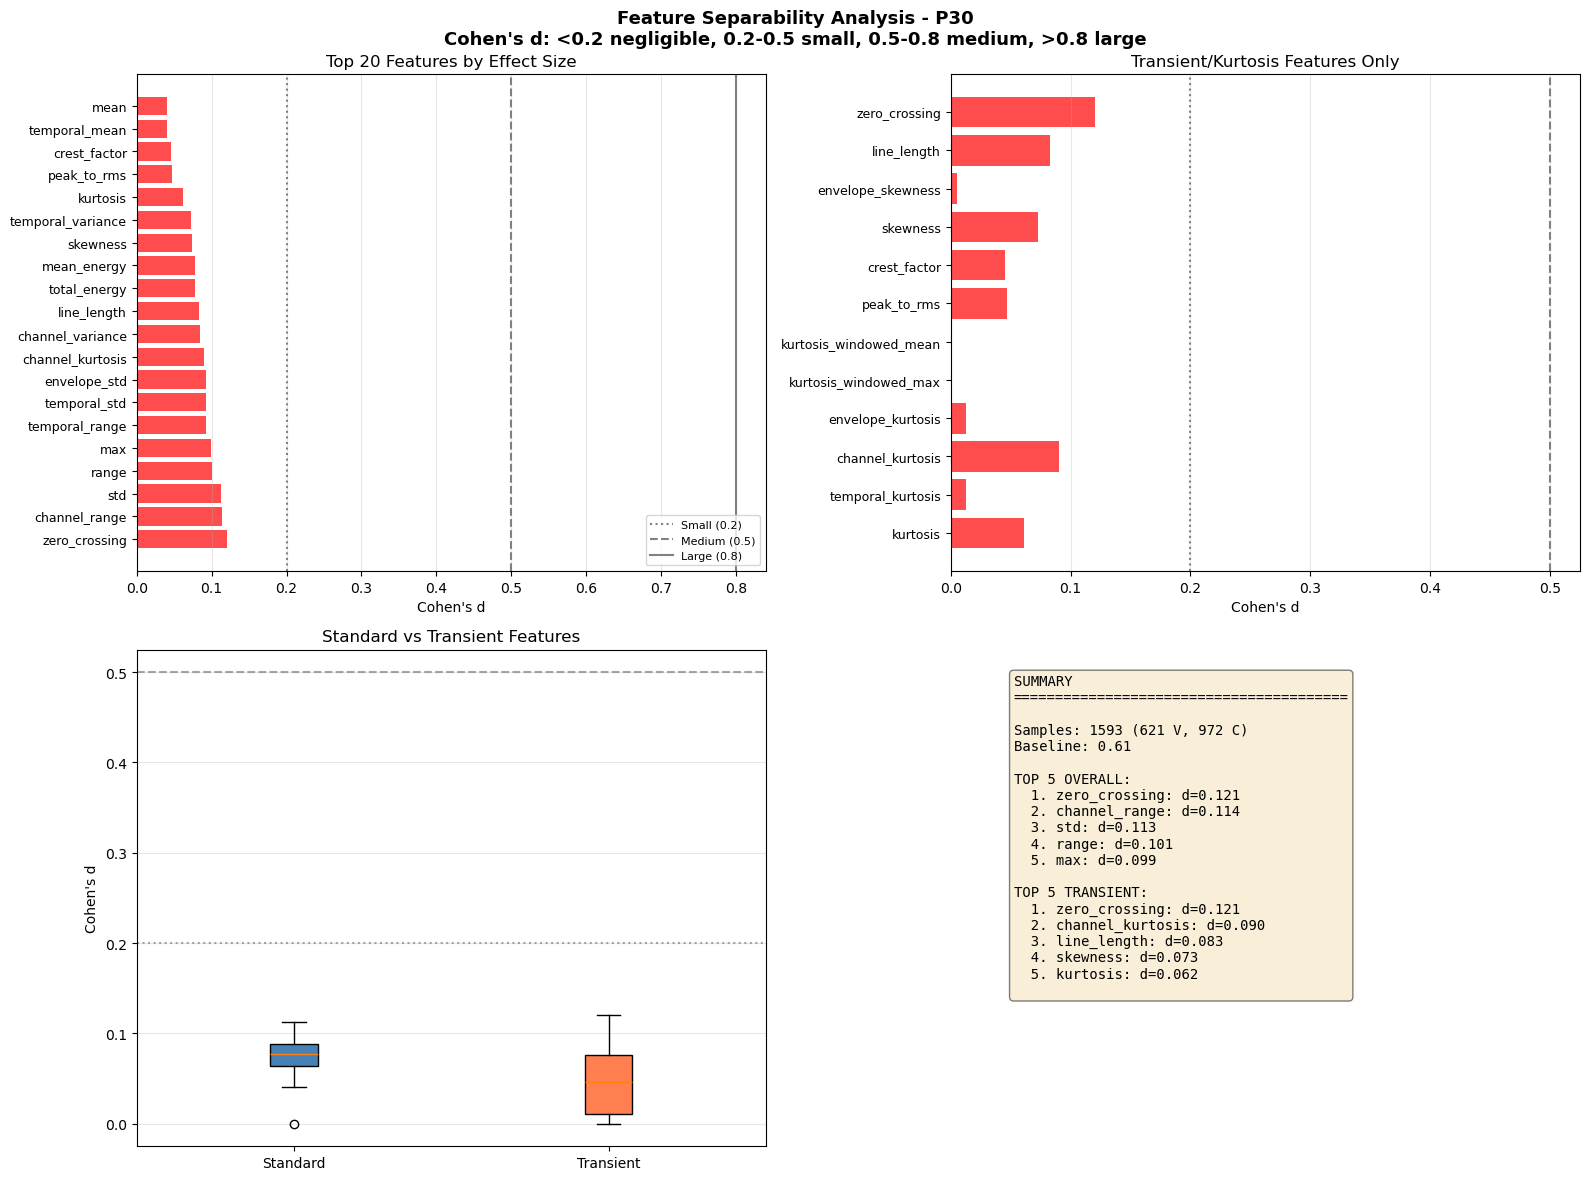

Saved: 4_phoneme_heatmap.png


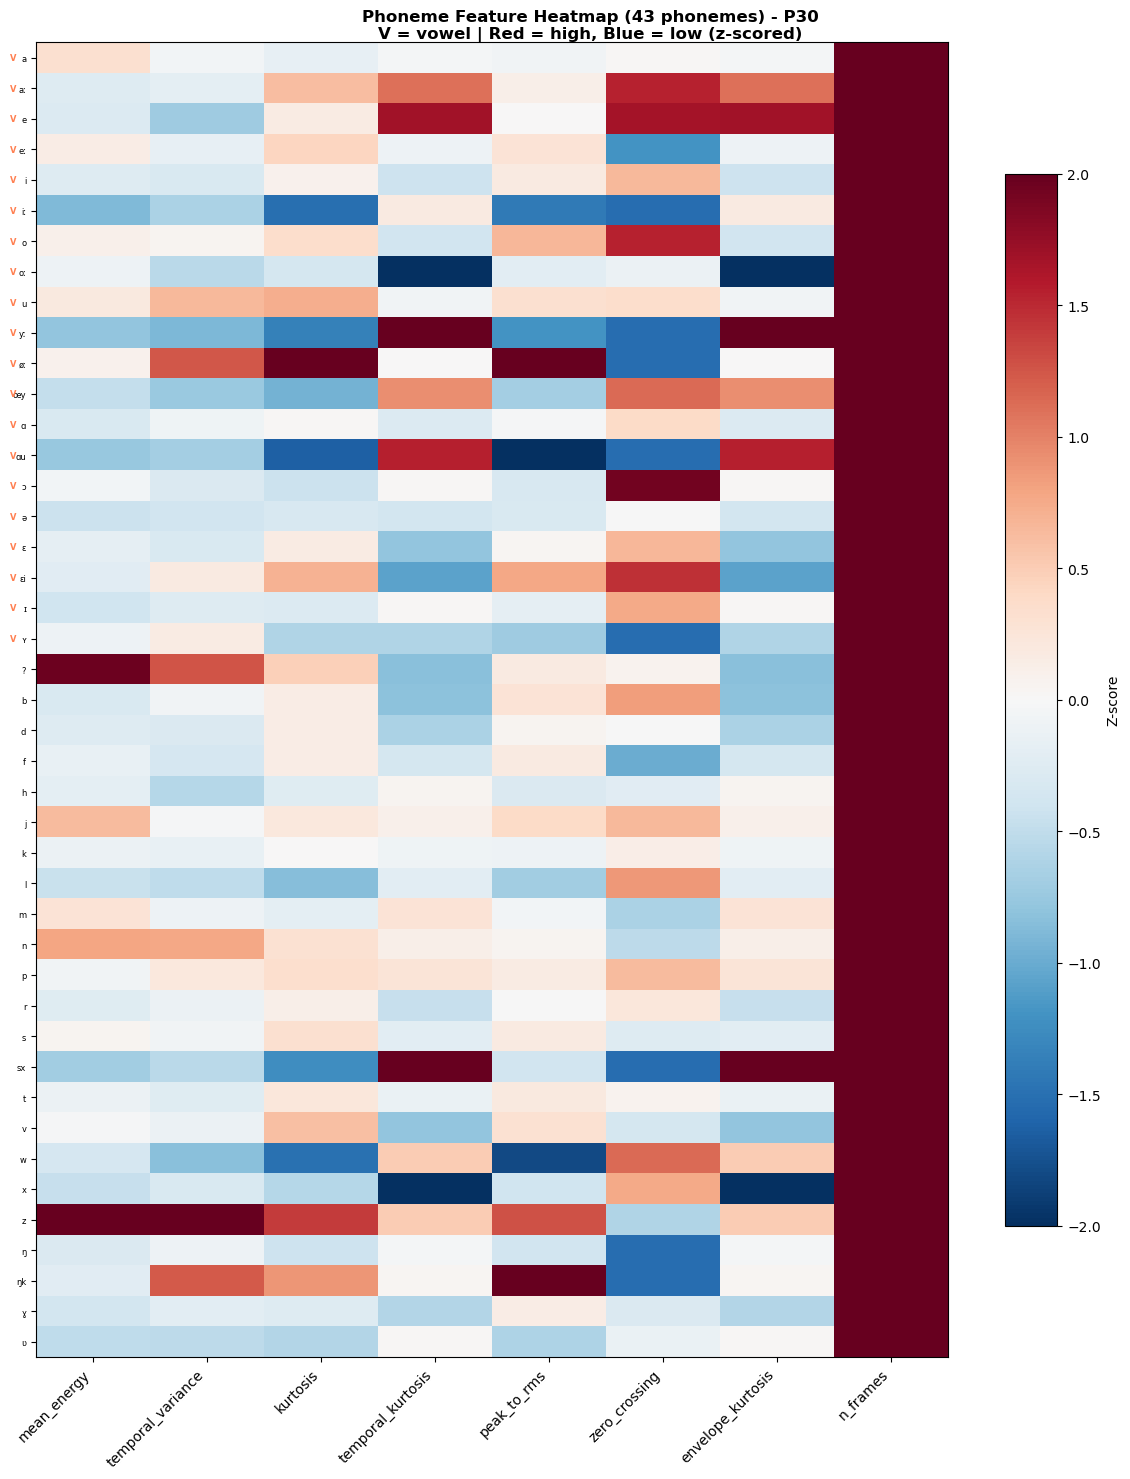


Computing learning curves...
Saved: 5_learning_curves_all.png


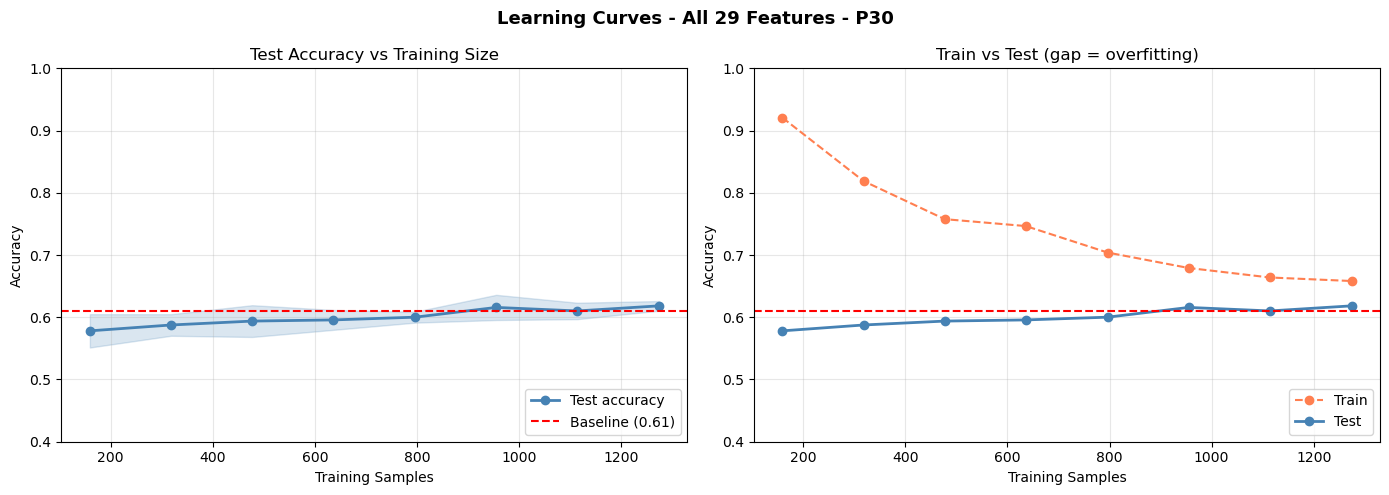


Computing feature-specific learning curves...
Saved: 6_learning_curves_features.png


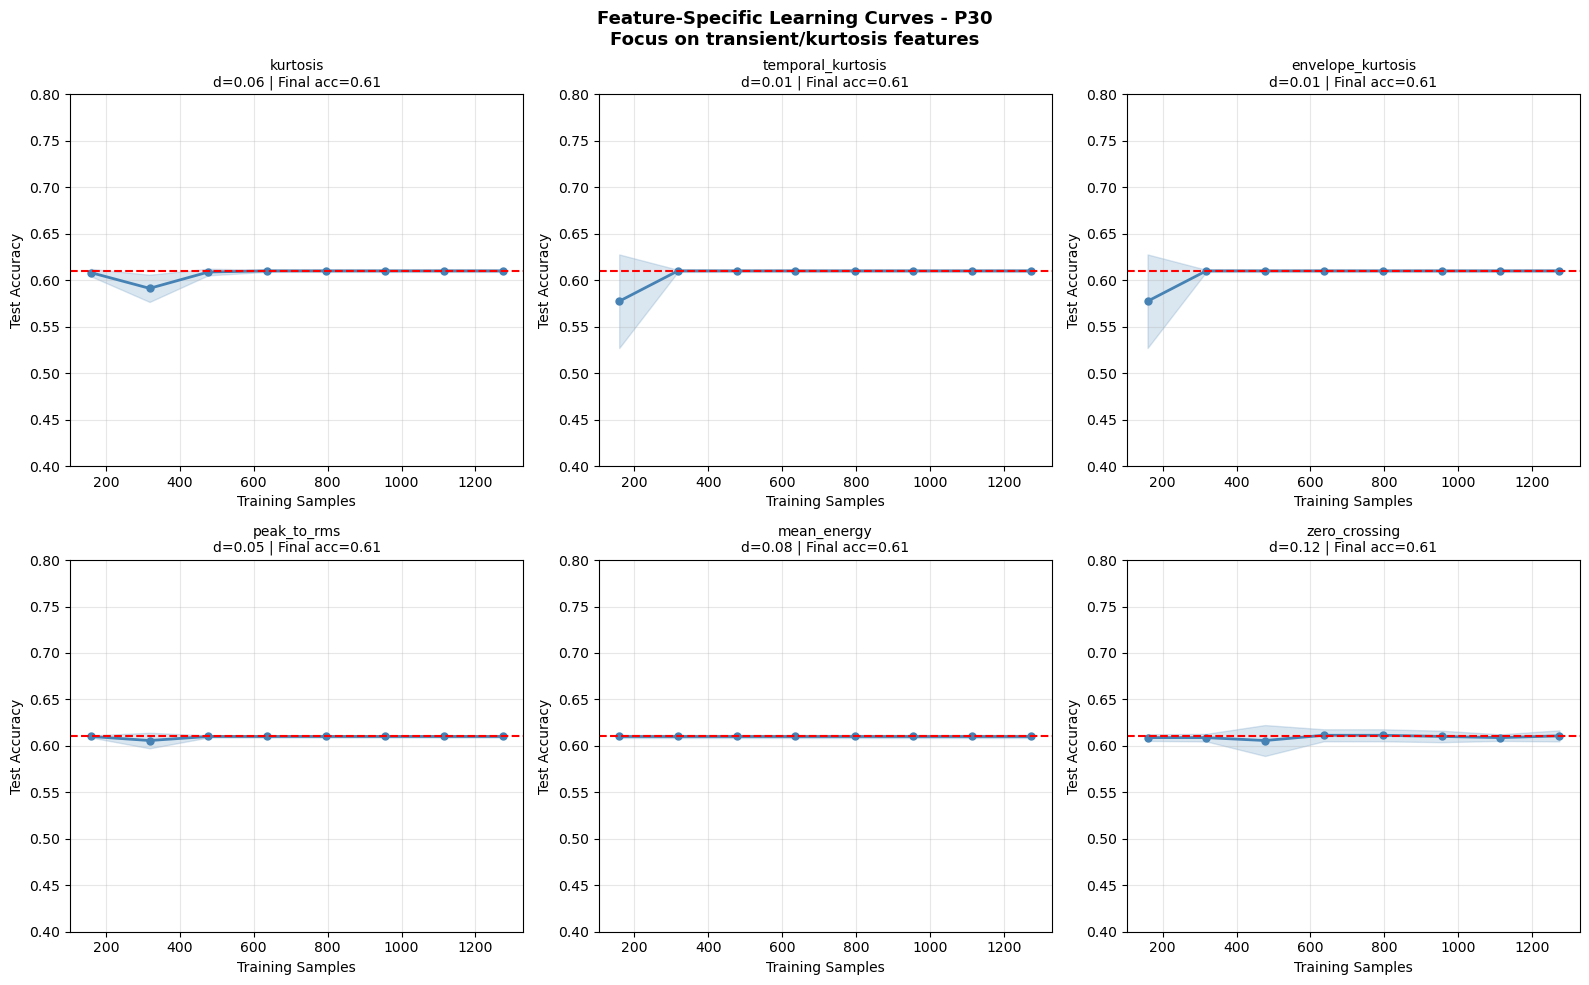


Computing feature group learning curves...
Saved: 7_learning_curves_groups.png


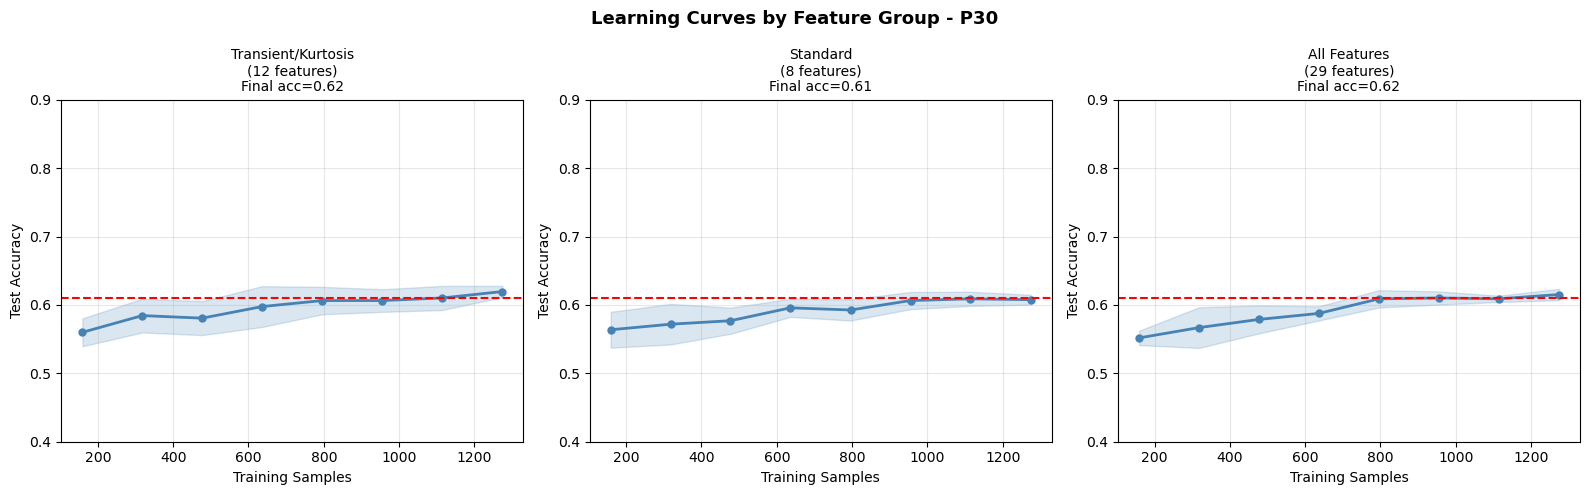


Computing dendrograms...
Saved: 8_dendrogram_overall.png


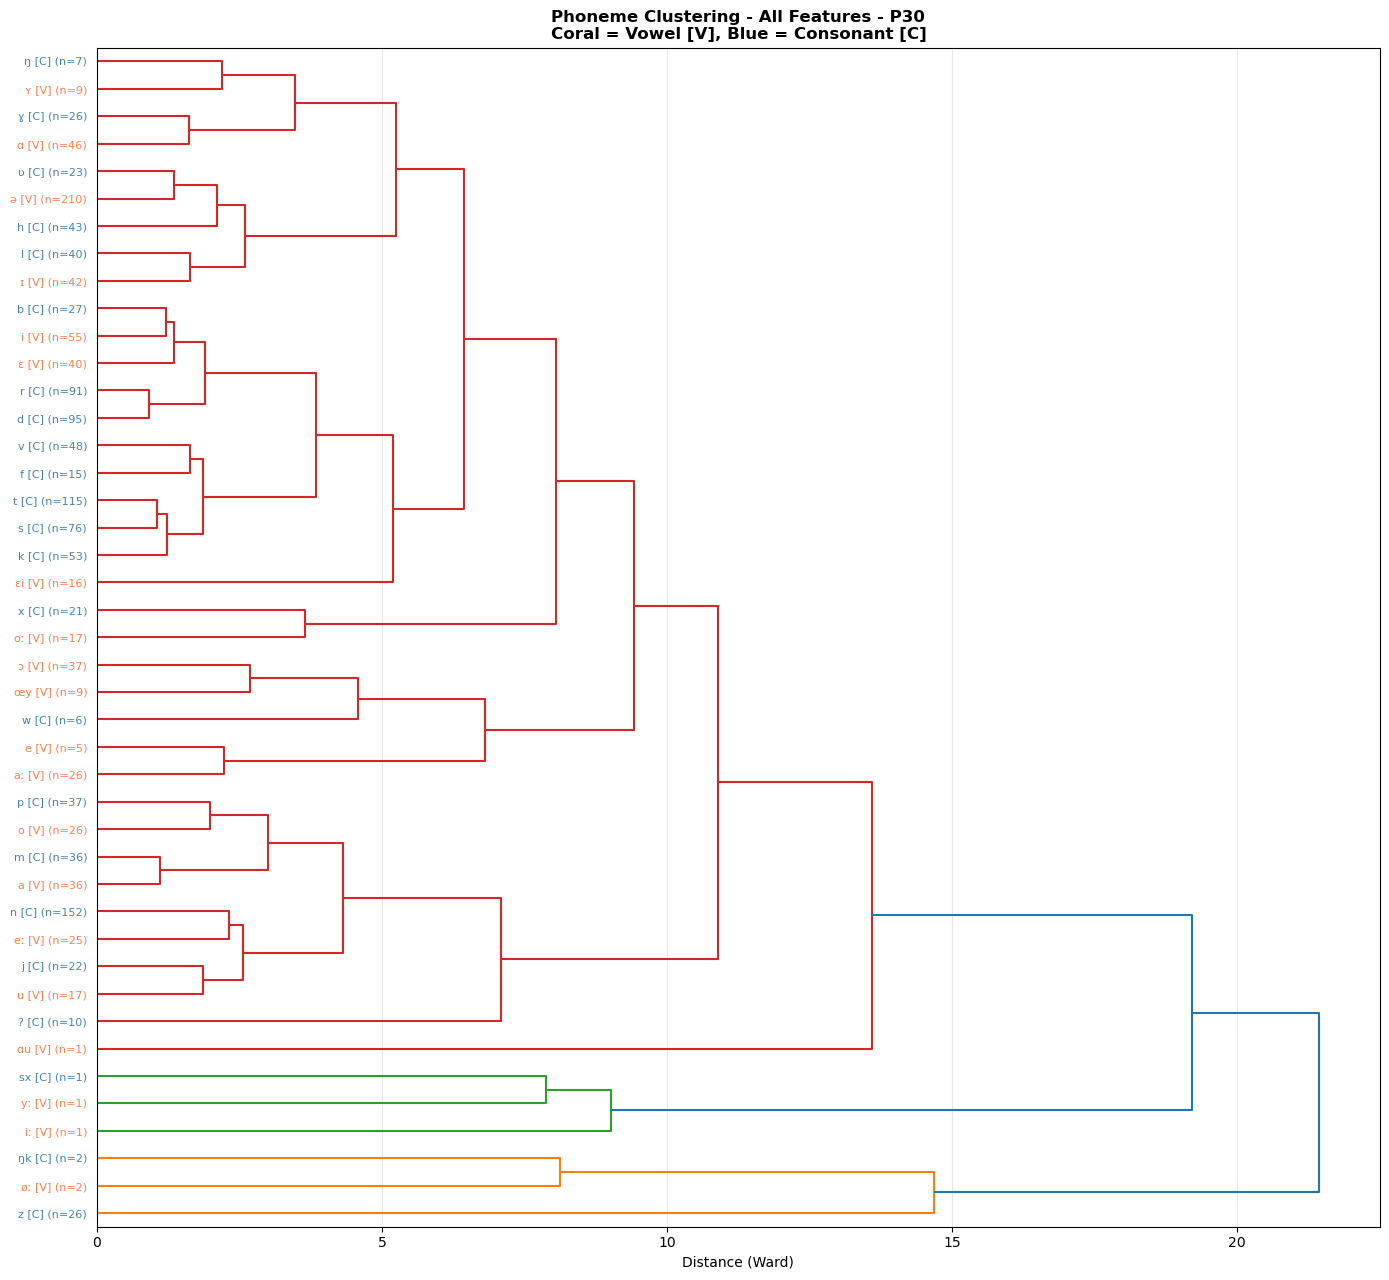

Saved: 9_dendrograms_features.png


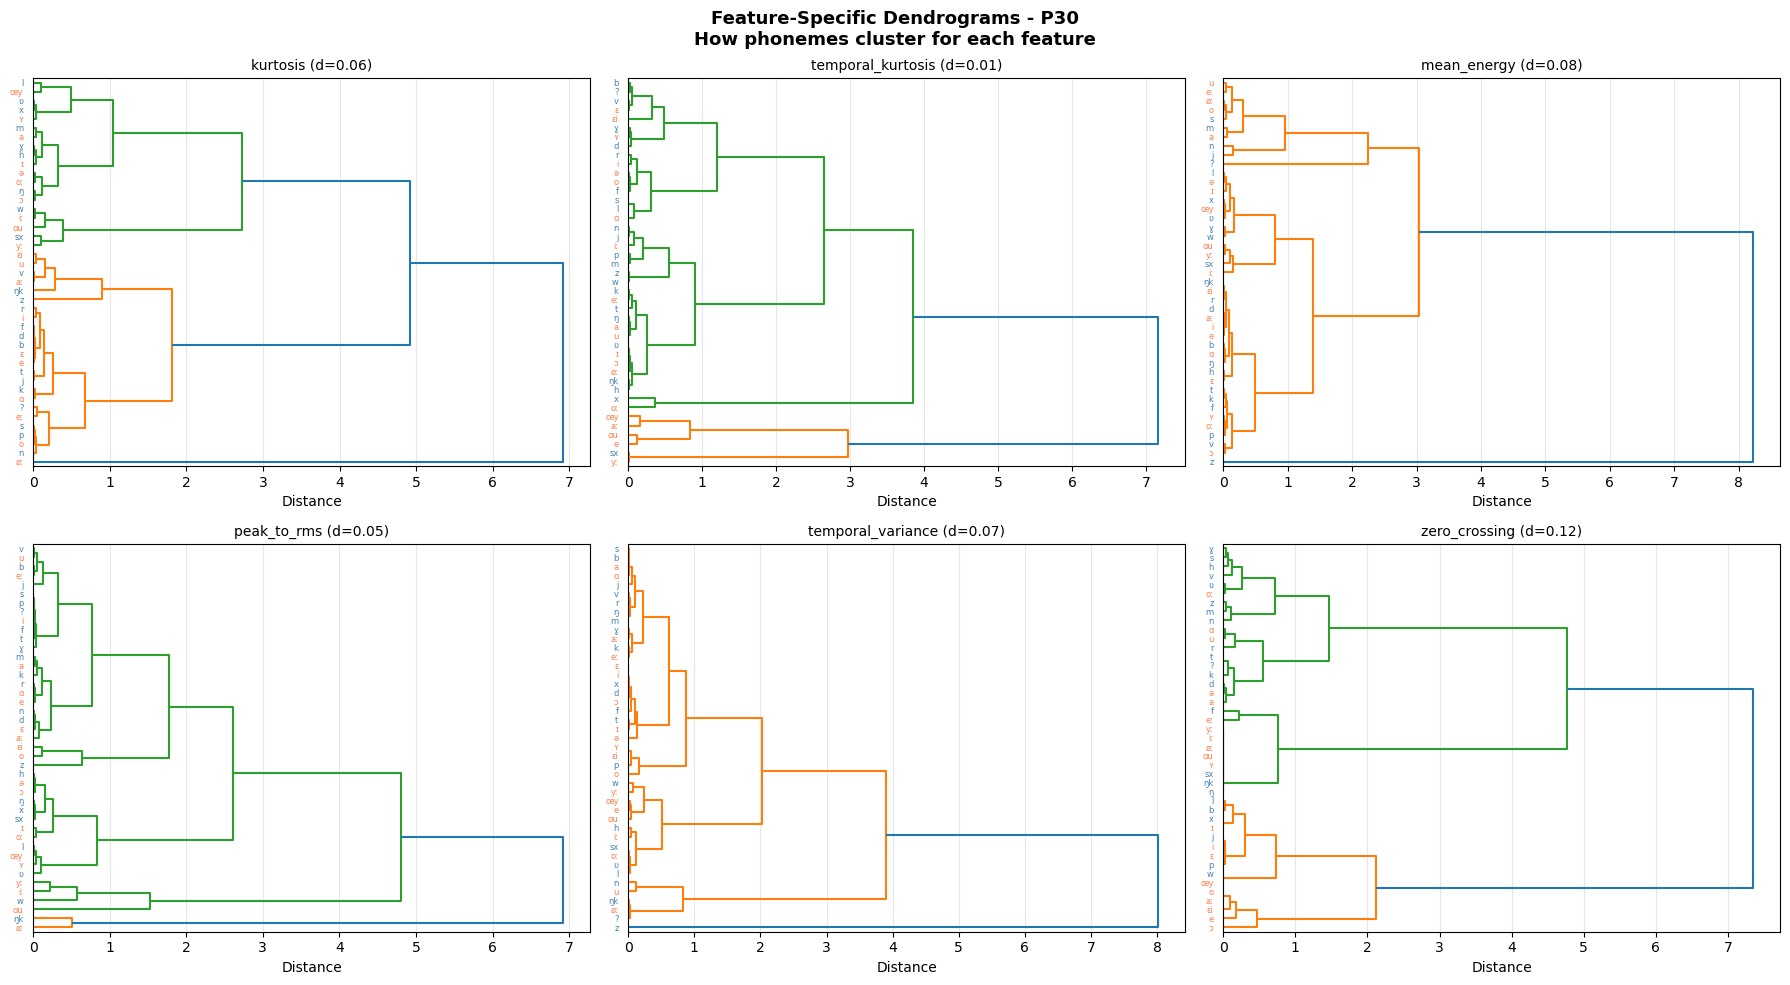

Saved: 10_cluster_quality.png


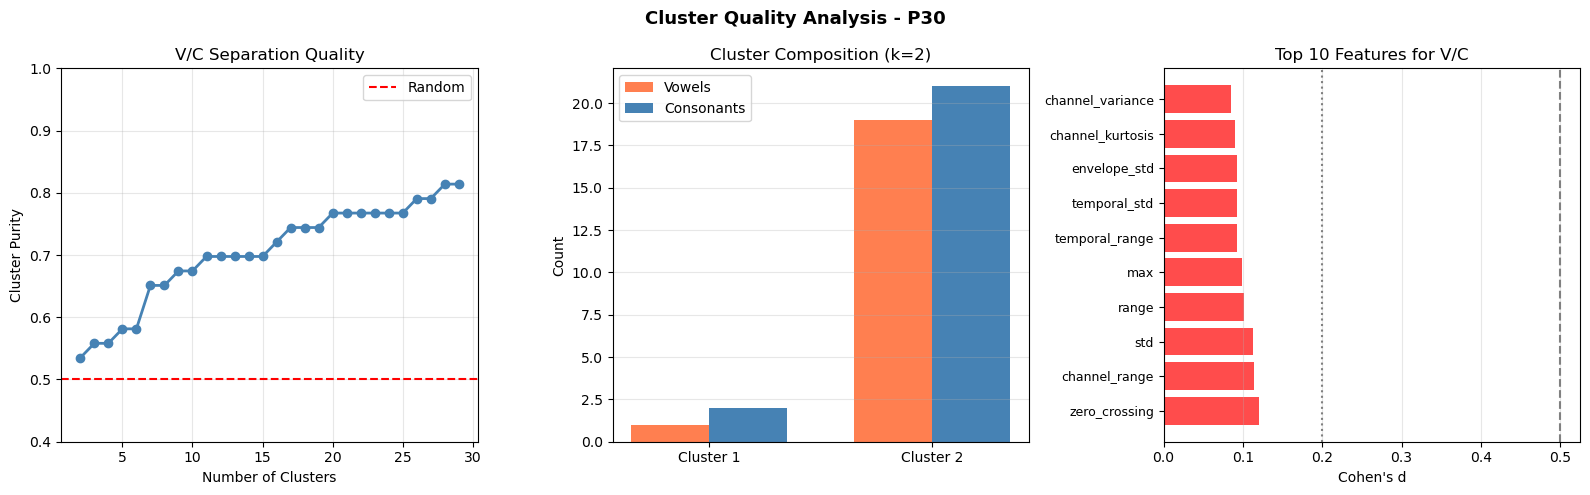


SUMMARY
Feature extraction: high_gamma
Patient: P30
Samples: 1593 (621 vowels, 972 consonants)
Phonemes: 43
Baseline: 0.61

Top 5 features overall:
  1. zero_crossing: d=0.121
  2. channel_range: d=0.114
  3. std: d=0.113
  4. range: d=0.101
  5. max: d=0.099

Top 5 transient features:
  1. zero_crossing: d=0.121
  2. channel_kurtosis: d=0.090
  3. line_length: d=0.083
  4. skewness: d=0.073
  5. kurtosis: d=0.062


In [41]:
results = visualize_pipeline_features(
    high_gamma_pipeline, 
    patient_id='P30',  # Or None for all patients
    save_path='./results/pipeline_analysis'
)

In [ ]:
def analyze_all_patients(pipeline, patient_ids=None, save_path=None):
    """
    Loop through all patients and extract key metrics from feature analysis.
    
    Args:
        pipeline: Dutch30Pipeline with train/test data already extracted
        patient_ids: List of patient IDs to analyze, or None for all
        save_path: Directory to save results
    
    Returns:
        dict: Contains DataFrames with patient summaries, feature rankings, etc.
    """
    import numpy as np
    import pandas as pd
    from scipy.stats import mannwhitneyu, kurtosis, skew
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.preprocessing import StandardScaler
    import os
    import warnings
    warnings.filterwarnings('ignore')
    
    if save_path:
        os.makedirs(save_path, exist_ok=True)
    
    # Check pipeline has data
    if not hasattr(pipeline, 'train') or pipeline.train is None:
        raise ValueError("Pipeline has no training data. Run steps 1-6 first.")
    
    train_data = pipeline.train
    
    # Get all patient IDs if not specified
    all_participant_ids = train_data['phoneme_participant_ids']
    if patient_ids is None:
        patient_ids = sorted(set(all_participant_ids))
    
    print(f"Analyzing {len(patient_ids)} patients: {patient_ids}")
    
    # Define vowels
    vowels = {
        'a', 'ɑ', 'ɛ', 'ɪ', 'i', 'ɔ', 'o', 'u', 'ʏ', 'y', 'ə', 'e', 'ø',
        'aː', 'eː', 'iː', 'oː', 'uː', 'yː', 'øː', 'ɑː', 'ɔː', 'ɛː', 'ɵː',
        'a:', 'e:', 'i:', 'o:', 'u:', 'y:', 'ø:', 'ɑ:', 'ɔ:', 'ɛ:', 'ɵ:',
        'ɛi', 'œy', 'ɑu', 'ʌu',
    }
    
    # ========================================================================
    # FEATURE EXTRACTION FUNCTION
    # ========================================================================
    
    def extract_summary_features(feat):
        """Extract summary statistics from pipeline feature matrix."""
        if feat is None or feat.size == 0:
            return None
        
        if feat.ndim == 1:
            feat = feat.reshape(1, -1)
        
        n_frames, n_features = feat.shape
        summary = {}
        
        if n_frames == 1:
            signal = feat.flatten()
        else:
            signal = feat.flatten()
        
        # Basic statistics
        summary['mean'] = np.mean(signal)
        summary['std'] = np.std(signal)
        summary['max'] = np.max(signal)
        summary['min'] = np.min(signal)
        summary['range'] = summary['max'] - summary['min']
        
        # Energy features
        summary['total_energy'] = np.sum(signal ** 2)
        summary['mean_energy'] = np.mean(signal ** 2)
        
        # Distribution features
        summary['channel_variance'] = np.var(signal)
        
        # Kurtosis and skewness
        if len(signal) > 3:
            kurt_val = kurtosis(signal, nan_policy='omit')
            summary['kurtosis'] = kurt_val if np.isfinite(kurt_val) else 0
            
            skew_val = skew(signal, nan_policy='omit')
            summary['skewness'] = skew_val if np.isfinite(skew_val) else 0
        else:
            summary['kurtosis'] = 0
            summary['skewness'] = 0
        
        # Peak features
        rms = np.sqrt(np.mean(signal ** 2))
        summary['peak_to_rms'] = np.max(np.abs(signal)) / (rms + 1e-10)
        summary['crest_factor'] = np.max(np.abs(signal)) / (np.std(signal) + 1e-10)
        
        # Line length and zero crossing
        summary['line_length'] = np.sum(np.abs(np.diff(signal))) / (len(signal) + 1e-10)
        centered = signal - np.mean(signal)
        summary['zero_crossing'] = np.sum(np.abs(np.diff(np.sign(centered))) > 0) / (len(centered) + 1e-10)
        
        return summary
    
    # ========================================================================
    # HELPER FUNCTIONS
    # ========================================================================
    
    def cohens_d(g1, g2):
        n1, n2 = len(g1), len(g2)
        if n1 < 2 or n2 < 2:
            return 0
        var1, var2 = np.var(g1, ddof=1), np.var(g2, ddof=1)
        pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
        return abs(np.mean(g1) - np.mean(g2)) / (pooled_std + 1e-10)
    
    # ========================================================================
    # ANALYZE EACH PATIENT
    # ========================================================================
    
    # Storage for results
    patient_summaries = []
    feature_rankings = []
    phoneme_counts = []
    classification_results = []
    
    for pid in patient_ids:
        print(f"\nAnalyzing {pid}...")
        
        # Filter data for this patient
        indices = [i for i, p in enumerate(all_participant_ids) if p == pid]
        
        if not indices:
            print(f"  No data for {pid}")
            continue
        
        features_list = [train_data['features'][i] for i in indices]
        labels = [train_data['phoneme_labels'][i] for i in indices]
        
        # Extract summary features
        summaries = []
        valid_indices = []
        
        for i, feat in enumerate(features_list):
            s = extract_summary_features(feat)
            if s is not None:
                summaries.append(s)
                valid_indices.append(i)
        
        if len(summaries) == 0:
            print(f"  No valid features for {pid}")
            continue
        
        # Filter labels
        labels = [labels[i] for i in valid_indices]
        
        # Get feature names and create matrix
        feature_names = list(summaries[0].keys())
        X = np.array([[s[fn] for fn in feature_names] for s in summaries])
        X = np.nan_to_num(X, nan=0, posinf=0, neginf=0)
        
        # Create binary labels
        is_vowel = [1 if label in vowels else 0 for label in labels]
        y = np.array(is_vowel)
        
        n_vowels = sum(y)
        n_consonants = len(y) - n_vowels
        n_phonemes = len(set(labels))
        baseline = max(n_vowels, n_consonants) / len(y)
        
        # ================================================================
        # COMPUTE FEATURE STATISTICS
        # ================================================================
        
        feature_stats = {}
        for i, feat_name in enumerate(feature_names):
            vowel_vals = X[y == 1, i]
            cons_vals = X[y == 0, i]
            
            if len(vowel_vals) > 1 and len(cons_vals) > 1:
                try:
                    _, pval = mannwhitneyu(vowel_vals, cons_vals, alternative='two-sided')
                except:
                    pval = 1.0
                d = cohens_d(vowel_vals, cons_vals)
                
                feature_stats[feat_name] = {
                    'cohens_d': d,
                    'pval': pval,
                    'vowel_mean': np.mean(vowel_vals),
                    'vowel_std': np.std(vowel_vals),
                    'cons_mean': np.mean(cons_vals),
                    'cons_std': np.std(cons_vals),
                }
        
        # ================================================================
        # CLASSIFICATION ACCURACY
        # ================================================================
        
        if len(y) >= 20 and n_vowels >= 5 and n_consonants >= 5:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            
            clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
            cv = StratifiedKFold(n_splits=min(5, min(n_vowels, n_consonants)), shuffle=True, random_state=42)
            
            try:
                scores = cross_val_score(clf, X_scaled, y, cv=cv, scoring='accuracy')
                cv_accuracy = np.mean(scores)
                cv_std = np.std(scores)
            except:
                cv_accuracy = np.nan
                cv_std = np.nan
        else:
            cv_accuracy = np.nan
            cv_std = np.nan
        
        # ================================================================
        # STORE PATIENT SUMMARY
        # ================================================================
        
        # Sort features by Cohen's d
        sorted_features = sorted(feature_stats.keys(), 
                                  key=lambda f: feature_stats[f]['cohens_d'], 
                                  reverse=True)
        
        top_features = sorted_features[:5]
        
        patient_summary = {
            'patient_id': pid,
            'n_samples': len(y),
            'n_vowels': n_vowels,
            'n_consonants': n_consonants,
            'n_phonemes': n_phonemes,
            'baseline': baseline,
            'cv_accuracy': cv_accuracy,
            'cv_std': cv_std,
            'lift': cv_accuracy / baseline if not np.isnan(cv_accuracy) else np.nan,
        }
        
        # Add top 5 features
        for rank, feat_name in enumerate(top_features, 1):
            patient_summary[f'top{rank}_feature'] = feat_name
            patient_summary[f'top{rank}_d'] = feature_stats[feat_name]['cohens_d']
        
        # Add specific feature values
        key_features = ['kurtosis', 'mean_energy', 'peak_to_rms', 'skewness', 'std']
        for feat_name in key_features:
            if feat_name in feature_stats:
                patient_summary[f'{feat_name}_d'] = feature_stats[feat_name]['cohens_d']
                patient_summary[f'{feat_name}_pval'] = feature_stats[feat_name]['pval']
                patient_summary[f'{feat_name}_vowel_mean'] = feature_stats[feat_name]['vowel_mean']
                patient_summary[f'{feat_name}_cons_mean'] = feature_stats[feat_name]['cons_mean']
        
        patient_summaries.append(patient_summary)
        
        # ================================================================
        # STORE FEATURE RANKINGS FOR THIS PATIENT
        # ================================================================
        
        for feat_name in feature_names:
            if feat_name in feature_stats:
                feature_rankings.append({
                    'patient_id': pid,
                    'feature': feat_name,
                    'cohens_d': feature_stats[feat_name]['cohens_d'],
                    'pval': feature_stats[feat_name]['pval'],
                    'vowel_mean': feature_stats[feat_name]['vowel_mean'],
                    'cons_mean': feature_stats[feat_name]['cons_mean'],
                })
        
        # ================================================================
        # STORE PHONEME COUNTS
        # ================================================================
        
        for label in set(labels):
            count = labels.count(label)
            phoneme_counts.append({
                'patient_id': pid,
                'phoneme': label,
                'count': count,
                'is_vowel': label in vowels,
            })
        
        print(f"  Samples: {len(y)} ({n_vowels}V, {n_consonants}C)")
        print(f"  Baseline: {baseline:.2f}, CV Accuracy: {cv_accuracy:.2f}" if not np.isnan(cv_accuracy) else f"  Baseline: {baseline:.2f}, CV Accuracy: N/A")
        print(f"  Top feature: {top_features[0]} (d={feature_stats[top_features[0]]['cohens_d']:.3f})")
    
    # ========================================================================
    # CREATE DATAFRAMES
    # ========================================================================
    
    df_patients = pd.DataFrame(patient_summaries)
    df_features = pd.DataFrame(feature_rankings)
    df_phonemes = pd.DataFrame(phoneme_counts)
    
    # ========================================================================
    # CREATE AGGREGATE SUMMARIES
    # ========================================================================
    
    # Best features across all patients
    if len(df_features) > 0:
        df_feature_summary = df_features.groupby('feature').agg({
            'cohens_d': ['mean', 'std', 'min', 'max'],
            'pval': 'mean',
        }).round(4)
        df_feature_summary.columns = ['d_mean', 'd_std', 'd_min', 'd_max', 'pval_mean']
        df_feature_summary = df_feature_summary.sort_values('d_mean', ascending=False)
    else:
        df_feature_summary = pd.DataFrame()
    
    # ========================================================================
    # PRINT SUMMARY TABLES
    # ========================================================================
    
    print("\n" + "=" * 80)
    print("PATIENT SUMMARY")
    print("=" * 80)
    
    display_cols = ['patient_id', 'n_samples', 'n_vowels', 'n_consonants', 
                    'baseline', 'cv_accuracy', 'lift', 'top1_feature', 'top1_d']
    display_cols = [c for c in display_cols if c in df_patients.columns]
    print(df_patients[display_cols].to_string(index=False))
    
    print("\n" + "=" * 80)
    print("FEATURE RANKING (ACROSS ALL PATIENTS)")
    print("=" * 80)
    print(df_feature_summary.head(15).to_string())
    
    print("\n" + "=" * 80)
    print("OVERALL STATISTICS")
    print("=" * 80)
    print(f"Total patients analyzed: {len(df_patients)}")
    print(f"Mean CV accuracy: {df_patients['cv_accuracy'].mean():.3f} (+/- {df_patients['cv_accuracy'].std():.3f})")
    print(f"Mean baseline: {df_patients['baseline'].mean():.3f}")
    print(f"Mean lift: {df_patients['lift'].mean():.3f}")
    print(f"Best patient: {df_patients.loc[df_patients['cv_accuracy'].idxmax(), 'patient_id']} ({df_patients['cv_accuracy'].max():.3f})")
    print(f"Worst patient: {df_patients.loc[df_patients['cv_accuracy'].idxmin(), 'patient_id']} ({df_patients['cv_accuracy'].min():.3f})")
    
    # ========================================================================
    # SAVE TO FILES
    # ========================================================================
    
    if save_path:
        df_patients.to_csv(os.path.join(save_path, 'patient_summary.csv'), index=False)
        df_features.to_csv(os.path.join(save_path, 'feature_rankings.csv'), index=False)
        df_feature_summary.to_csv(os.path.join(save_path, 'feature_summary.csv'))
        df_phonemes.to_csv(os.path.join(save_path, 'phoneme_counts.csv'), index=False)
        
        print(f"\nSaved to {save_path}:")
        print("  - patient_summary.csv")
        print("  - feature_rankings.csv")
        print("  - feature_summary.csv")
        print("  - phoneme_counts.csv")
    
    return {
        'patients': df_patients,
        'features': df_features,
        'feature_summary': df_feature_summary,
        'phonemes': df_phonemes,
    }

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict, Counter

# Define speech-related brain regions
SPEECH_REGIONS = {
    # Primary speech areas
    'superior_temporal': ['ctx_lh_S_temporal_sup', 'ctx_rh_S_temporal_sup', 
                          'ctx_lh_G_temporal_sup', 'ctx_rh_G_temporal_sup',
                          'ctx_lh_G_temp_sup-Lateral', 'ctx_rh_G_temp_sup-Lateral',
                          'ctx_lh_G_temp_sup-Plan_tempo', 'ctx_rh_G_temp_sup-Plan_tempo'],
    'middle_temporal': ['ctx_lh_G_temporal_middle', 'ctx_rh_G_temporal_middle',
                        'ctx_lh_S_temporal_inf', 'ctx_rh_S_temporal_inf'],
    'inferior_frontal': ['ctx_lh_G_front_inf-Opercular', 'ctx_rh_G_front_inf-Opercular',
                         'ctx_lh_G_front_inf-Triangul', 'ctx_rh_G_front_inf-Triangul',
                         'ctx_lh_S_front_inf', 'ctx_rh_S_front_inf'],
    'precentral': ['ctx_lh_G_precentral', 'ctx_rh_G_precentral',
                   'ctx_lh_S_precentral-inf-part', 'ctx_rh_S_precentral-inf-part',
                   'ctx_lh_S_precentral-sup-part', 'ctx_rh_S_precentral-sup-part'],
    'postcentral': ['ctx_lh_G_postcentral', 'ctx_rh_G_postcentral',
                    'ctx_lh_S_postcentral', 'ctx_rh_S_postcentral'],
    'insula': ['ctx_lh_G_Ins_lg_and_S_cent_ins', 'ctx_rh_G_Ins_lg_and_S_cent_ins',
               'ctx_lh_G_insular_short', 'ctx_rh_G_insular_short',
               'ctx_lh_S_circular_insula_inf', 'ctx_rh_S_circular_insula_inf',
               'ctx_lh_S_circular_insula_sup', 'ctx_rh_S_circular_insula_sup'],
    'supramarginal': ['ctx_lh_G_pariet_inf-Supramar', 'ctx_rh_G_pariet_inf-Supramar'],
}

# Flatten for easy lookup
SPEECH_REGION_LOOKUP = {}
for category, regions in SPEECH_REGIONS.items():
    for region in regions:
        SPEECH_REGION_LOOKUP[region] = category


def analyze_electrode_coverage(data_dir, patient_ids):
    """Analyze electrode coverage of speech regions for each patient."""
    
    results = []
    
    for pid in patient_ids:
        loc_file = os.path.join(data_dir, f'{pid}_electrode_locations.csv')
        
        if not os.path.exists(loc_file):
            print(f"Warning: No electrode file for {pid}")
            continue
        
        df = pd.read_csv(loc_file)
        
        # Count electrodes by region type
        total_electrodes = len(df)
        locations = df['location'].tolist()
        
        # Count speech-related electrodes
        speech_electrodes = defaultdict(int)
        non_speech_count = 0
        white_matter_count = 0
        unknown_count = 0
        
        for loc in locations:
            if 'White-Matter' in str(loc):
                white_matter_count += 1
            elif loc == 'Unknown' or pd.isna(loc):
                unknown_count += 1
            elif loc in SPEECH_REGION_LOOKUP:
                speech_electrodes[SPEECH_REGION_LOOKUP[loc]] += 1
            else:
                non_speech_count += 1
        
        total_speech = sum(speech_electrodes.values())
        
        results.append({
            'patient_id': pid,
            'total_electrodes': total_electrodes,
            'speech_electrodes': total_speech,
            'speech_ratio': total_speech / total_electrodes if total_electrodes > 0 else 0,
            'white_matter': white_matter_count,
            'unknown': unknown_count,
            'non_speech_cortex': non_speech_count,
            **{f'speech_{k}': v for k, v in speech_electrodes.items()}
        })
    
    return pd.DataFrame(results)


def correlate_with_feature_quality(electrode_df, feature_rankings_df):
    """Correlate electrode coverage with feature quality."""
    
    # Merge dataframes
    merged = electrode_df.merge(
        feature_rankings_df.groupby('patient_id').agg({
            'd_mean': 'mean',
            'd_max': 'max'
        }).reset_index(),
        on='patient_id',
        how='left'
    )
    
    return merged


# Run analysis
data_dir = pipeline.dutch30_extractor.data_dir
patient_ids = list(set(pipeline.train['phoneme_participant_ids']))

print("Analyzing electrode coverage...")
electrode_df = analyze_electrode_coverage(data_dir, patient_ids)

# Add promising/weak classification
promising_ids = ['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15',
                 'P16', 'P17', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
electrode_df['group'] = electrode_df['patient_id'].apply(
    lambda x: 'Promising' if x in promising_ids else 'Weak'
)

print("\n" + "="*80)
print("ELECTRODE COVERAGE BY PATIENT")
print("="*80)
print(electrode_df[['patient_id', 'group', 'total_electrodes', 'speech_electrodes', 
                    'speech_ratio', 'white_matter', 'unknown']].to_string(index=False))

# Compare groups
print("\n" + "="*80)
print("COMPARISON: PROMISING vs WEAK PATIENTS")
print("="*80)

comparison = electrode_df.groupby('group').agg({
    'total_electrodes': ['mean', 'std'],
    'speech_electrodes': ['mean', 'std'],
    'speech_ratio': ['mean', 'std'],
    'white_matter': ['mean', 'std'],
    'unknown': ['mean', 'std']
}).round(2)

print(comparison)

# Speech region breakdown
print("\n" + "="*80)
print("SPEECH REGION BREAKDOWN BY GROUP")
print("="*80)

speech_cols = [col for col in electrode_df.columns if col.startswith('speech_') and col != 'speech_electrodes' and col != 'speech_ratio']
if speech_cols:
    for col in speech_cols:
        electrode_df[col] = electrode_df[col].fillna(0)
    
    speech_breakdown = electrode_df.groupby('group')[speech_cols].mean().round(2)
    print(speech_breakdown.T)

# Statistical test
print("\n" + "="*80)
print("STATISTICAL COMPARISON")
print("="*80)

from scipy import stats

promising_speech = electrode_df[electrode_df['group'] == 'Promising']['speech_ratio']
weak_speech = electrode_df[electrode_df['group'] == 'Weak']['speech_ratio']

t_stat, p_val = stats.ttest_ind(promising_speech, weak_speech)
print(f"Speech ratio - Promising: {promising_speech.mean():.3f} vs Weak: {weak_speech.mean():.3f}")
print(f"T-test: t={t_stat:.2f}, p={p_val:.3f}")

promising_total = electrode_df[electrode_df['group'] == 'Promising']['total_electrodes']
weak_total = electrode_df[electrode_df['group'] == 'Weak']['total_electrodes']

t_stat2, p_val2 = stats.ttest_ind(promising_total, weak_total)
print(f"\nTotal electrodes - Promising: {promising_total.mean():.1f} vs Weak: {weak_total.mean():.1f}")
print(f"T-test: t={t_stat2:.2f}, p={p_val2:.3f}")

In [ ]:
# Find patients with d > 0.3 for any feature
good_patients = df_features[df_features['cohens_d'] > 0.3]['patient_id'].unique()
print(f"Patients with promising features: {good_patients}")

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def analyze_patient_optimal_features(pipeline, patient_id, data_dir, n_bands=6):
    """Find optimal feature setup and identify top features for a patient."""
    
    vowels = {'a', 'e', 'i', 'o', 'u', 'ə', 'ɛ', 'ɪ', 'ɔ', 'ʏ', 'ɑ', 
              'aː', 'eː', 'iː', 'oː', 'uː', 'ɛi', 'œy', 'ɑu', 'yː', 'øː'}
    
    # Get patient data
    indices = [i for i, p in enumerate(pipeline.train['phoneme_participant_ids']) 
               if p == patient_id]
    
    if len(indices) < 20:
        return None
    
    # Prepare features
    X = []
    for i in indices:
        feat = pipeline.train['features'][i]
        if feat.ndim > 1:
            feat = feat.mean(axis=0)
        X.append(feat.flatten())
    
    lengths = [len(x) for x in X]
    if len(set(lengths)) > 1:
        max_len = max(lengths)
        X = [np.pad(x, (0, max_len - len(x)), mode='constant') for x in X]
    
    X = np.array(X)
    labels = [pipeline.train['phoneme_labels'][i] for i in indices]
    y = np.array([1 if l in vowels else 0 for l in labels])
    
    if len(np.unique(y)) < 2:
        return None
    
    # Calculate effect sizes
    vowel_X = X[y == 1]
    consonant_X = X[y == 0]
    
    effect_sizes = []
    for i in range(X.shape[1]):
        v = vowel_X[:, i]
        c = consonant_X[:, i]
        pooled_std = np.sqrt((np.var(v) + np.var(c)) / 2)
        d = (np.mean(v) - np.mean(c)) / (pooled_std + 1e-10)
        effect_sizes.append(d)
    
    effect_sizes = np.array(effect_sizes)
    abs_effect_sizes = np.abs(effect_sizes)
    
    # Test different feature counts
    clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    baseline = max(np.mean(y), 1 - np.mean(y))
    
    feature_counts = [1, 3, 5, 10, 15, 20, 30, 50]
    feature_counts = [n for n in feature_counts if n <= X.shape[1]]
    
    results = {'patient_id': patient_id, 'n_samples': len(X), 'baseline': baseline}
    best_lift = 0
    best_n = 0
    
    for n in feature_counts:
        top_n = np.argsort(abs_effect_sizes)[-n:]
        X_top = X[:, top_n]
        scores = cross_val_score(clf, X_top, y, cv=5)
        lift = np.mean(scores) / baseline
        
        results[f'top{n}_acc'] = np.mean(scores)
        results[f'top{n}_lift'] = lift
        
        if lift > best_lift:
            best_lift = lift
            best_n = n
    
    # All features
    scores = cross_val_score(clf, X, y, cv=5)
    results['all_acc'] = np.mean(scores)
    results['all_lift'] = np.mean(scores) / baseline
    
    results['best_n_features'] = best_n
    results['best_lift'] = best_lift
    
    # Get top 10 feature details
    top10_idx = np.argsort(abs_effect_sizes)[-10:][::-1]
    
    # Load electrode locations
    loc_file = os.path.join(data_dir, f'{patient_id}_electrode_locations.csv')
    if os.path.exists(loc_file):
        df_elec = pd.read_csv(loc_file)
    else:
        df_elec = None
    
    top_features = []
    for rank, idx in enumerate(top10_idx, 1):
        ch = idx // n_bands
        band = idx % n_bands
        d = effect_sizes[idx]
        
        if df_elec is not None and ch < len(df_elec):
            name = df_elec.iloc[ch]['electrode_name_1']
            loc = df_elec.iloc[ch]['location']
        else:
            name = f"CH{ch}"
            loc = "Unknown"
        
        top_features.append({
            'patient_id': patient_id,
            'rank': rank,
            'feature_idx': idx,
            'channel': ch,
            'band': band,
            'effect_size': d,
            'abs_effect_size': abs(d),
            'electrode': name,
            'location': loc
        })
    
    return {
        'summary': results,
        'top_features': pd.DataFrame(top_features),
        'all_effect_sizes': effect_sizes
    }


def analyze_all_chosen_patients(pipeline, patient_ids, data_dir):
    """Analyze all chosen patients and compare results."""
    
    all_summaries = []
    all_top_features = []
    
    print("="*80)
    print("ANALYZING OPTIMAL FEATURE SETUP FOR EACH PATIENT")
    print("="*80)
    
    for pid in patient_ids:
        print(f"\nProcessing {pid}...")
        result = analyze_patient_optimal_features(pipeline, pid, data_dir)
        
        if result is None:
            print(f"  Skipped (insufficient data)")
            continue
        
        all_summaries.append(result['summary'])
        all_top_features.append(result['top_features'])
        
        # Print summary for this patient
        s = result['summary']
        print(f"  Samples: {s['n_samples']}, Baseline: {s['baseline']:.3f}")
        print(f"  Best setup: top {s['best_n_features']} features -> {s['best_lift']:.2f}x lift")
        print(f"  All features: {s['all_lift']:.2f}x lift")
    
    df_summary = pd.DataFrame(all_summaries)
    df_all_features = pd.concat(all_top_features, ignore_index=True)
    
    # Print comparison table
    print("\n" + "="*80)
    print("SUMMARY: OPTIMAL FEATURE COUNT PER PATIENT")
    print("="*80)
    
    cols_to_show = ['patient_id', 'n_samples', 'baseline', 'best_n_features', 'best_lift', 'all_lift']
    print(df_summary[cols_to_show].to_string(index=False))
    
    # Print lift by feature count
    print("\n" + "="*80)
    print("LIFT BY FEATURE COUNT")
    print("="*80)
    
    lift_cols = [c for c in df_summary.columns if c.endswith('_lift') and c != 'best_lift']
    lift_cols = ['patient_id'] + sorted(lift_cols, key=lambda x: int(x.replace('top', '').replace('_lift', '').replace('all', '999')))
    
    print(df_summary[lift_cols].round(2).to_string(index=False))
    
    # Analyze common top features across patients
    print("\n" + "="*80)
    print("TOP FEATURES BY PATIENT")
    print("="*80)
    
    for pid in patient_ids:
        patient_features = df_all_features[df_all_features['patient_id'] == pid]
        if len(patient_features) == 0:
            continue
        
        print(f"\n{pid}:")
        print(f"  {'Rank':<6} {'Ch':<6} {'Band':<6} {'d':<8} {'Electrode':<10} {'Location'}")
        print("  " + "-" * 70)
        
        for _, row in patient_features.head(5).iterrows():
            print(f"  {row['rank']:<6} {row['channel']:<6} {row['band']:<6} {row['effect_size']:<8.3f} {row['electrode']:<10} {row['location']}")
    
    # Analyze common brain regions
    print("\n" + "="*80)
    print("BRAIN REGIONS IN TOP 10 FEATURES (ACROSS ALL PATIENTS)")
    print("="*80)
    
    location_counts = df_all_features['location'].value_counts()
    print(f"\n{'Location':<45} {'Count':<8} {'Avg |d|'}")
    print("-" * 70)
    
    for loc in location_counts.head(15).index:
        count = location_counts[loc]
        avg_d = df_all_features[df_all_features['location'] == loc]['abs_effect_size'].mean()
        print(f"{loc:<45} {count:<8} {avg_d:.3f}")
    
    # Analyze frequency bands
    print("\n" + "="*80)
    print("FREQUENCY BANDS IN TOP 10 FEATURES (ACROSS ALL PATIENTS)")
    print("="*80)
    
    band_counts = df_all_features['band'].value_counts().sort_index()
    print(f"\n{'Band':<8} {'Count':<8} {'Avg |d|'}")
    print("-" * 30)
    
    for band in range(6):
        if band in band_counts.index:
            count = band_counts[band]
            avg_d = df_all_features[df_all_features['band'] == band]['abs_effect_size'].mean()
            print(f"{band:<8} {count:<8} {avg_d:.3f}")
    
    # Find if any channels appear for multiple patients
    print("\n" + "="*80)
    print("COMMON ELECTRODE LOCATIONS ACROSS PATIENTS")
    print("="*80)
    
    location_by_patient = df_all_features.groupby('location')['patient_id'].nunique()
    common_locations = location_by_patient[location_by_patient > 1].sort_values(ascending=False)
    
    if len(common_locations) > 0:
        print(f"\nLocations appearing in top features for multiple patients:")
        for loc, n_patients in common_locations.items():
            patients = df_all_features[df_all_features['location'] == loc]['patient_id'].unique()
            avg_d = df_all_features[df_all_features['location'] == loc]['abs_effect_size'].mean()
            print(f"  {loc}: {n_patients} patients ({', '.join(patients)}), avg |d| = {avg_d:.3f}")
    else:
        print("No common locations found across patients")
    
    return {
        'summary': df_summary,
        'all_features': df_all_features
    }


# Run analysis for chosen patients
chosen_patients =  ['P03', 'P04', 'P06', 'P11', 'P16', 'P17', 'P20', 'P21']  # Add any others you identified
data_dir = pipeline.dutch30_extractor.data_dir

results = analyze_all_chosen_patients(pipeline, chosen_patients, data_dir)

1. RAW SIGNAL OVERVIEW


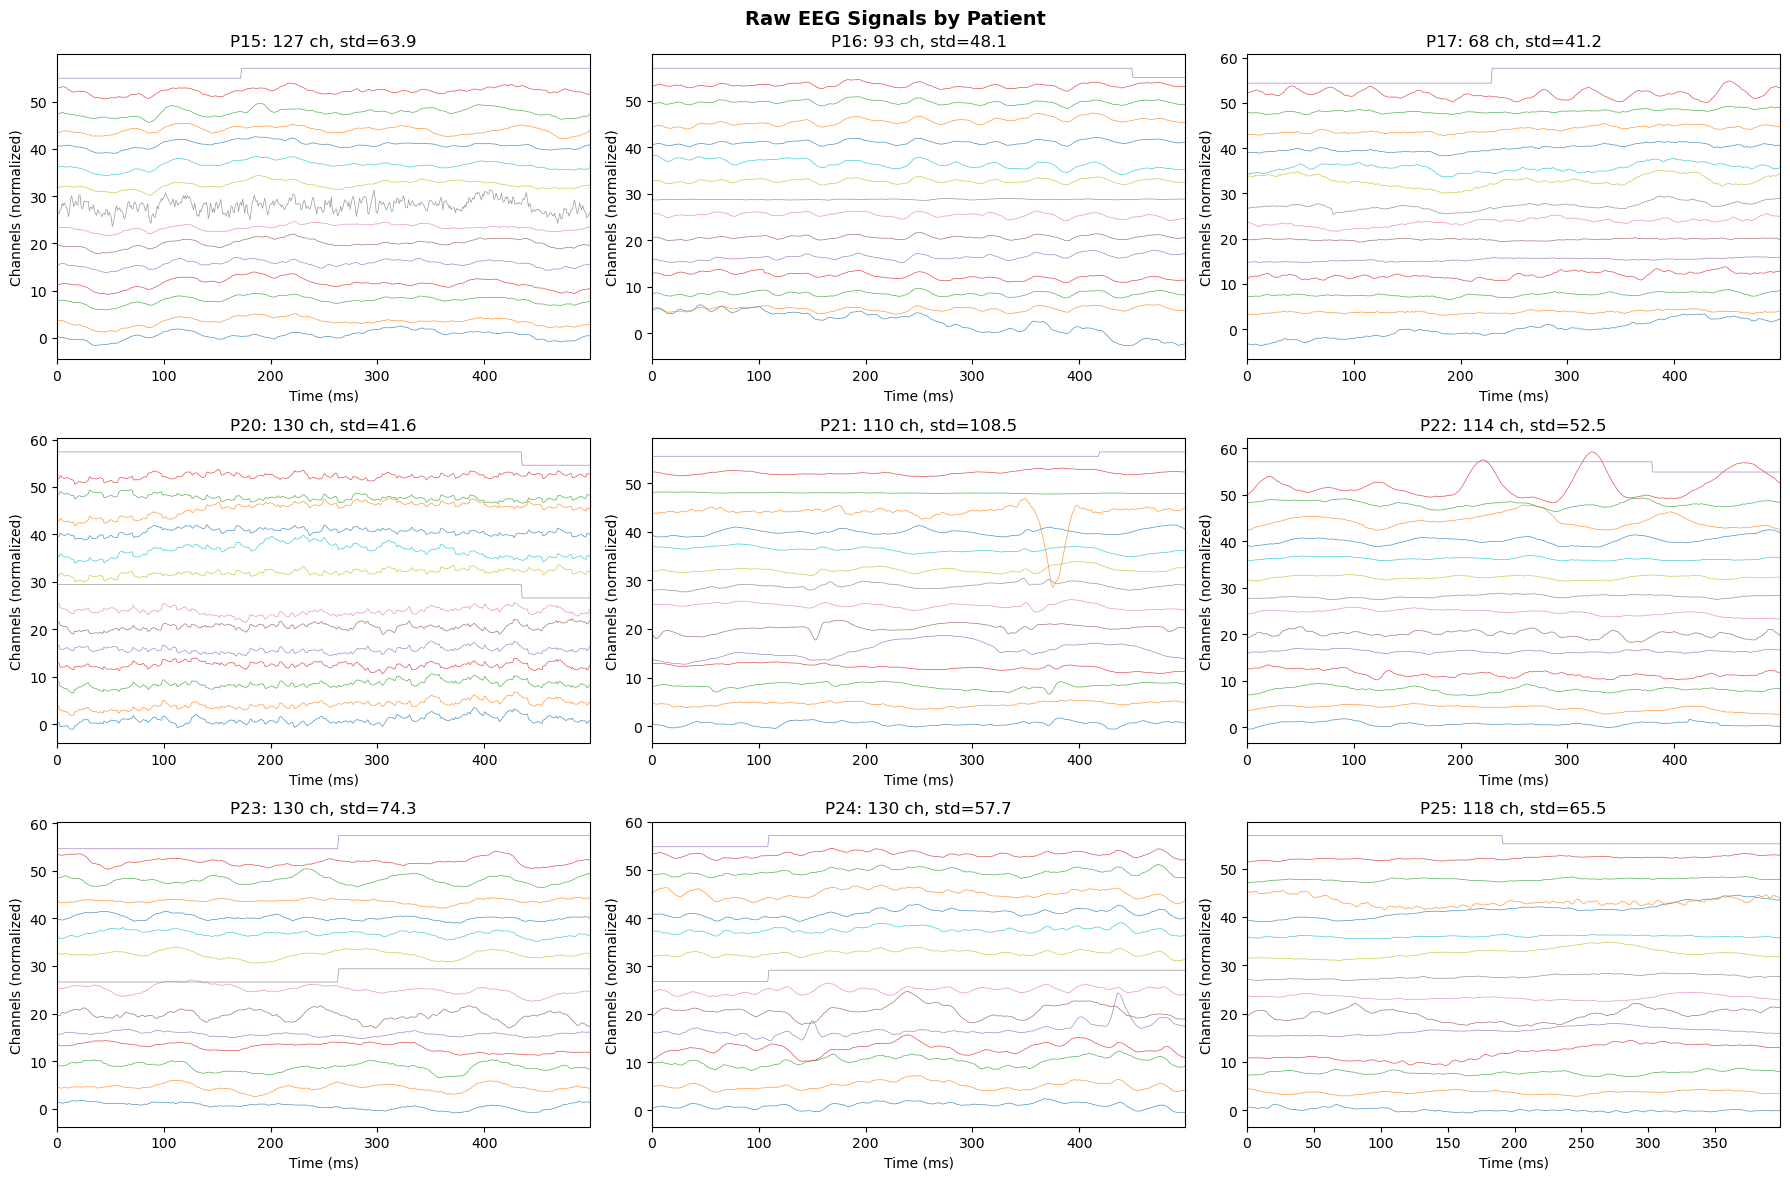


PATIENT SIGNAL STATISTICS
Patient    Channels   Std          Range        Mean|x|     
----------------------------------------------------------------------
P15        127        63.95        2495.90      42.02       
P16        93         48.06        1403.22      46.36       
P17        68         41.24        1692.87      25.41       
P20        130        41.62        1920.31      27.27       
P21        110        108.49       2361.91      78.80       
P22        114        52.49        1606.93      37.08       
P23        130        74.33        3210.45      50.00       
P24        130        57.68        1459.86      46.30       
P25        118        65.46        1158.20      44.03       

2. CHANNEL DISTRIBUTIONS


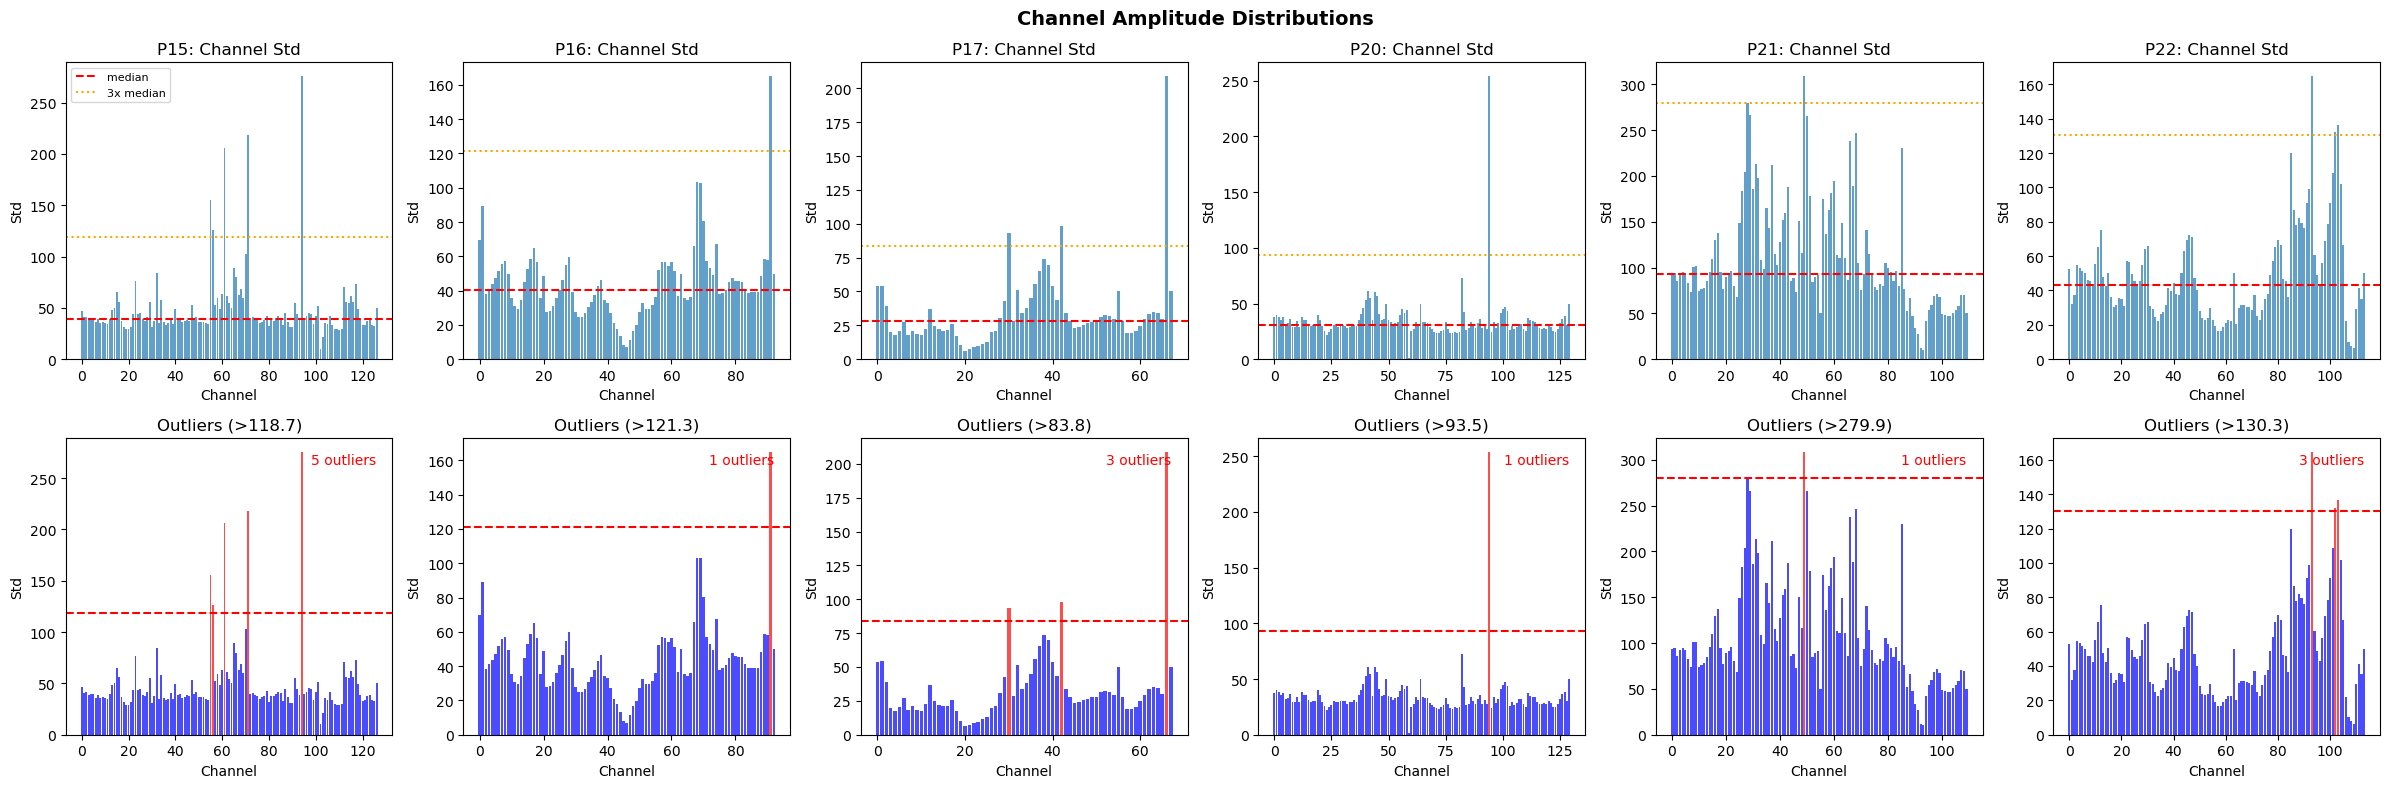


3. POWER SPECTRA


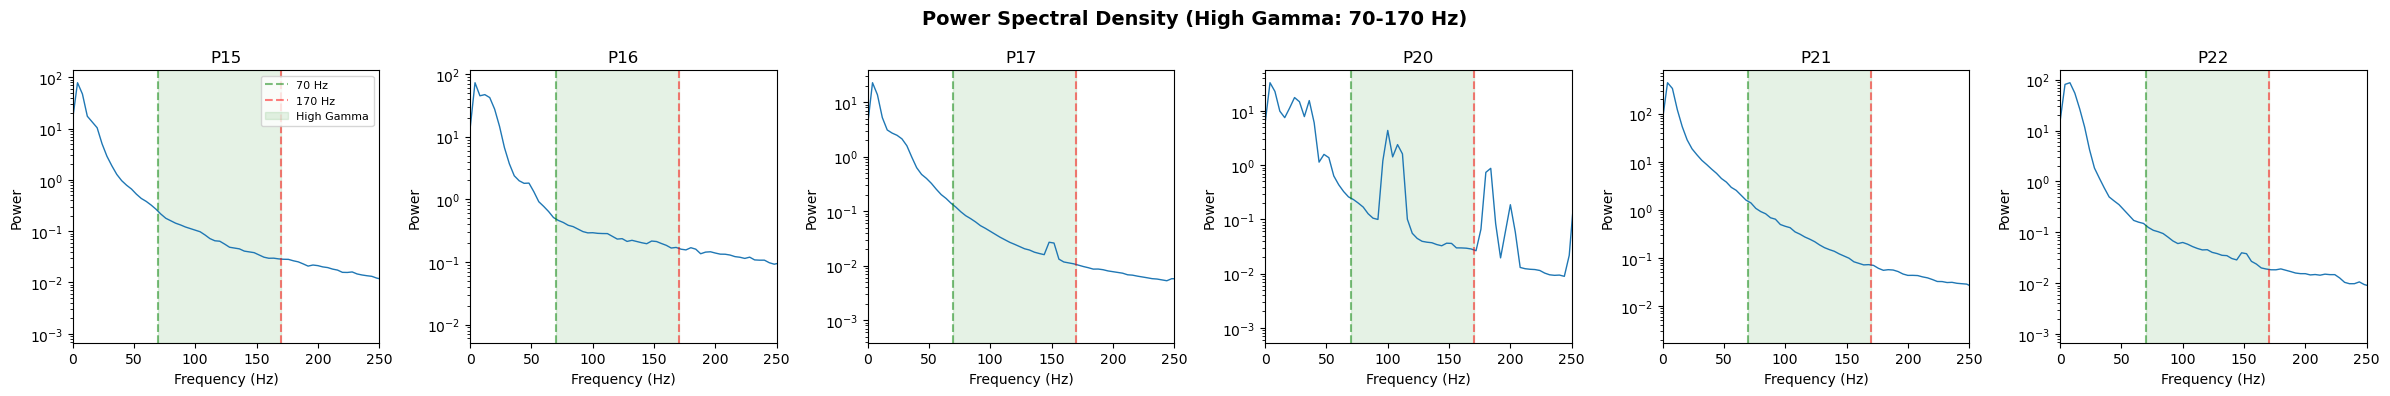


4. EXTRACTED FEATURES

FEATURE STATISTICS BY PATIENT
Patient    Samples    Mean         Std          Min          Max         
----------------------------------------------------------------------
P15        240        -0.7198      7.7583       -65.3775     276.4415    
P21        1159       -1.3198      5.4481       -21.5908     181.6921    
P24        1341       -0.3535      1.3881       -14.3640     43.3557     
P17        242        -0.2950      1.0876       -9.2439      24.7097     
P22        1399       -0.3119      1.0352       -4.1304      70.6855     
P16        240        -0.2177      1.0019       -15.7615     14.3649     
P20        234        -0.4651      1.5837       -5.6929      26.6724     
P25        1184       -0.5601      3.5960       -80.6790     60.8497     


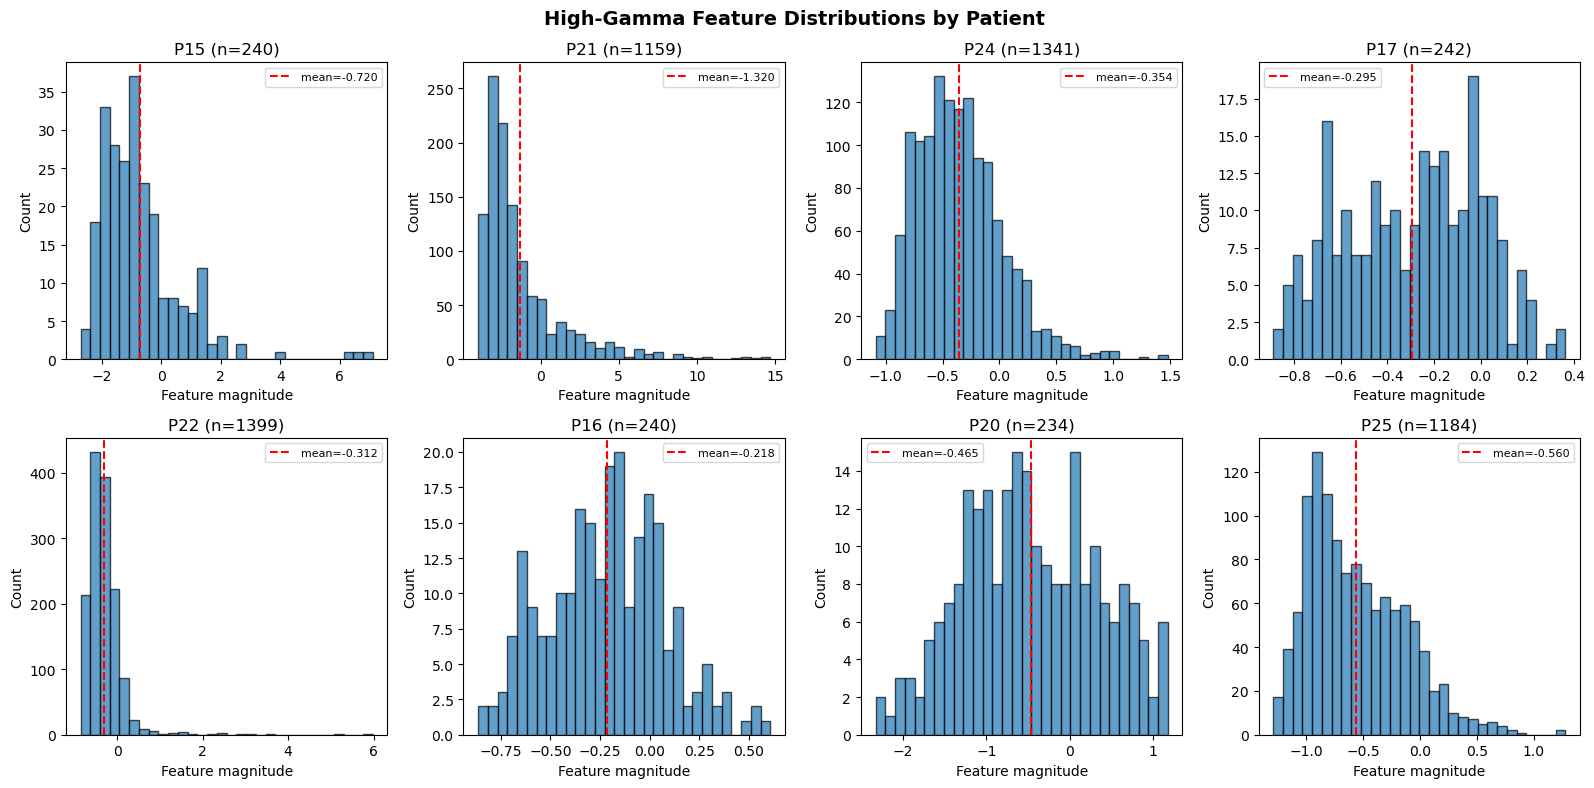

In [29]:
def visualize_patient_signals(pipeline, patient_ids=None, duration_sec=1.0, n_channels_to_show=20):
    """
    Visualize raw EEG signals for each patient to identify signal quality issues.
    
    Args:
        pipeline: Pipeline with loaded data
        patient_ids: List of patient IDs to visualize (default: all available)
        duration_sec: Duration of signal to show in seconds
        n_channels_to_show: Number of channels to display per patient
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    if patient_ids is None:
        patient_ids = list(pipeline.split_result['word_segments_dict'].keys())
    
    word_segments_dict = pipeline.split_result['word_segments_dict']
    config = pipeline.config
    
    n_patients = len(patient_ids)
    n_cols = min(3, n_patients)
    n_rows = (n_patients + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
    if n_patients == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    patient_stats = {}
    
    for idx, pid in enumerate(patient_ids):
        ax = axes[idx]
        
        if pid not in word_segments_dict:
            ax.set_title(f"{pid}: No data")
            continue
        
        # Get first word's EEG segment
        words_data = word_segments_dict[pid]['words']
        first_word = list(words_data.keys())[0]
        eeg_segment = words_data[first_word]['instances'][0]['eeg_segment']
        
        n_samples = min(int(duration_sec * config.eeg_sr), eeg_segment.shape[0])
        n_channels = eeg_segment.shape[1]
        channels_to_plot = min(n_channels_to_show, n_channels)
        
        # Select evenly spaced channels
        channel_indices = np.linspace(0, n_channels-1, channels_to_plot, dtype=int)
        
        # Time axis
        time = np.arange(n_samples) / config.eeg_sr * 1000  # in ms
        
        # Plot each channel with offset
        eeg_subset = eeg_segment[:n_samples, channel_indices]
        
        # Normalize for visualization
        eeg_norm = eeg_subset / (np.std(eeg_subset) + 1e-10)
        
        # Add offset for each channel
        offsets = np.arange(channels_to_plot) * 4  # 4 std units between channels
        eeg_offset = eeg_norm + offsets
        
        for ch_idx in range(channels_to_plot):
            ax.plot(time, eeg_offset[:, ch_idx], linewidth=0.5, alpha=0.8)
        
        # Calculate stats
        signal_std = np.std(eeg_segment)
        signal_range = np.ptp(eeg_segment)
        signal_mean = np.mean(np.abs(eeg_segment))
        
        patient_stats[pid] = {
            'n_channels': n_channels,
            'std': signal_std,
            'range': signal_range,
            'mean_abs': signal_mean
        }
        
        ax.set_title(f"{pid}: {n_channels} ch, std={signal_std:.1f}")
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel("Channels (normalized)")
        ax.set_xlim([0, time[-1]])
    
    # Hide unused axes
    for idx in range(n_patients, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Raw EEG Signals by Patient", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*70)
    print("PATIENT SIGNAL STATISTICS")
    print("="*70)
    print(f"{'Patient':<10} {'Channels':<10} {'Std':<12} {'Range':<12} {'Mean|x|':<12}")
    print("-"*70)
    
    for pid in sorted(patient_stats.keys()):
        stats = patient_stats[pid]
        print(f"{pid:<10} {stats['n_channels']:<10} {stats['std']:<12.2f} "
              f"{stats['range']:<12.2f} {stats['mean_abs']:<12.2f}")
    
    return patient_stats


def visualize_channel_distributions(pipeline, patient_ids=None):
    """
    Show distribution of signal amplitude across channels for each patient.
    Helps identify outlier channels.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    if patient_ids is None:
        patient_ids = list(pipeline.split_result['word_segments_dict'].keys())[:6]
    
    word_segments_dict = pipeline.split_result['word_segments_dict']
    config = pipeline.config
    
    n_patients = len(patient_ids)
    fig, axes = plt.subplots(2, n_patients, figsize=(4*n_patients, 8))
    
    if n_patients == 1:
        axes = axes.reshape(2, 1)
    
    for idx, pid in enumerate(patient_ids):
        if pid not in word_segments_dict:
            continue
        
        # Collect EEG from multiple words
        words_data = word_segments_dict[pid]['words']
        all_eeg = []
        
        for word, word_info in list(words_data.items())[:20]:
            for instance in word_info['instances'][:3]:
                eeg = instance['eeg_segment']
                all_eeg.append(eeg)
        
        if not all_eeg:
            continue
        
        # Concatenate all segments
        eeg_concat = np.vstack(all_eeg)
        n_channels = eeg_concat.shape[1]
        
        # Calculate per-channel statistics
        channel_std = np.std(eeg_concat, axis=0)
        channel_mean = np.mean(eeg_concat, axis=0)
        channel_range = np.ptp(eeg_concat, axis=0)
        
        # Top plot: Channel std
        ax1 = axes[0, idx]
        ax1.bar(range(n_channels), channel_std, alpha=0.7)
        ax1.axhline(np.median(channel_std), color='r', linestyle='--', label='median')
        ax1.axhline(np.median(channel_std) * 3, color='orange', linestyle=':', label='3x median')
        ax1.set_title(f"{pid}: Channel Std")
        ax1.set_xlabel("Channel")
        ax1.set_ylabel("Std")
        if idx == 0:
            ax1.legend(fontsize=8)
        
        # Bottom plot: Identify outliers
        ax2 = axes[1, idx]
        median_std = np.median(channel_std)
        outlier_threshold = median_std * 3
        
        colors = ['red' if s > outlier_threshold else 'blue' for s in channel_std]
        ax2.bar(range(n_channels), channel_std, color=colors, alpha=0.7)
        ax2.axhline(outlier_threshold, color='red', linestyle='--')
        ax2.set_title(f"Outliers (>{outlier_threshold:.1f})")
        ax2.set_xlabel("Channel")
        ax2.set_ylabel("Std")
        
        # Count outliers
        n_outliers = sum(1 for s in channel_std if s > outlier_threshold)
        ax2.text(0.95, 0.95, f"{n_outliers} outliers", transform=ax2.transAxes,
                ha='right', va='top', fontsize=10, color='red')
    
    plt.suptitle("Channel Amplitude Distributions", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def visualize_signal_spectra(pipeline, patient_ids=None):
    """
    Show power spectral density for each patient to check frequency content.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.signal import welch
    
    if patient_ids is None:
        patient_ids = list(pipeline.split_result['word_segments_dict'].keys())[:6]
    
    word_segments_dict = pipeline.split_result['word_segments_dict']
    config = pipeline.config
    
    n_patients = len(patient_ids)
    fig, axes = plt.subplots(1, n_patients, figsize=(4*n_patients, 4))
    
    if n_patients == 1:
        axes = [axes]
    
    for idx, pid in enumerate(patient_ids):
        ax = axes[idx]
        
        if pid not in word_segments_dict:
            continue
        
        # Get EEG data
        words_data = word_segments_dict[pid]['words']
        all_eeg = []
        
        for word, word_info in list(words_data.items())[:10]:
            for instance in word_info['instances'][:2]:
                eeg = instance['eeg_segment']
                all_eeg.append(eeg)
        
        if not all_eeg:
            continue
        
        eeg_concat = np.vstack(all_eeg)
        n_channels = eeg_concat.shape[1]
        
        # Compute average PSD across channels
        psds = []
        for ch in range(min(20, n_channels)):  # Sample 20 channels
            freqs, psd = welch(eeg_concat[:, ch], fs=config.eeg_sr, nperseg=256)
            psds.append(psd)
        
        avg_psd = np.mean(psds, axis=0)
        
        # Plot
        ax.semilogy(freqs, avg_psd, linewidth=1)
        ax.axvline(70, color='g', linestyle='--', alpha=0.5, label='70 Hz')
        ax.axvline(170, color='r', linestyle='--', alpha=0.5, label='170 Hz')
        ax.axvspan(70, 170, alpha=0.1, color='green', label='High Gamma')
        
        ax.set_title(f"{pid}")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Power")
        ax.set_xlim([0, 250])
        if idx == 0:
            ax.legend(fontsize=8)
    
    plt.suptitle("Power Spectral Density (High Gamma: 70-170 Hz)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def compare_patient_features(pipeline, patient_ids=None):
    """
    Compare extracted high-gamma features across patients.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from collections import defaultdict
    
    if patient_ids is None:
        patient_ids = list(set(pipeline.train['phoneme_participant_ids']))[:8]
    
    train_data = pipeline.train
    
    # Group features by patient
    patient_features = defaultdict(list)
    
    for i, feat in enumerate(train_data['features']):
        pid = train_data['phoneme_participant_ids'][i]
        if pid in patient_ids:
            if feat.ndim > 1:
                feat_agg = feat.mean(axis=0)
            else:
                feat_agg = feat
            patient_features[pid].append(feat_agg)
    
    n_patients = len(patient_ids)
    fig, axes = plt.subplots(2, min(4, n_patients), figsize=(16, 8))
    axes = axes.flatten()
    
    print("\n" + "="*70)
    print("FEATURE STATISTICS BY PATIENT")
    print("="*70)
    print(f"{'Patient':<10} {'Samples':<10} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
    print("-"*70)
    
    for idx, pid in enumerate(patient_ids[:8]):
        if pid not in patient_features:
            continue
        
        features = np.array(patient_features[pid])
        
        # Stats
        feat_mean = np.mean(features)
        feat_std = np.std(features)
        feat_min = np.min(features)
        feat_max = np.max(features)
        
        print(f"{pid:<10} {len(features):<10} {feat_mean:<12.4f} {feat_std:<12.4f} "
              f"{feat_min:<12.4f} {feat_max:<12.4f}")
        
        if idx < len(axes):
            ax = axes[idx]
            
            # Plot feature distribution (mean across channels)
            feature_means = np.mean(features, axis=1)
            ax.hist(feature_means, bins=30, alpha=0.7, edgecolor='black')
            ax.axvline(np.mean(feature_means), color='r', linestyle='--', 
                      label=f'mean={np.mean(feature_means):.3f}')
            ax.set_title(f"{pid} (n={len(features)})")
            ax.set_xlabel("Feature magnitude")
            ax.set_ylabel("Count")
            ax.legend(fontsize=8)
    
    # Hide unused axes
    for idx in range(len(patient_ids), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("High-Gamma Feature Distributions by Patient", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return patient_features


# Run all visualizations
print("1. RAW SIGNAL OVERVIEW")
patient_stats = visualize_patient_signals(high_gamma_pipeline, duration_sec=0.5, n_channels_to_show=15)

print("\n2. CHANNEL DISTRIBUTIONS")
visualize_channel_distributions(high_gamma_pipeline)

print("\n3. POWER SPECTRA")
visualize_signal_spectra(high_gamma_pipeline)

print("\n4. EXTRACTED FEATURES")
patient_features = compare_patient_features(high_gamma_pipeline)